In [ ]:
import os
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from datetime import datetime
import cv2
from PIL import Image
from keras import backend, optimizers

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!apt-get install unrar
!pip install rarfile

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
# Path to the .rar file
rar_file_path = "/content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000.rar"

# Destination folder for extracted files
extract_to = "/content/myData"

# Ensure the destination directory exists
os.makedirs(extract_to, exist_ok=True)

# Extract using unrar
!unrar x -r {rar_file_path} {extract_to}

Streaming output truncated to the last 5000 lines.
Extracting  /content/myData/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/masks/train/real_real_2025-06-13-05-53-52-589467.npy      99%  OK 
Extracting  /content/myData/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/masks/train/real_real_2025-06-13-05-53-53-802085.npy      99%  OK 
Extracting  /content/myData/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/masks/train/real_real_2025-06-13-05-53-53-802085_randAug2636.npy      99%  OK 
Extracting  /content/myData/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/masks/train/real_real_2025-06-13-05-53-53-802085_randAug2944.npy      99%  OK 
Extracting  /content/myData/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/masks/train/real_real_2025-06-13-05-53-53-802085_randAug560.npy      99%  OK 
Extracting  /content/myData/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/masks/

In [ ]:
  # Paths to the images and masks directories
train_images_path = "/content/myData/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/images/train"
train_masks_path = "/content/myData/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/masks/train"
val_images_path = "/content/myData/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/images/val"
val_masks_path = "/content/myData/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/masks/val"
test_images_path = "/content/myData/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/images/test"
test_masks_path = "/content/myData/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/masks/test"

# List and sort files to ensure they match
train_image_files = sorted(os.listdir(train_images_path))
train_mask_files = sorted(os.listdir(train_masks_path))
val_image_files = sorted(os.listdir(val_images_path))
val_mask_files = sorted(os.listdir(val_masks_path))
test_image_files = sorted(os.listdir(test_images_path))
test_mask_files = sorted(os.listdir(test_masks_path))

In [ ]:
import os
import numpy as np

def load_dataset(images_path, masks_path):
    images = []
    masks = []
    filenames = []

    for filename in sorted(os.listdir(images_path)):
        if filename.endswith('.npy'):
            image_path = os.path.join(images_path, filename)
            mask_filename = filename.replace("_generated", "")
            mask_path = os.path.join(masks_path, mask_filename)

            if not os.path.exists(mask_path):
                print(f"❌ Mask not found for {filename}")
                continue

            image = np.load(image_path)
            mask = np.load(mask_path)

            # Handle image shape
            if image.shape == (128, 128):
                image = np.expand_dims(image, axis=-1)
            elif image.shape != (128, 128, 1):
                print(f"❌ Invalid image shape: {image.shape} in {filename}")
                continue

            # Handle mask shape
            if mask.shape == (128, 128):
                mask = np.expand_dims(mask, axis=-1)
            elif mask.shape != (128, 128, 1):
                print(f"❌ Invalid mask shape: {mask.shape} in {mask_filename}")
                continue

            images.append(image.astype(np.float32))
            masks.append(mask.astype(np.uint8))
            filenames.append(filename)

    # Convert to NumPy arrays
    images_np = np.stack(images)
    masks_np = np.stack(masks)

    return images_np, masks_np, filenames


In [ ]:
# Load dataset
train_images_tensor, train_masks_tensor, train_filenames = load_dataset(train_images_path, train_masks_path)
val_images_tensor, val_masks_tensor, val_filenames = load_dataset(val_images_path, val_masks_path)
test_images_tensor, test_masks_tensor, test_filenames = load_dataset(test_images_path, test_masks_path)
# train_images_tensor = tf.expand_dims(train_images_tensor, axis=-1)
# train_masks_tensor = tf.expand_dims(train_masks_tensor, axis=-1)
# val_images_tensor = tf.expand_dims(val_images_tensor, axis=-1)
# val_masks_tensor = tf.expand_dims(val_masks_tensor, axis=-1)
# test_images_tensor = tf.expand_dims(test_images_tensor, axis=-1)
# test_masks_tensor = tf.expand_dims(test_masks_tensor, axis=-1)



# Check shapes
print(f"Train Images Tensor Shape: {train_images_tensor.shape}, dtype: {train_images_tensor.dtype}")
print(f"Train Masks Tensor Shape: {train_masks_tensor.shape}, dtype: {train_masks_tensor.dtype}")
print(f"Val Images Tensor Shape: {val_images_tensor.shape}, dtype: {val_images_tensor.dtype}")
print(f"Val Masks Tensor Shape: {val_masks_tensor.shape}, dtype: {val_masks_tensor.dtype}")
print(f"Test Images Tensor Shape: {test_images_tensor.shape}, dtype: {test_images_tensor.dtype}")
print(f"Test Masks Tensor Shape: {test_masks_tensor.shape}, dtype: {test_masks_tensor.dtype}")

Train Images Tensor Shape: (10000, 128, 128, 1), dtype: float32
Train Masks Tensor Shape: (10000, 128, 128, 1), dtype: uint8
Val Images Tensor Shape: (60, 128, 128, 1), dtype: float32
Val Masks Tensor Shape: (60, 128, 128, 1), dtype: uint8
Test Images Tensor Shape: (80, 128, 128, 1), dtype: float32
Test Masks Tensor Shape: (80, 128, 128, 1), dtype: uint8


In [ ]:
# Model input shape
IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS = train_images_tensor.shape[1:]
NUM_CLASSES = 5
input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
batch_size = 8

In [ ]:
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras import backend as K
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy, MeanIoU
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from tensorflow.keras.callbacks import ModelCheckpoint


## Useful blocks to build Unet


In [ ]:
def conv_block(x, filter_size, size, dropout, batch_norm=False):

    conv = layers.Conv2D(size, (filter_size, filter_size), padding="same")(x)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation("relu")(conv)

    conv = layers.Conv2D(size, (filter_size, filter_size), padding="same")(conv)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation("relu")(conv)

    if dropout > 0:
        conv = layers.Dropout(dropout)(conv)

    return conv

In [ ]:
def repeat_elem(tensor, rep):
    # lambda function to repeat Repeats the elements of a tensor along an axis
    #by a factor of rep.
    # If tensor has shape (None, 256,256,3), lambda will return a tensor of shape
    #(None, 256,256,6), if specified axis=3 and rep=2.

     return layers.Lambda(lambda x, repnum: K.repeat_elements(x, repnum, axis=3),
                          arguments={'repnum': rep})(tensor)

In [ ]:
def res_conv_block(x, filter_size, size, dropout, batch_norm=False):
    '''
    Residual convolutional layer.
    Two variants....
    Either put activation function before the addition with shortcut
    or after the addition (which would be as proposed in the original resNet).

    1. conv - BN - Activation - conv - BN - Activation
                                          - shortcut  - BN - shortcut+BN

    2. conv - BN - Activation - conv - BN
                                     - shortcut  - BN - shortcut+BN - Activation

    Check fig 4 in https://arxiv.org/ftp/arxiv/papers/1802/1802.06955.pdf
    '''

    conv = layers.Conv2D(size, (filter_size, filter_size), padding='same')(x)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation('relu')(conv)

    conv = layers.Conv2D(size, (filter_size, filter_size), padding='same')(conv)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    #conv = layers.Activation('relu')(conv)    #Activation before addition with shortcut
    if dropout > 0:
        conv = layers.Dropout(dropout)(conv)

    shortcut = layers.Conv2D(size, kernel_size=(1, 1), padding='same')(x)
    if batch_norm is True:
        shortcut = layers.BatchNormalization(axis=3)(shortcut)

    res_path = layers.add([shortcut, conv])
    res_path = layers.Activation('relu')(res_path)    #Activation after addition with shortcut (Original residual block)
    return res_path

In [ ]:
def gating_signal(input, out_size, batch_norm=False):
    """
    resize the down layer feature map into the same dimension as the up layer feature map
    using 1x1 conv
    :return: the gating feature map with the same dimension of the up layer feature map
    """
    x = layers.Conv2D(out_size, (1, 1), padding='same')(input)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

In [ ]:
def attention_block(x, gating, inter_shape):
    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

# Getting the x signal to the same shape as the gating signal
    theta_x = layers.Conv2D(inter_shape, (2, 2), strides=(2, 2), padding='same')(x)  # 16
    shape_theta_x = K.int_shape(theta_x)

# Getting the gating signal to the same number of filters as the inter_shape
    phi_g = layers.Conv2D(inter_shape, (1, 1), padding='same')(gating)
    upsample_g = layers.Conv2DTranspose(inter_shape, (3, 3),
                                 strides=(shape_theta_x[1] // shape_g[1], shape_theta_x[2] // shape_g[2]),
                                 padding='same')(phi_g)  # 16

    concat_xg = layers.add([upsample_g, theta_x])
    act_xg = layers.Activation('relu')(concat_xg)
    psi = layers.Conv2D(1, (1, 1), padding='same')(act_xg)
    sigmoid_xg = layers.Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)
    upsample_psi = layers.UpSampling2D(size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)  # 32

    upsample_psi = repeat_elem(upsample_psi, shape_x[3])

    y = layers.multiply([upsample_psi, x])

    result = layers.Conv2D(shape_x[3], (1, 1), padding='same')(y)
    result_bn = layers.BatchNormalization()(result)
    return result_bn

In [ ]:
def Attention_ResUNet(input_shape, NUM_CLASSES=1, dropout_rate=0.0, batch_norm=True):
    '''
    Rsidual UNet, with attention

    '''
    # network structure
    FILTER_NUM = 64 # number of basic filters for the first layer
    FILTER_SIZE = 3 # size of the convolutional filter
    UP_SAMP_SIZE = 2 # size of upsampling filters
    # input data
    # dimension of the image depth
    inputs = layers.Input(input_shape, dtype=tf.float32)
    axis = 3

    # Downsampling layers
    # DownRes 1, double residual convolution + pooling
    conv_128 = res_conv_block(inputs, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)
    pool_64 = layers.MaxPooling2D(pool_size=(2,2))(conv_128)
    # DownRes 2
    conv_64 = res_conv_block(pool_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    pool_32 = layers.MaxPooling2D(pool_size=(2,2))(conv_64)
    # DownRes 3
    conv_32 = res_conv_block(pool_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    pool_16 = layers.MaxPooling2D(pool_size=(2,2))(conv_32)
    # DownRes 4
    conv_16 = res_conv_block(pool_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    pool_8 = layers.MaxPooling2D(pool_size=(2,2))(conv_16)
    # DownRes 5, convolution only
    conv_8 = res_conv_block(pool_8, FILTER_SIZE, 16*FILTER_NUM, dropout_rate, batch_norm)

    # Upsampling layers
    # UpRes 6, attention gated concatenation + upsampling + double residual convolution
    gating_16 = gating_signal(conv_8, 8*FILTER_NUM, batch_norm)
    att_16 = attention_block(conv_16, gating_16, 8*FILTER_NUM)
    up_16 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(conv_8)
    up_16 = layers.concatenate([up_16, att_16], axis=axis)
    up_conv_16 = res_conv_block(up_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 7
    gating_32 = gating_signal(up_conv_16, 4*FILTER_NUM, batch_norm)
    att_32 = attention_block(conv_32, gating_32, 4*FILTER_NUM)
    up_32 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_16)
    up_32 = layers.concatenate([up_32, att_32], axis=axis)
    up_conv_32 = res_conv_block(up_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 8
    gating_64 = gating_signal(up_conv_32, 2*FILTER_NUM, batch_norm)
    att_64 = attention_block(conv_64, gating_64, 2*FILTER_NUM)
    up_64 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_32)
    up_64 = layers.concatenate([up_64, att_64], axis=axis)
    up_conv_64 = res_conv_block(up_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 9
    gating_128 = gating_signal(up_conv_64, FILTER_NUM, batch_norm)
    att_128 = attention_block(conv_128, gating_128, FILTER_NUM)
    up_128 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_64)
    up_128 = layers.concatenate([up_128, att_128], axis=axis)
    up_conv_128 = res_conv_block(up_128, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)

    # 1*1 convolutional layers

    conv_final = layers.Conv2D(NUM_CLASSES, kernel_size=(1,1))(up_conv_128)
    conv_final = layers.BatchNormalization(axis=axis)(conv_final)
    conv_final = layers.Activation('softmax')(conv_final)


    # Model integration
    model = models.Model(inputs, conv_final, name="AttentionResUNet")
    return model

In [ ]:
def weighted_sparse_categorical_crossentropy(class_weights):
    def loss(y_true, y_pred):
        # Flatten tensors
        y_true_flat = tf.reshape(y_true, [-1])
        y_pred_flat = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])

        # Cast to int32 before using one-hot
        y_true_flat = tf.cast(y_true_flat, tf.int32)

        # One-hot encode y_true
        y_true_one_hot = tf.one_hot(y_true_flat, depth=tf.shape(y_pred)[-1])

        # Standard categorical crossentropy
        ce = tf.keras.losses.categorical_crossentropy(y_true_one_hot, y_pred_flat)

        # Apply per-pixel weights based on true class
        weights = tf.gather(class_weights, y_true_flat)
        weighted_loss = ce * weights

        return tf.reduce_mean(weighted_loss)

    return loss


In [ ]:
# Class weights as per generator loss
class_weights = tf.constant([1.0, 7.0, 11.0, 26.0, 90.0], dtype=tf.float32)

model = Attention_ResUNet(input_shape=(128, 128, 1), NUM_CLASSES=5)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=weighted_sparse_categorical_crossentropy(class_weights),
    metrics=[SparseCategoricalAccuracy()]
)
model.summary()

Model: "AttentionResUNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │        128 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │      8,320 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_5[0][0]  

 Total params: 39,089,373 (149.11 MB)

 Trainable params: 39,067,859 (149.03 MB)

 Non-trainable params: 21,514 (84.04 KB)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [ ]:
def generate_images(model, test_input, tar):
    test_input = tf.squeeze(test_input, axis=0)  # Remove batch dim
    tar = tf.squeeze(tar, axis=0)  # Remove batch dim
    prediction = model(tf.expand_dims(test_input, axis=0), training=False)
    prediction = tf.argmax(prediction, axis=-1)  # Convert softmax to class labels
    prediction = tf.squeeze(prediction, axis=0)  # Remove batch dim

    cmap_mask = ListedColormap(['black', 'white', 'gray', 'red', 'yellow'])

    plt.figure(figsize=(15, 5))
    display_list = [test_input, tar, prediction]
    titles = ['Input Image', 'Ground Truth Mask', 'Predicted Mask']

    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.title(titles[i])

        if i == 0:
            # Assume grayscale input
            if len(display_list[i].shape) == 2:
                plt.imshow(display_list[i], cmap='gray')
            else:
                plt.imshow(tf.squeeze(display_list[i], axis=-1), cmap='gray')
        else:
            # Use colormap for masks
            plt.imshow(display_list[i], cmap=cmap_mask, vmin=0, vmax=4)

        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
# Custom callback
class CheckpointAndPlotCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_images_tensor, val_masks_tensor, checkpoint_dir, every_n_epochs=10):
        super().__init__()
        self.val_images = val_images_tensor
        self.val_masks = val_masks_tensor
        self.checkpoint_dir = checkpoint_dir
        self.every_n = every_n_epochs

        # Choose one sample to track
        idx = np.random.randint(0, len(val_images_tensor))
        self.sample_image = val_images_tensor[idx:idx+1]  # keep batch dim
        self.sample_mask = val_masks_tensor[idx:idx+1]

        os.makedirs(self.checkpoint_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            # Save model
            checkpoint_path = os.path.join(self.checkpoint_dir, f'ckpt-epoch{epoch+1}.weights.h5')
            self.model.save_weights(checkpoint_path)
            print(f"Saved checkpoint: {checkpoint_path}")

        # Plotting
        print(f"Generating predictions at epoch {epoch+1}")
        generate_images(self.model, self.sample_image, self.sample_mask)

In [ ]:
class PerClassDiceCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_images, val_masks, num_classes):
        super().__init__()
        self.val_images = val_images
        self.val_masks = val_masks
        self.num_classes = num_classes

    def dice_score(self, y_true, y_pred, class_id, smooth=1e-6):
        # Create binary masks for the class
        y_true_class = tf.cast(tf.equal(y_true, class_id), tf.float32)
        y_pred_class = tf.cast(tf.equal(y_pred, class_id), tf.float32)

        intersection = tf.reduce_sum(y_true_class * y_pred_class)
        union = tf.reduce_sum(y_true_class) + tf.reduce_sum(y_pred_class)

        return (2. * intersection + smooth) / (union + smooth)

    def on_epoch_end(self, epoch, logs=None):
        preds = self.model.predict(self.val_images, verbose=0)
        preds = tf.argmax(preds, axis=-1)  # [batch, H, W]

        y_true = tf.squeeze(self.val_masks, axis=-1)  # Make sure shape matches [batch, H, W]

        print("\nPer-class Dice scores:")
        for class_id in range(self.num_classes):
            dice = self.dice_score(y_true, preds, class_id)
            print(f"  Class {class_id}: Dice = {dice.numpy():.4f}")


In [ ]:
class BestDiceCheckpointCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_images, val_masks, num_classes, save_path):
        super().__init__()
        self.val_images = val_images
        self.val_masks = val_masks
        self.num_classes = num_classes
        self.save_path = save_path
        self.best_dice = -1  # initialize with lowest possible

    def dice_score(self, y_true, y_pred, class_id, smooth=1e-6):
        y_true_class = tf.cast(tf.equal(y_true, class_id), tf.float32)
        y_pred_class = tf.cast(tf.equal(y_pred, class_id), tf.float32)

        intersection = tf.reduce_sum(y_true_class * y_pred_class)
        union = tf.reduce_sum(y_true_class) + tf.reduce_sum(y_pred_class)

        return (2. * intersection + smooth) / (union + smooth)

    def on_epoch_end(self, epoch, logs=None):
        preds = self.model.predict(self.val_images, verbose=0)
        preds = tf.argmax(preds, axis=-1)
        y_true = tf.squeeze(self.val_masks, axis=-1)

        # Compute mean dice across all classes
        dice_scores = []
        for class_id in range(self.num_classes):
            dice = self.dice_score(y_true, preds, class_id)
            dice_scores.append(dice)
        mean_dice = tf.reduce_mean(dice_scores)

        print(f"\nEpoch {epoch+1}: Mean Dice = {mean_dice:.4f}")
        if mean_dice > self.best_dice:
            self.best_dice = mean_dice
            self.model.save_weights(self.save_path)
            print(f"✅ New best Dice score! Model saved to {self.save_path}")


In [ ]:
# Example usage:
checkpoint_dir = '/content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/ckpt'
best_model_dir = '/content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/best'
os.makedirs(best_model_dir, exist_ok=True)

dice_callback = PerClassDiceCallback(
    val_images=val_images_tensor,
    val_masks=val_masks_tensor,
    num_classes=5  # since you have 5 classes: background, cavity, myocardium, infarction, no-reflow
)

# Callbacks
callbacks = [
    CheckpointAndPlotCallback(val_images_tensor, val_masks_tensor, checkpoint_dir=checkpoint_dir, every_n_epochs=10),
    PerClassDiceCallback(val_images=val_images_tensor, val_masks=val_masks_tensor, num_classes=5),
    BestDiceCheckpointCallback(
        val_images=val_images_tensor,
        val_masks=val_masks_tensor,
        num_classes=5,
        save_path=os.path.join(best_model_dir, 'best_model_dice.weights.h5')
    )
]

Epoch 1/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - loss: 2.1915 - sparse_categorical_accuracy: 0.8035Generating predictions at epoch 1


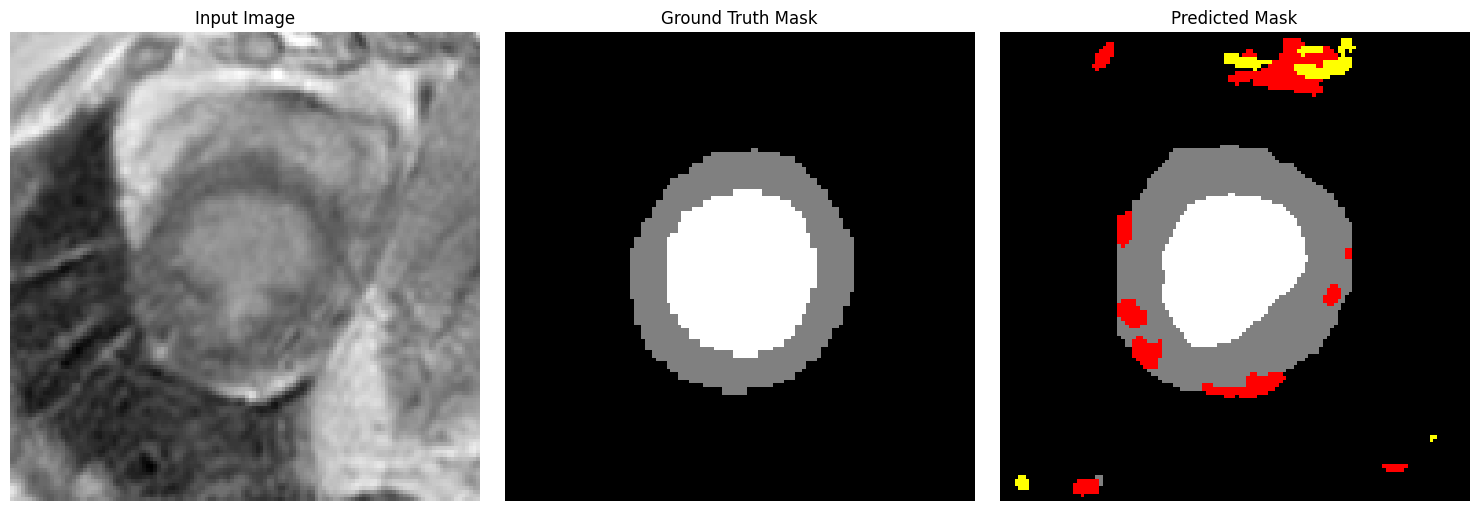


Per-class Dice scores:
  Class 0: Dice = 0.8968
  Class 1: Dice = 0.8710
  Class 2: Dice = 0.5670
  Class 3: Dice = 0.2417
  Class 4: Dice = 0.0948

Epoch 1: Mean Dice = 0.5343
✅ New best Dice score! Model saved to /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 421s 270ms/step - loss: 2.1911 - sparse_categorical_accuracy: 0.8036 - val_loss: 1.7924 - val_sparse_categorical_accuracy: 0.8154
Epoch 2/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 1.1051 - sparse_categorical_accuracy: 0.9382Generating predictions at epoch 2


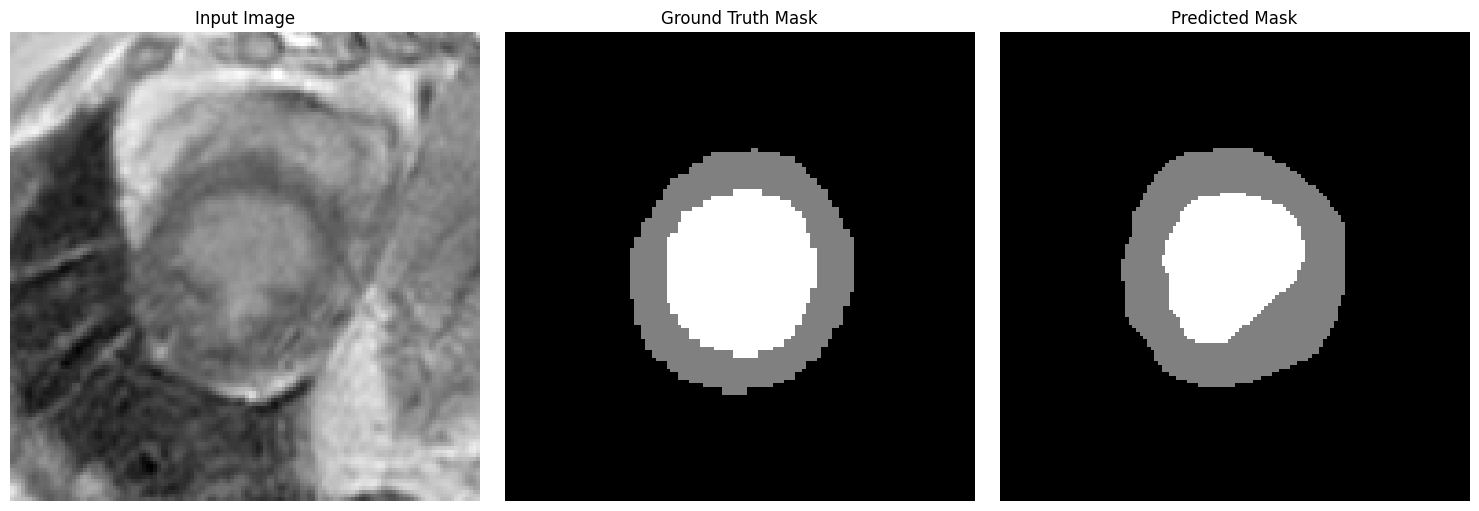


Per-class Dice scores:
  Class 0: Dice = 0.9658
  Class 1: Dice = 0.9026
  Class 2: Dice = 0.7401
  Class 3: Dice = 0.3408
  Class 4: Dice = 0.1946

Epoch 2: Mean Dice = 0.6288
✅ New best Dice score! Model saved to /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 332s 225ms/step - loss: 1.1051 - sparse_categorical_accuracy: 0.9382 - val_loss: 1.3637 - val_sparse_categorical_accuracy: 0.9198
Epoch 3/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 0.9180 - sparse_categorical_accuracy: 0.9459Generating predictions at epoch 3


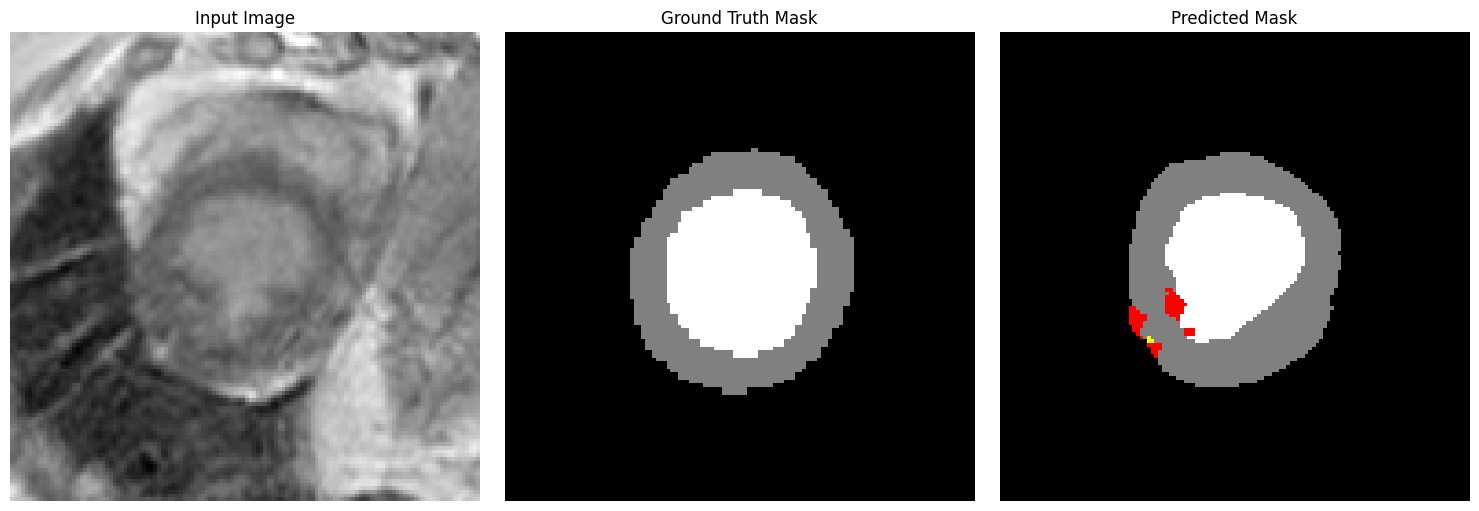


Per-class Dice scores:
  Class 0: Dice = 0.9744
  Class 1: Dice = 0.9075
  Class 2: Dice = 0.7674
  Class 3: Dice = 0.4214
  Class 4: Dice = 0.1210

Epoch 3: Mean Dice = 0.6383
✅ New best Dice score! Model saved to /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 315s 220ms/step - loss: 0.9180 - sparse_categorical_accuracy: 0.9459 - val_loss: 1.2274 - val_sparse_categorical_accuracy: 0.9292
Epoch 4/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.7997 - sparse_categorical_accuracy: 0.9512Generating predictions at epoch 4


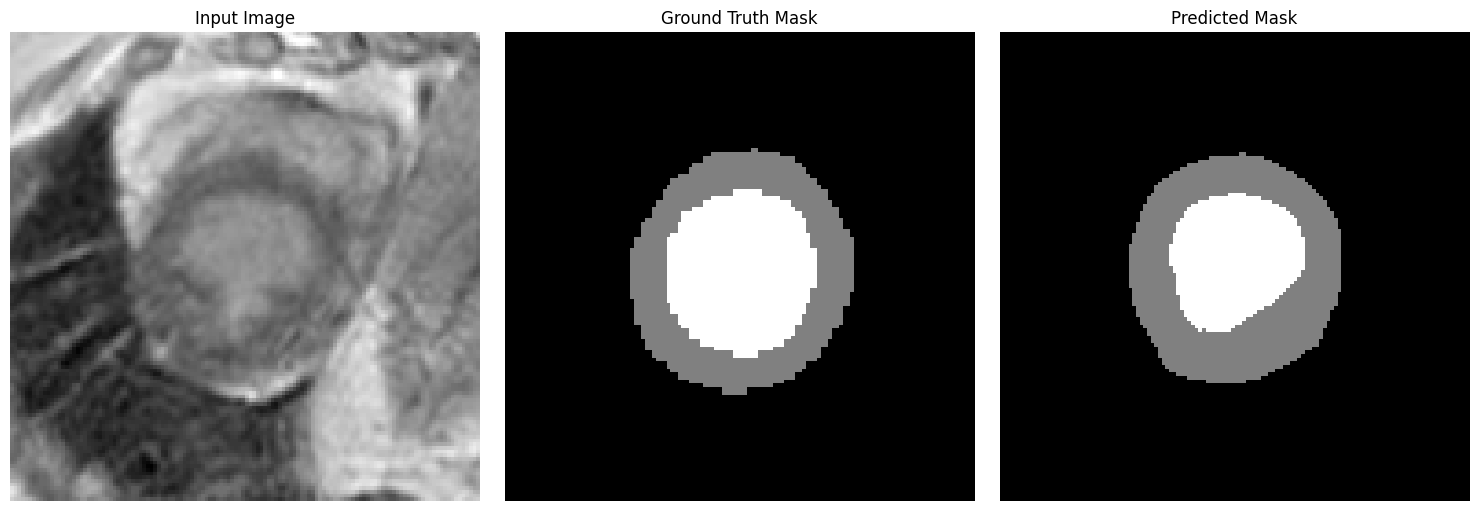


Per-class Dice scores:
  Class 0: Dice = 0.9846
  Class 1: Dice = 0.9191
  Class 2: Dice = 0.8024
  Class 3: Dice = 0.5276
  Class 4: Dice = 0.3356

Epoch 4: Mean Dice = 0.7138
✅ New best Dice score! Model saved to /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 279s 223ms/step - loss: 0.7997 - sparse_categorical_accuracy: 0.9512 - val_loss: 1.3593 - val_sparse_categorical_accuracy: 0.9532
Epoch 5/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 0.7388 - sparse_categorical_accuracy: 0.9537Generating predictions at epoch 5


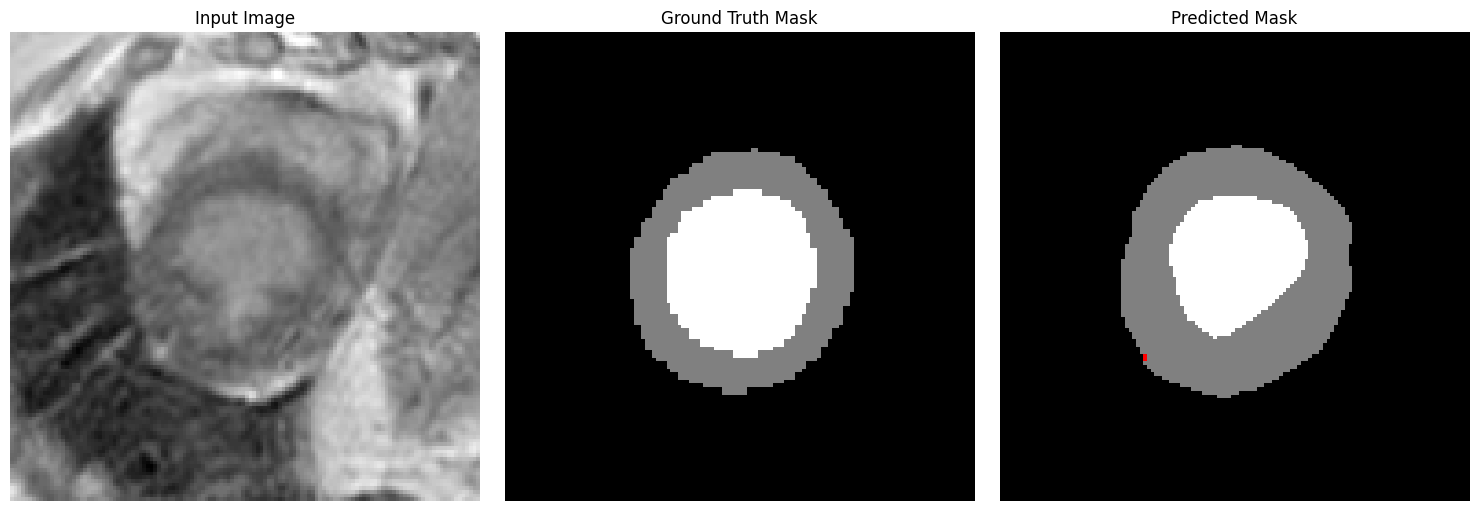


Per-class Dice scores:
  Class 0: Dice = 0.9736
  Class 1: Dice = 0.9046
  Class 2: Dice = 0.7493
  Class 3: Dice = 0.5185
  Class 4: Dice = 0.2636

Epoch 5: Mean Dice = 0.6819
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 311s 214ms/step - loss: 0.7388 - sparse_categorical_accuracy: 0.9537 - val_loss: 1.0163 - val_sparse_categorical_accuracy: 0.9313
Epoch 6/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 0.7098 - sparse_categorical_accuracy: 0.9542Generating predictions at epoch 6


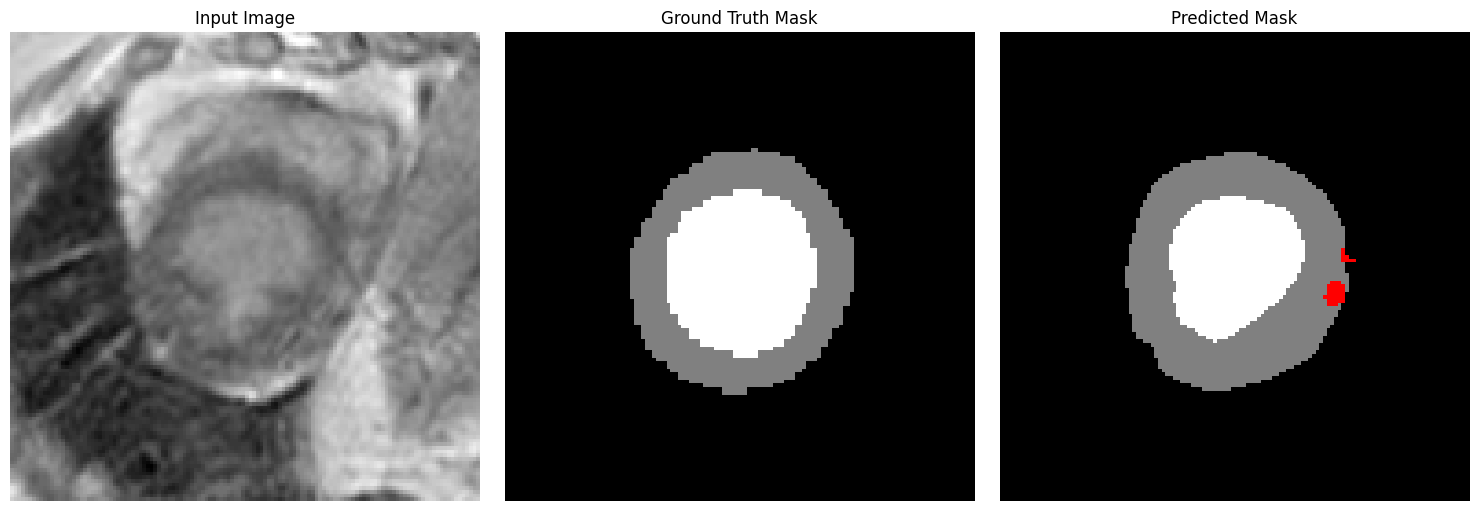


Per-class Dice scores:
  Class 0: Dice = 0.9726
  Class 1: Dice = 0.9127
  Class 2: Dice = 0.7609
  Class 3: Dice = 0.4428
  Class 4: Dice = 0.2238

Epoch 6: Mean Dice = 0.6626
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 214ms/step - loss: 0.7098 - sparse_categorical_accuracy: 0.9542 - val_loss: 1.1190 - val_sparse_categorical_accuracy: 0.9300
Epoch 7/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.6502 - sparse_categorical_accuracy: 0.9585Generating predictions at epoch 7


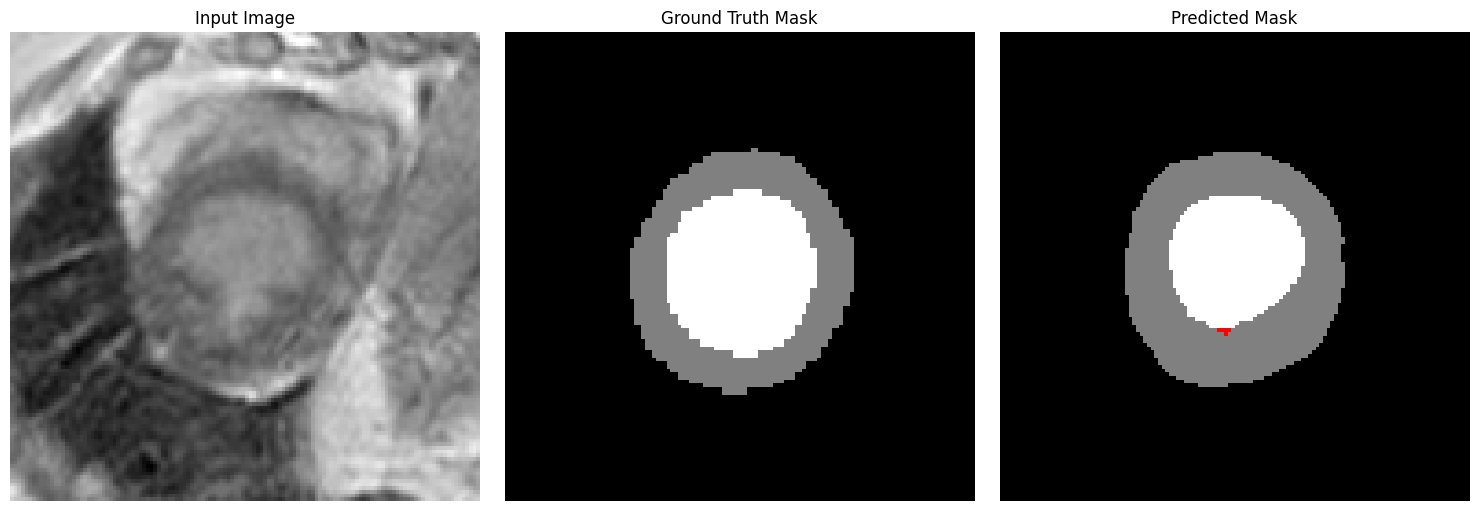


Per-class Dice scores:
  Class 0: Dice = 0.9835
  Class 1: Dice = 0.9075
  Class 2: Dice = 0.7888
  Class 3: Dice = 0.5354
  Class 4: Dice = 0.2815

Epoch 7: Mean Dice = 0.6993
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 214ms/step - loss: 0.6502 - sparse_categorical_accuracy: 0.9585 - val_loss: 1.0259 - val_sparse_categorical_accuracy: 0.9455
Epoch 8/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.6109 - sparse_categorical_accuracy: 0.9603Generating predictions at epoch 8


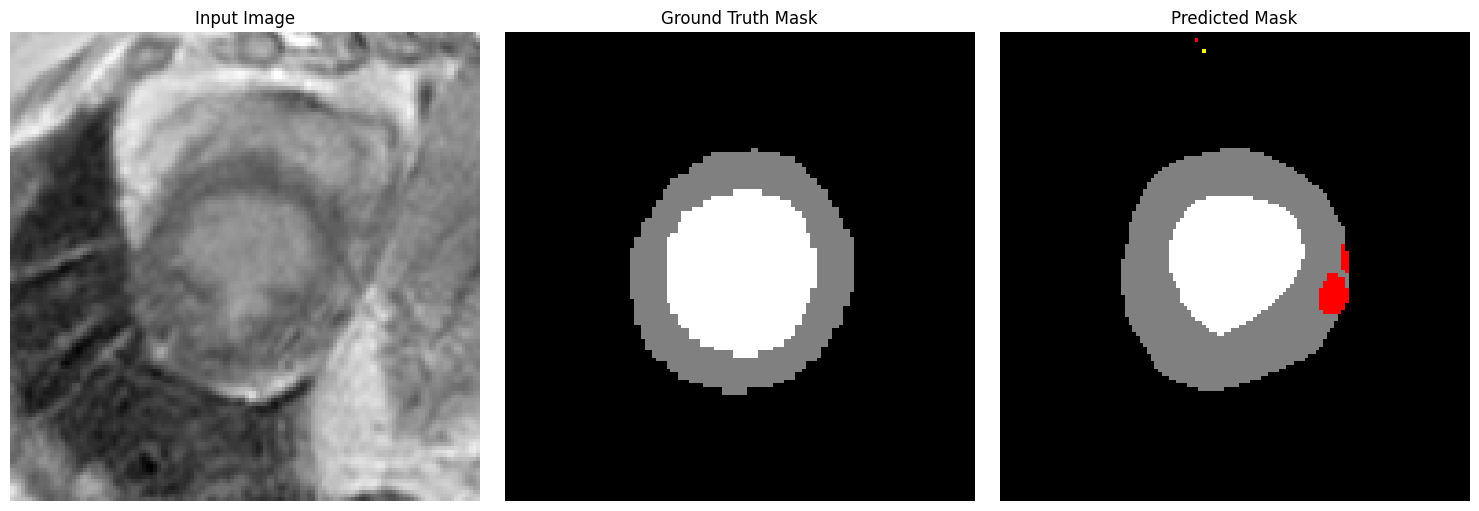


Per-class Dice scores:
  Class 0: Dice = 0.9758
  Class 1: Dice = 0.9131
  Class 2: Dice = 0.7656
  Class 3: Dice = 0.4946
  Class 4: Dice = 0.2832

Epoch 8: Mean Dice = 0.6864
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 215ms/step - loss: 0.6109 - sparse_categorical_accuracy: 0.9603 - val_loss: 1.0319 - val_sparse_categorical_accuracy: 0.9356
Epoch 9/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.5834 - sparse_categorical_accuracy: 0.9615Generating predictions at epoch 9


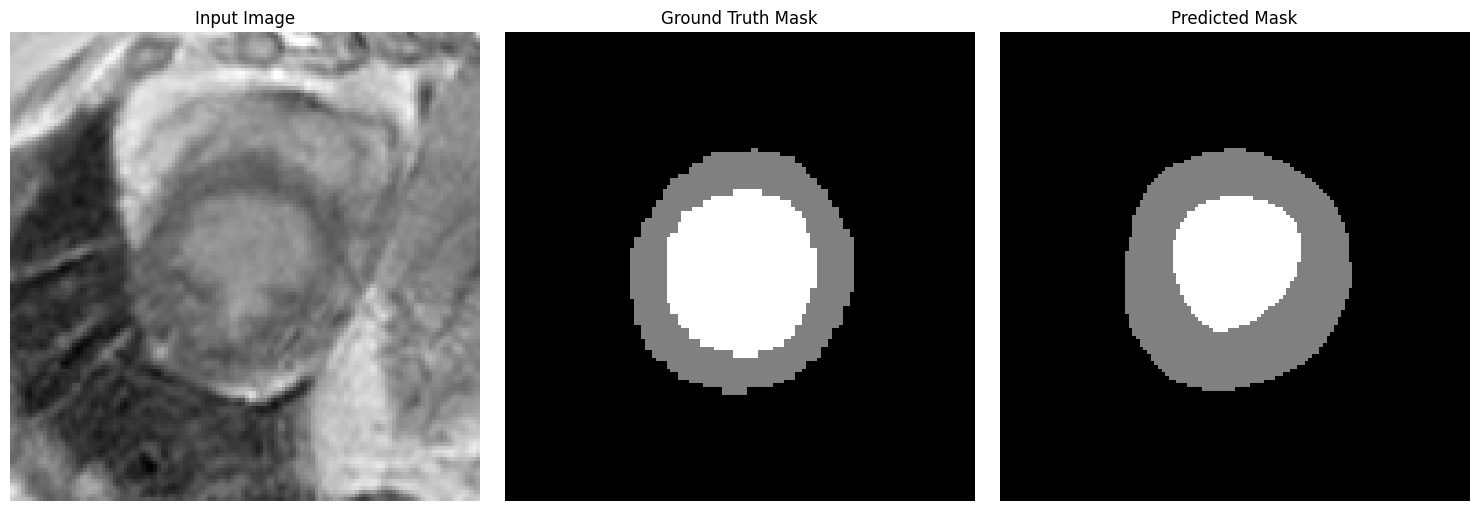


Per-class Dice scores:
  Class 0: Dice = 0.9805
  Class 1: Dice = 0.9204
  Class 2: Dice = 0.7899
  Class 3: Dice = 0.5871
  Class 4: Dice = 0.3134

Epoch 9: Mean Dice = 0.7183
✅ New best Dice score! Model saved to /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 331s 222ms/step - loss: 0.5834 - sparse_categorical_accuracy: 0.9615 - val_loss: 1.0004 - val_sparse_categorical_accuracy: 0.9466
Epoch 10/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.5954 - sparse_categorical_accuracy: 0.9601Saved checkpoint: /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/ckpt/ckpt-epoch10.weights.h5
Generating predictions at epoch 10


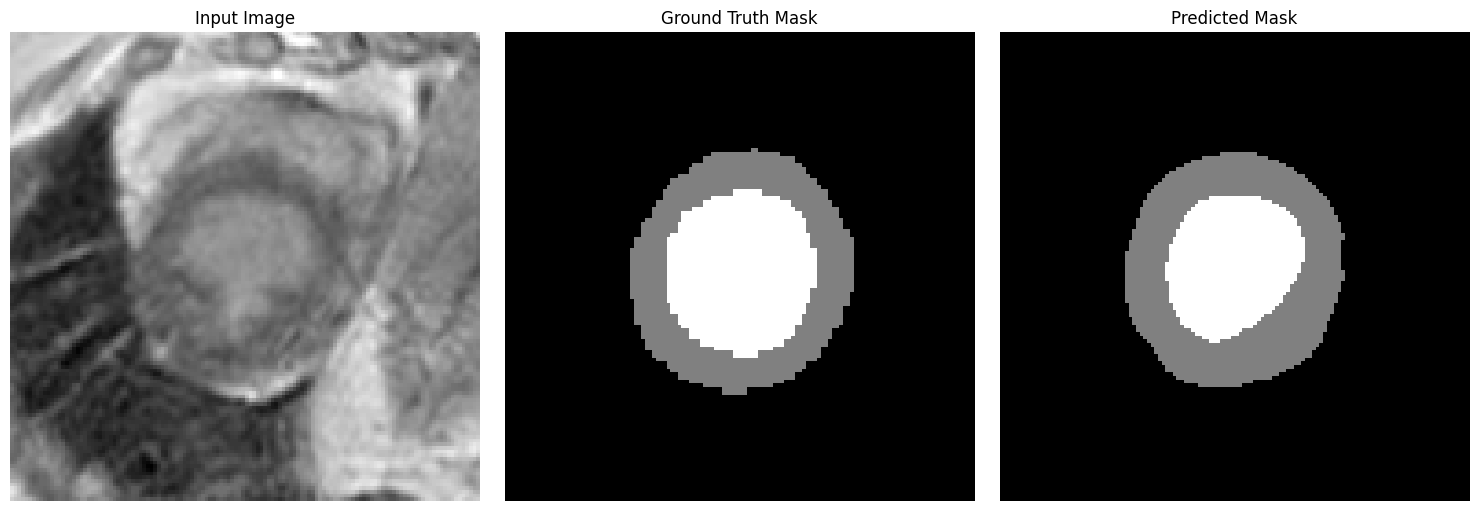


Per-class Dice scores:
  Class 0: Dice = 0.9809
  Class 1: Dice = 0.9182
  Class 2: Dice = 0.7904
  Class 3: Dice = 0.5377
  Class 4: Dice = 0.3419

Epoch 10: Mean Dice = 0.7138
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 319s 220ms/step - loss: 0.5954 - sparse_categorical_accuracy: 0.9601 - val_loss: 1.0776 - val_sparse_categorical_accuracy: 0.9462
Epoch 11/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.5311 - sparse_categorical_accuracy: 0.9638Generating predictions at epoch 11


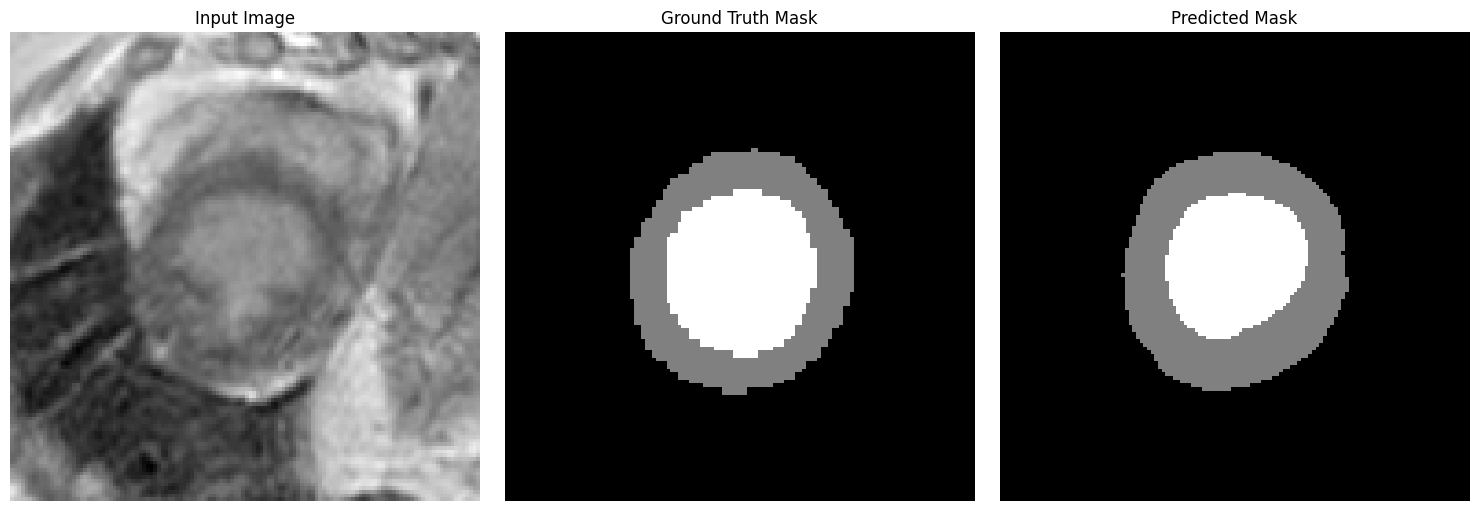


Per-class Dice scores:
  Class 0: Dice = 0.9790
  Class 1: Dice = 0.9200
  Class 2: Dice = 0.7795
  Class 3: Dice = 0.5434
  Class 4: Dice = 0.2914

Epoch 11: Mean Dice = 0.7027
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 316s 215ms/step - loss: 0.5311 - sparse_categorical_accuracy: 0.9638 - val_loss: 1.0886 - val_sparse_categorical_accuracy: 0.9428
Epoch 12/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.5193 - sparse_categorical_accuracy: 0.9650Generating predictions at epoch 12


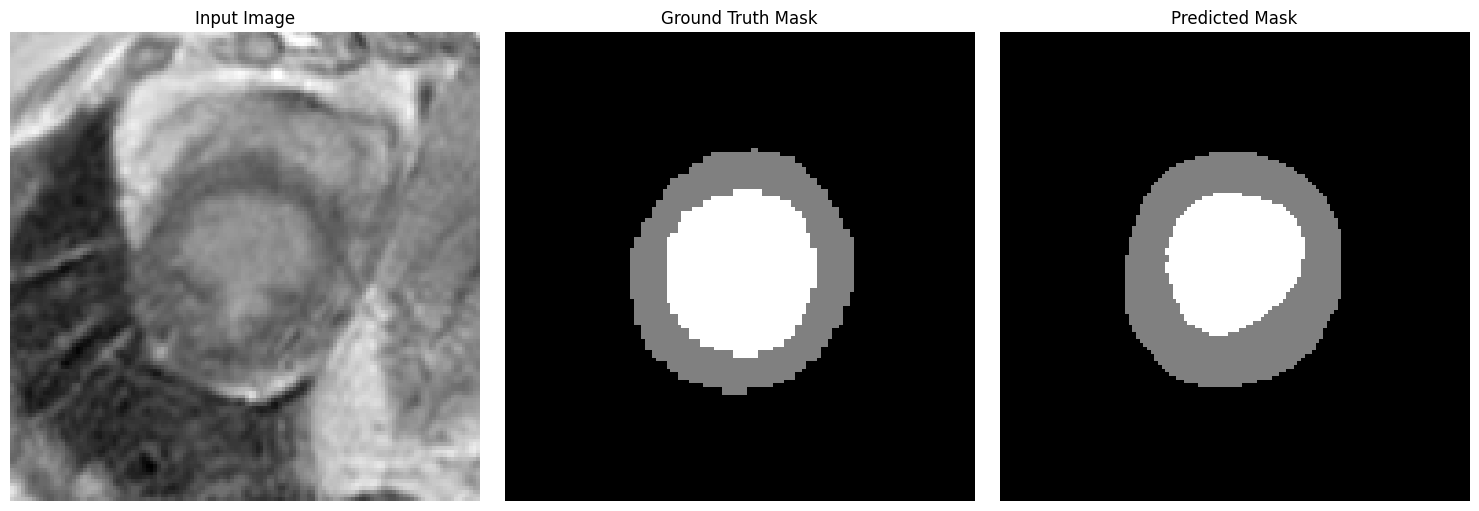


Per-class Dice scores:
  Class 0: Dice = 0.9835
  Class 1: Dice = 0.9220
  Class 2: Dice = 0.8128
  Class 3: Dice = 0.5541
  Class 4: Dice = 0.3404

Epoch 12: Mean Dice = 0.7226
✅ New best Dice score! Model saved to /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 333s 224ms/step - loss: 0.5193 - sparse_categorical_accuracy: 0.9650 - val_loss: 1.0532 - val_sparse_categorical_accuracy: 0.9510
Epoch 13/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.4834 - sparse_categorical_accuracy: 0.9663Generating predictions at epoch 13


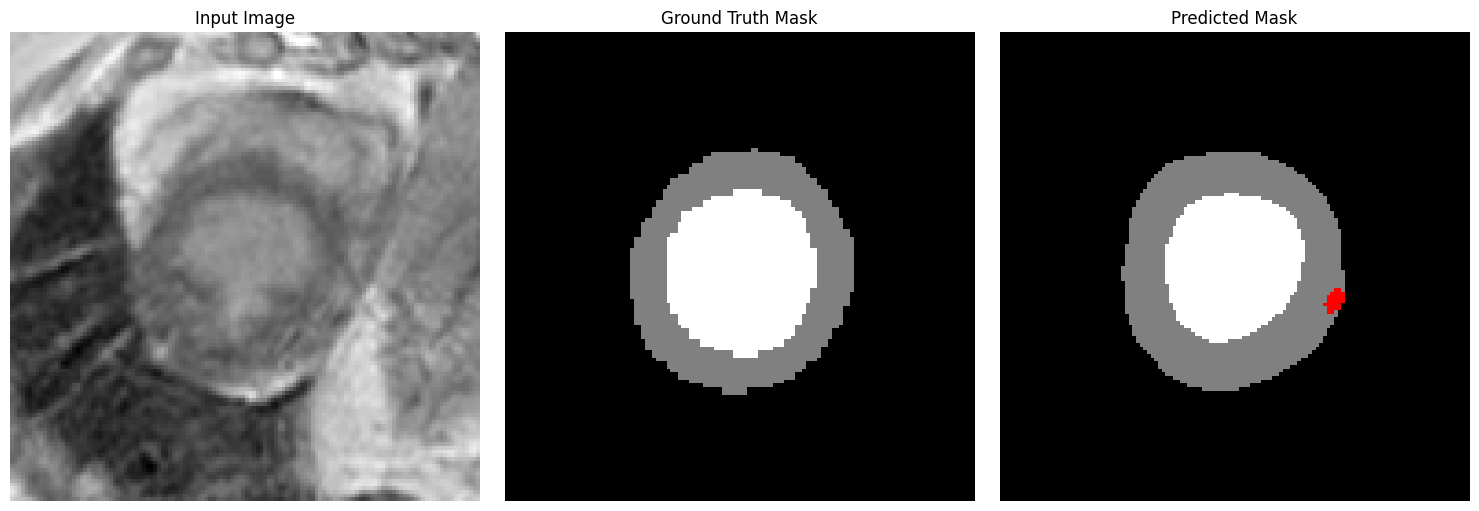


Per-class Dice scores:
  Class 0: Dice = 0.9824
  Class 1: Dice = 0.9287
  Class 2: Dice = 0.7959
  Class 3: Dice = 0.5813
  Class 4: Dice = 0.3600

Epoch 13: Mean Dice = 0.7297
✅ New best Dice score! Model saved to /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 324s 226ms/step - loss: 0.4834 - sparse_categorical_accuracy: 0.9663 - val_loss: 1.1001 - val_sparse_categorical_accuracy: 0.9503
Epoch 14/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.4748 - sparse_categorical_accuracy: 0.9670Generating predictions at epoch 14


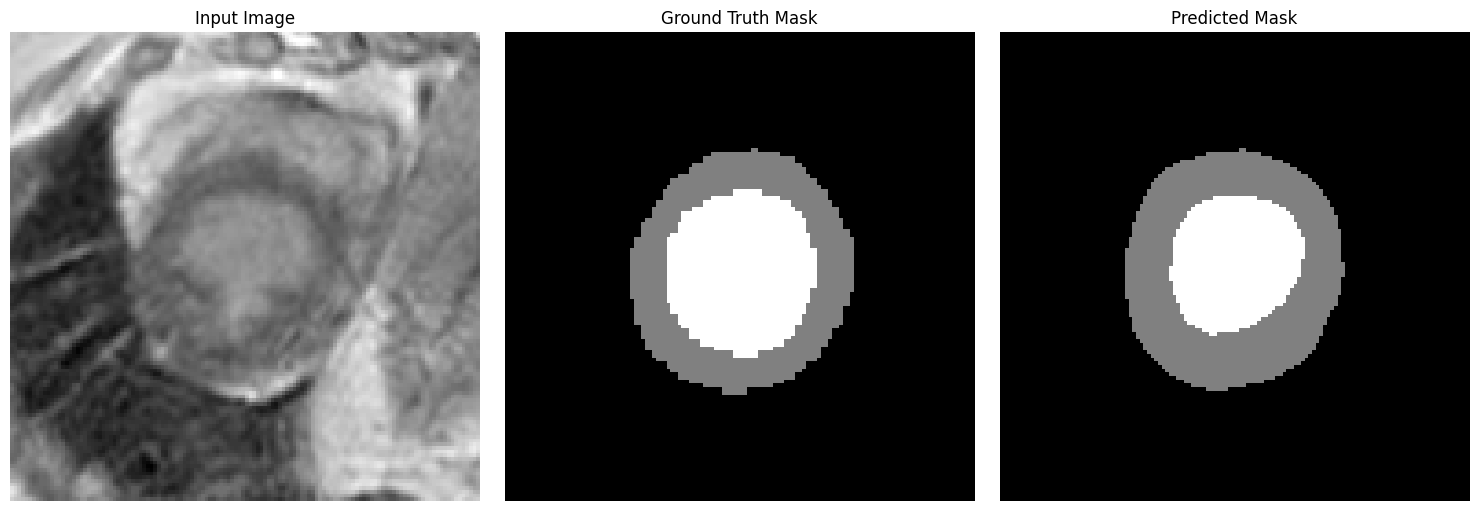


Per-class Dice scores:
  Class 0: Dice = 0.9838
  Class 1: Dice = 0.9188
  Class 2: Dice = 0.8071
  Class 3: Dice = 0.5948
  Class 4: Dice = 0.4034

Epoch 14: Mean Dice = 0.7416
✅ New best Dice score! Model saved to /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 320s 224ms/step - loss: 0.4748 - sparse_categorical_accuracy: 0.9670 - val_loss: 1.0775 - val_sparse_categorical_accuracy: 0.9517
Epoch 15/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 0.4414 - sparse_categorical_accuracy: 0.9690Generating predictions at epoch 15


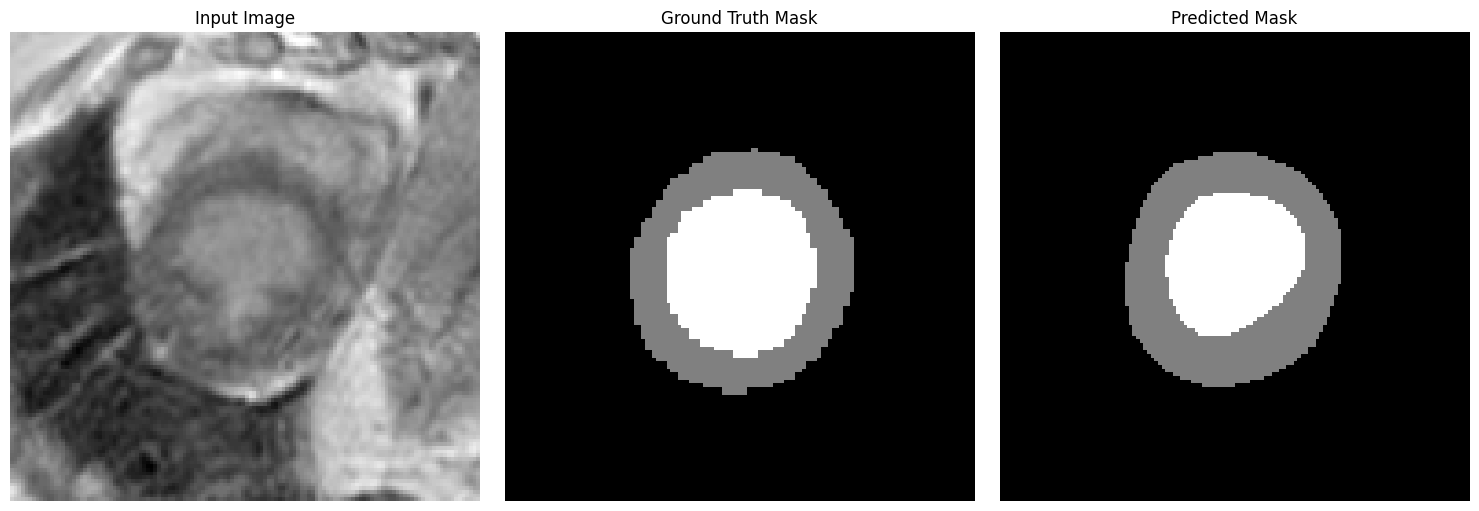


Per-class Dice scores:
  Class 0: Dice = 0.9858
  Class 1: Dice = 0.9228
  Class 2: Dice = 0.8146
  Class 3: Dice = 0.5839
  Class 4: Dice = 0.4976

Epoch 15: Mean Dice = 0.7609
✅ New best Dice score! Model saved to /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 277s 222ms/step - loss: 0.4414 - sparse_categorical_accuracy: 0.9690 - val_loss: 1.2417 - val_sparse_categorical_accuracy: 0.9554
Epoch 16/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.4296 - sparse_categorical_accuracy: 0.9699Generating predictions at epoch 16


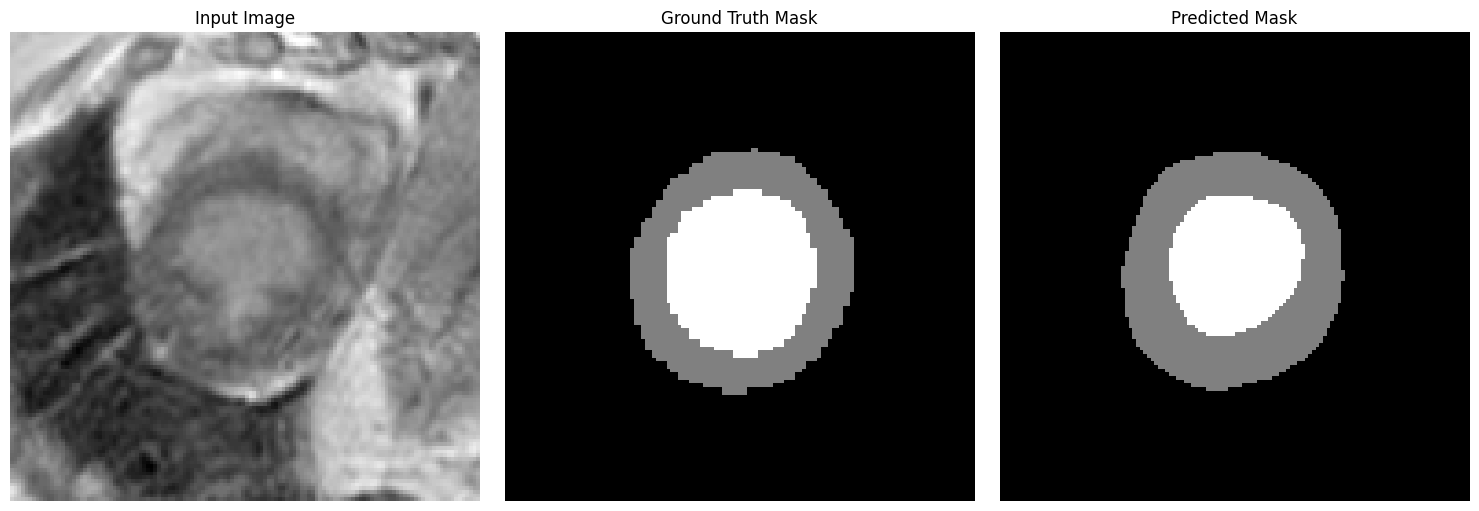


Per-class Dice scores:
  Class 0: Dice = 0.9837
  Class 1: Dice = 0.9218
  Class 2: Dice = 0.8033
  Class 3: Dice = 0.5883
  Class 4: Dice = 0.4205

Epoch 16: Mean Dice = 0.7435
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 314s 215ms/step - loss: 0.4296 - sparse_categorical_accuracy: 0.9699 - val_loss: 1.1111 - val_sparse_categorical_accuracy: 0.9515
Epoch 17/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.4159 - sparse_categorical_accuracy: 0.9705Generating predictions at epoch 17


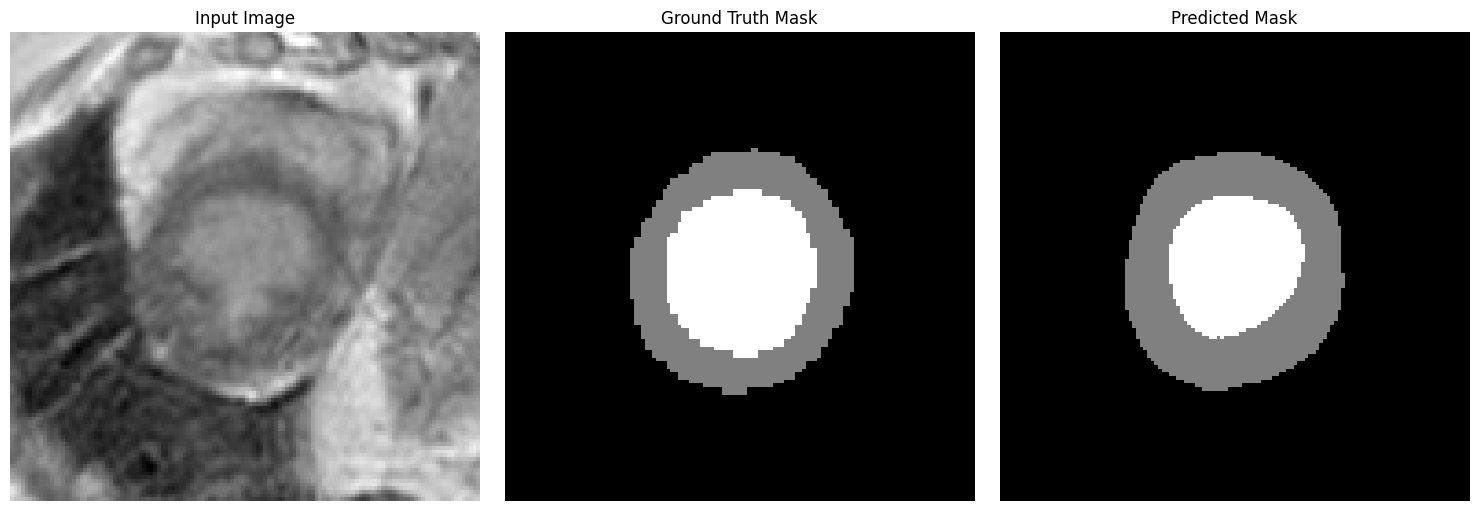


Per-class Dice scores:
  Class 0: Dice = 0.9837
  Class 1: Dice = 0.9217
  Class 2: Dice = 0.8056
  Class 3: Dice = 0.5919
  Class 4: Dice = 0.3978

Epoch 17: Mean Dice = 0.7401
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 269s 215ms/step - loss: 0.4159 - sparse_categorical_accuracy: 0.9705 - val_loss: 1.2250 - val_sparse_categorical_accuracy: 0.9516
Epoch 18/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.3919 - sparse_categorical_accuracy: 0.9719Generating predictions at epoch 18


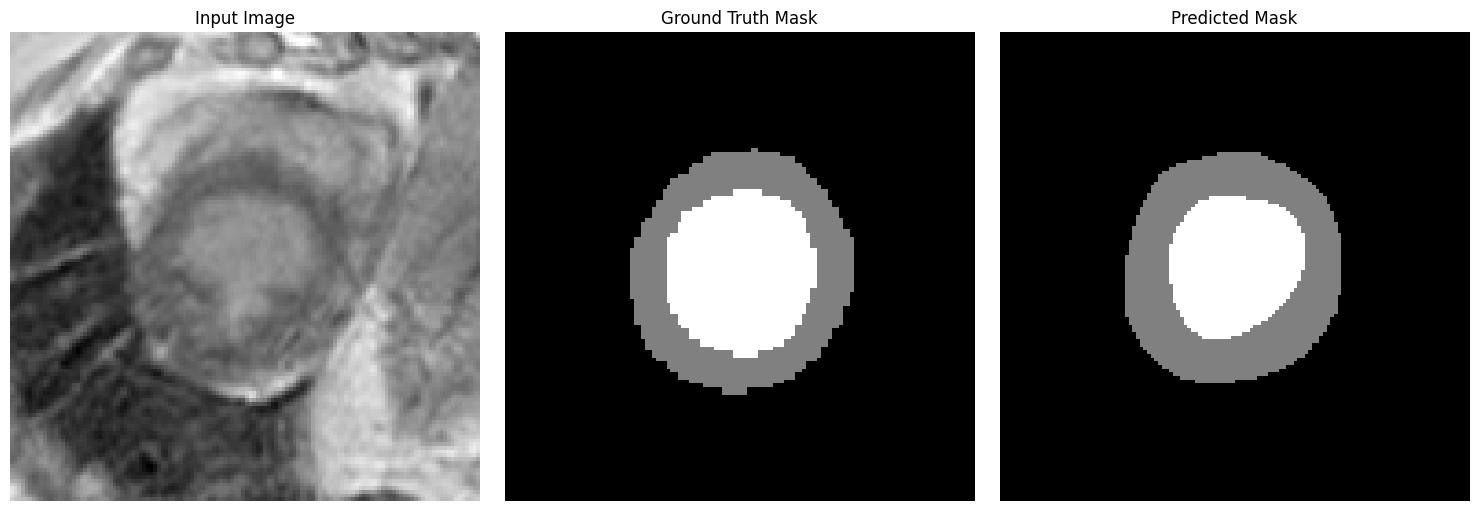


Per-class Dice scores:
  Class 0: Dice = 0.9852
  Class 1: Dice = 0.9257
  Class 2: Dice = 0.8147
  Class 3: Dice = 0.5938
  Class 4: Dice = 0.4960

Epoch 18: Mean Dice = 0.7631
✅ New best Dice score! Model saved to /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/best/best_model_dice.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 278s 223ms/step - loss: 0.3919 - sparse_categorical_accuracy: 0.9719 - val_loss: 1.2020 - val_sparse_categorical_accuracy: 0.9551
Epoch 19/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.3847 - sparse_categorical_accuracy: 0.9725Generating predictions at epoch 19


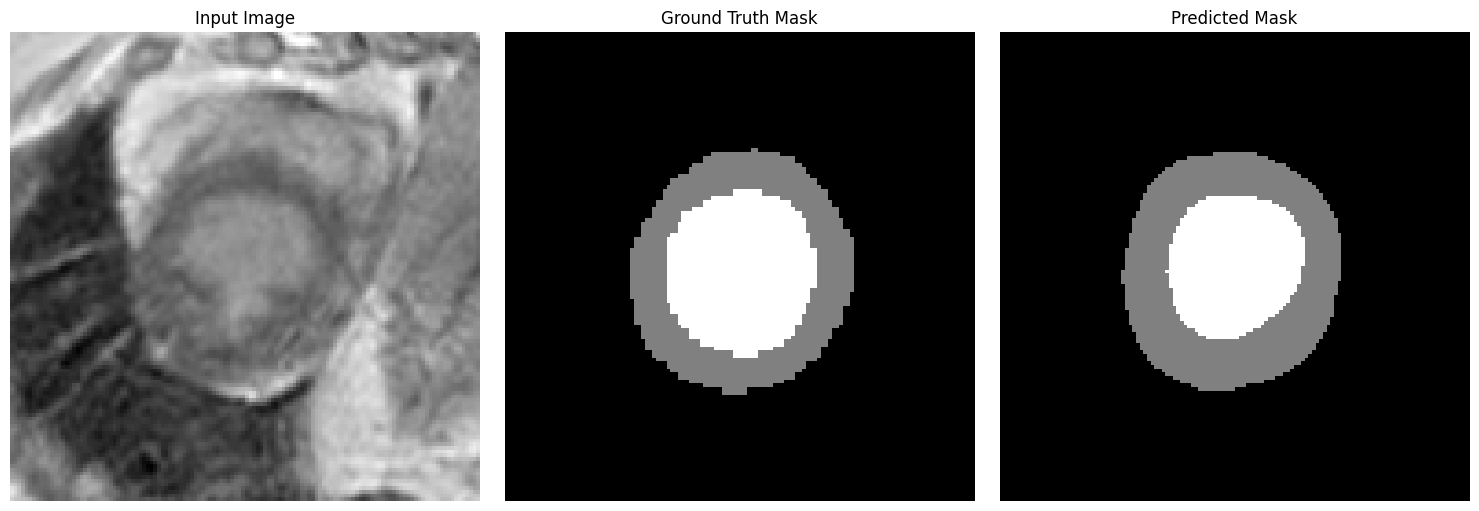


Per-class Dice scores:
  Class 0: Dice = 0.9833
  Class 1: Dice = 0.9282
  Class 2: Dice = 0.8018
  Class 3: Dice = 0.5776
  Class 4: Dice = 0.3551

Epoch 19: Mean Dice = 0.7292
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 312s 215ms/step - loss: 0.3847 - sparse_categorical_accuracy: 0.9725 - val_loss: 1.2396 - val_sparse_categorical_accuracy: 0.9511
Epoch 20/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.3643 - sparse_categorical_accuracy: 0.9736Saved checkpoint: /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/ckpt/ckpt-epoch20.weights.h5
Generating predictions at epoch 20


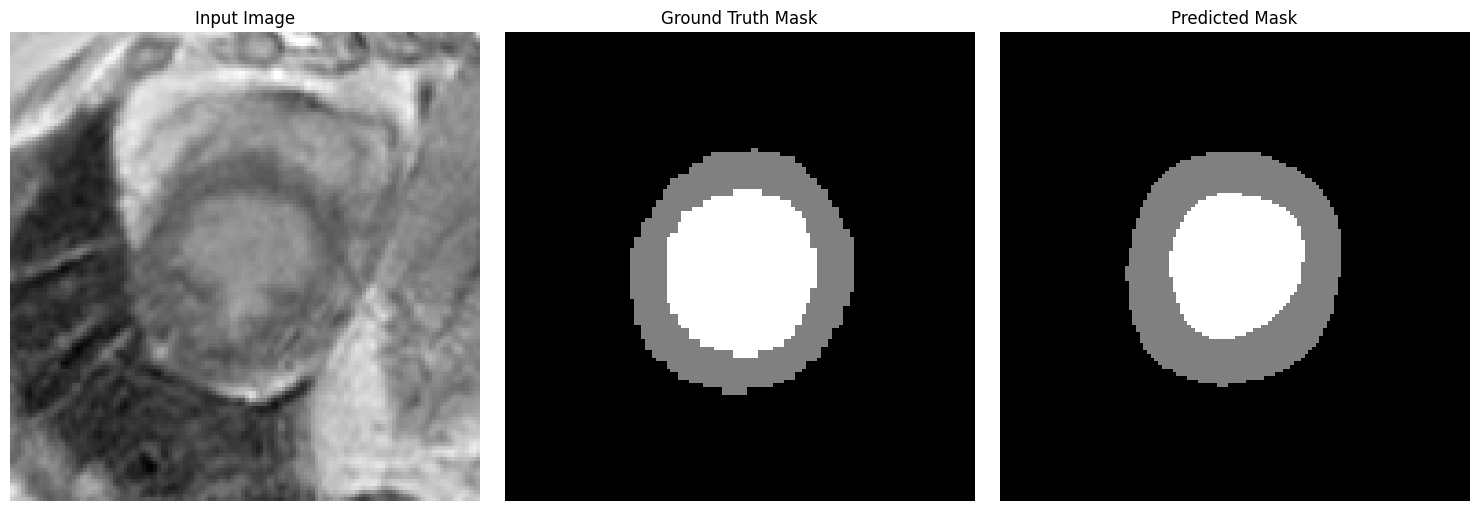


Per-class Dice scores:
  Class 0: Dice = 0.9860
  Class 1: Dice = 0.9321
  Class 2: Dice = 0.8178
  Class 3: Dice = 0.6026
  Class 4: Dice = 0.4119

Epoch 20: Mean Dice = 0.7501
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 275s 220ms/step - loss: 0.3643 - sparse_categorical_accuracy: 0.9736 - val_loss: 1.2504 - val_sparse_categorical_accuracy: 0.9568
Epoch 21/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.3523 - sparse_categorical_accuracy: 0.9744Generating predictions at epoch 21


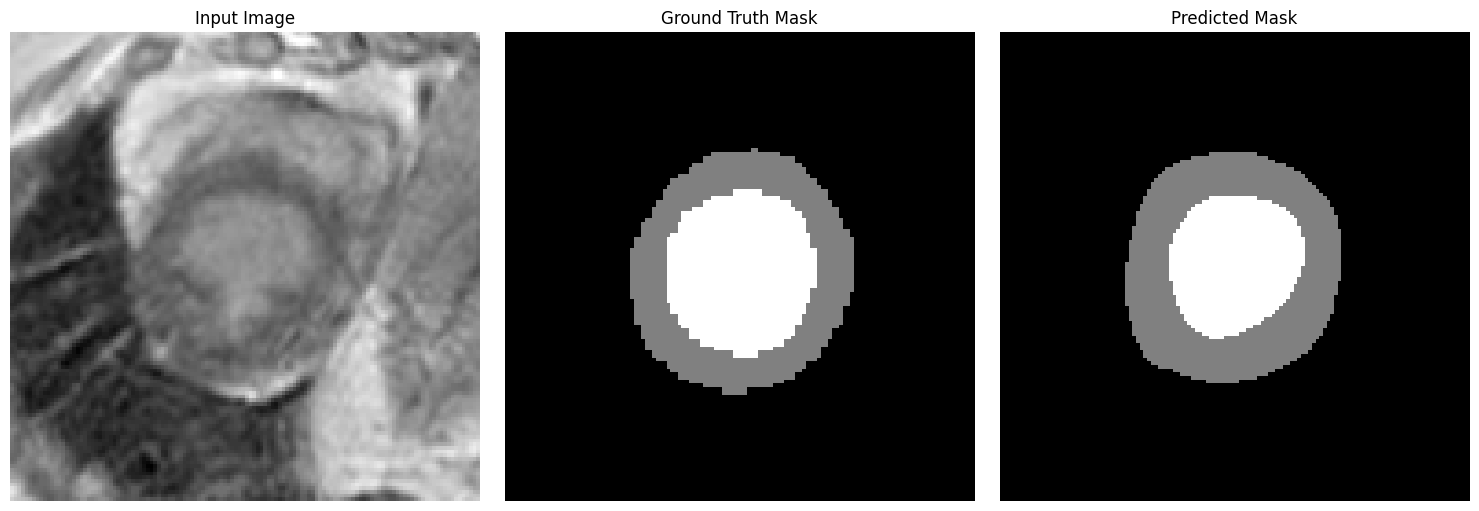


Per-class Dice scores:
  Class 0: Dice = 0.9848
  Class 1: Dice = 0.9272
  Class 2: Dice = 0.8114
  Class 3: Dice = 0.5849
  Class 4: Dice = 0.3915

Epoch 21: Mean Dice = 0.7400
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 315s 214ms/step - loss: 0.3523 - sparse_categorical_accuracy: 0.9744 - val_loss: 1.2618 - val_sparse_categorical_accuracy: 0.9539
Epoch 22/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.3413 - sparse_categorical_accuracy: 0.9751Generating predictions at epoch 22


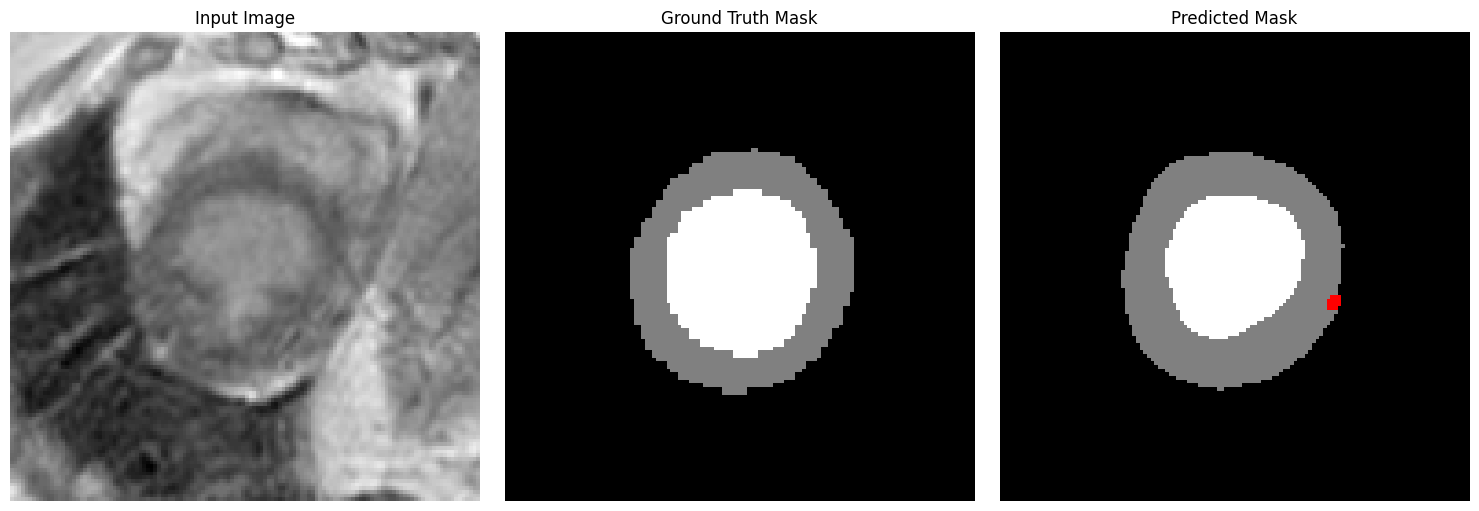


Per-class Dice scores:
  Class 0: Dice = 0.9842
  Class 1: Dice = 0.9282
  Class 2: Dice = 0.8079
  Class 3: Dice = 0.5825
  Class 4: Dice = 0.3488

Epoch 22: Mean Dice = 0.7303
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 215ms/step - loss: 0.3413 - sparse_categorical_accuracy: 0.9751 - val_loss: 1.3906 - val_sparse_categorical_accuracy: 0.9534
Epoch 23/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.3434 - sparse_categorical_accuracy: 0.9752Generating predictions at epoch 23


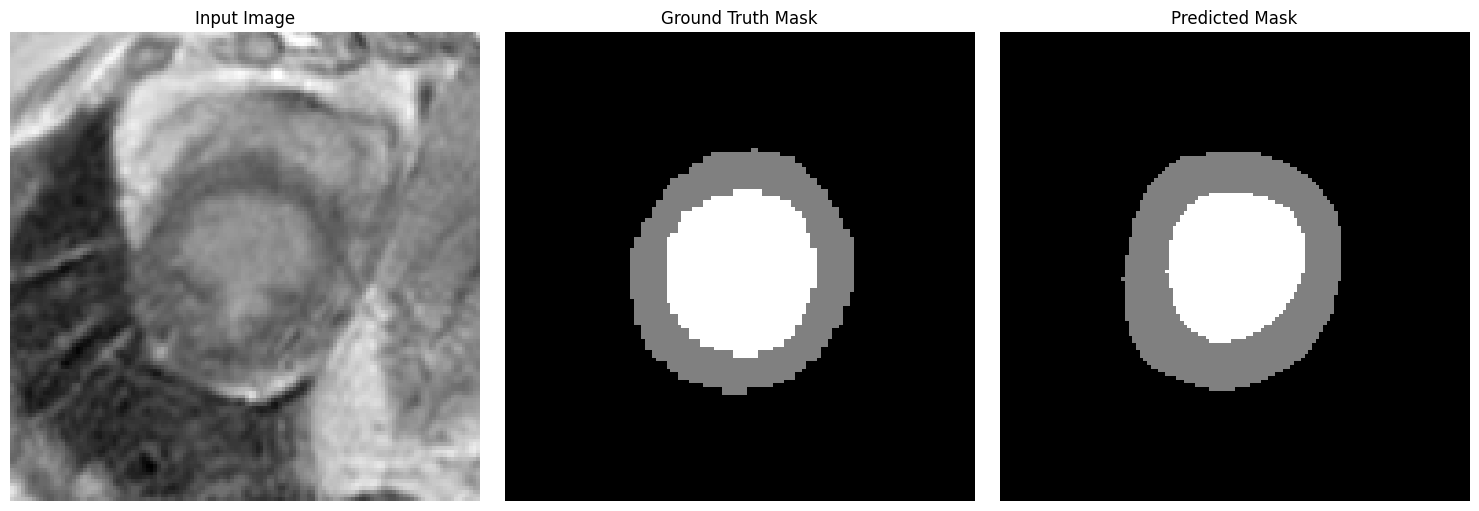


Per-class Dice scores:
  Class 0: Dice = 0.9856
  Class 1: Dice = 0.9307
  Class 2: Dice = 0.8152
  Class 3: Dice = 0.6030
  Class 4: Dice = 0.4301

Epoch 23: Mean Dice = 0.7529
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 214ms/step - loss: 0.3434 - sparse_categorical_accuracy: 0.9752 - val_loss: 1.2569 - val_sparse_categorical_accuracy: 0.9563
Epoch 24/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.3180 - sparse_categorical_accuracy: 0.9767Generating predictions at epoch 24


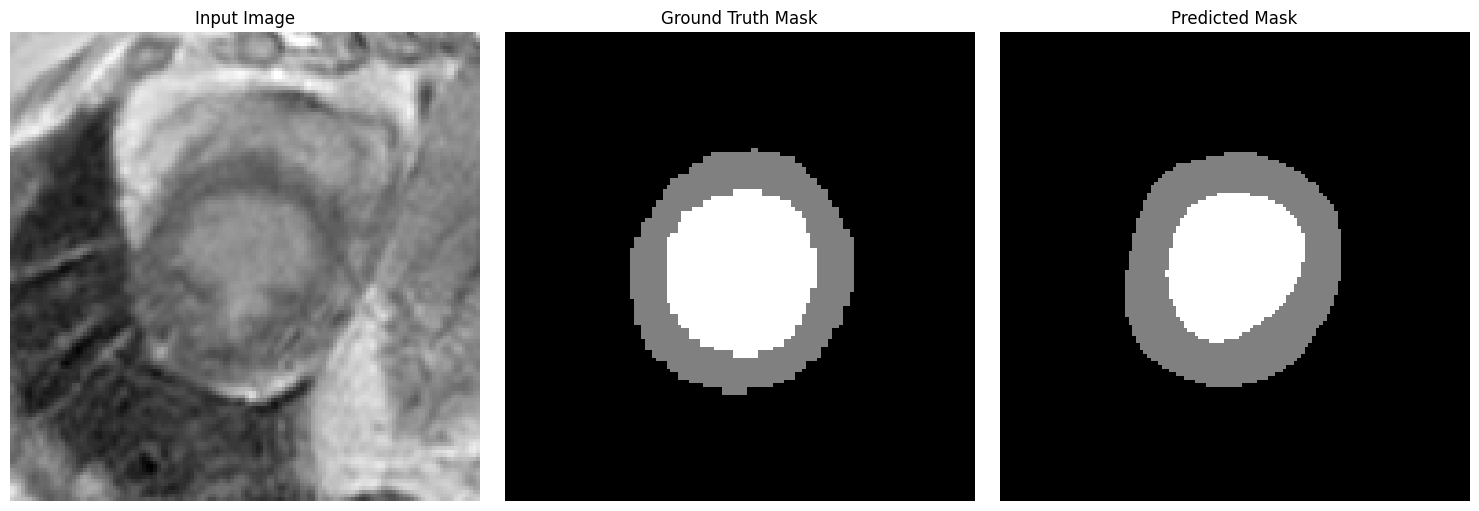


Per-class Dice scores:
  Class 0: Dice = 0.9871
  Class 1: Dice = 0.9314
  Class 2: Dice = 0.8234
  Class 3: Dice = 0.6058
  Class 4: Dice = 0.4426

Epoch 24: Mean Dice = 0.7581
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 268s 215ms/step - loss: 0.3180 - sparse_categorical_accuracy: 0.9767 - val_loss: 1.4224 - val_sparse_categorical_accuracy: 0.9588
Epoch 25/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.3103 - sparse_categorical_accuracy: 0.9773Generating predictions at epoch 25


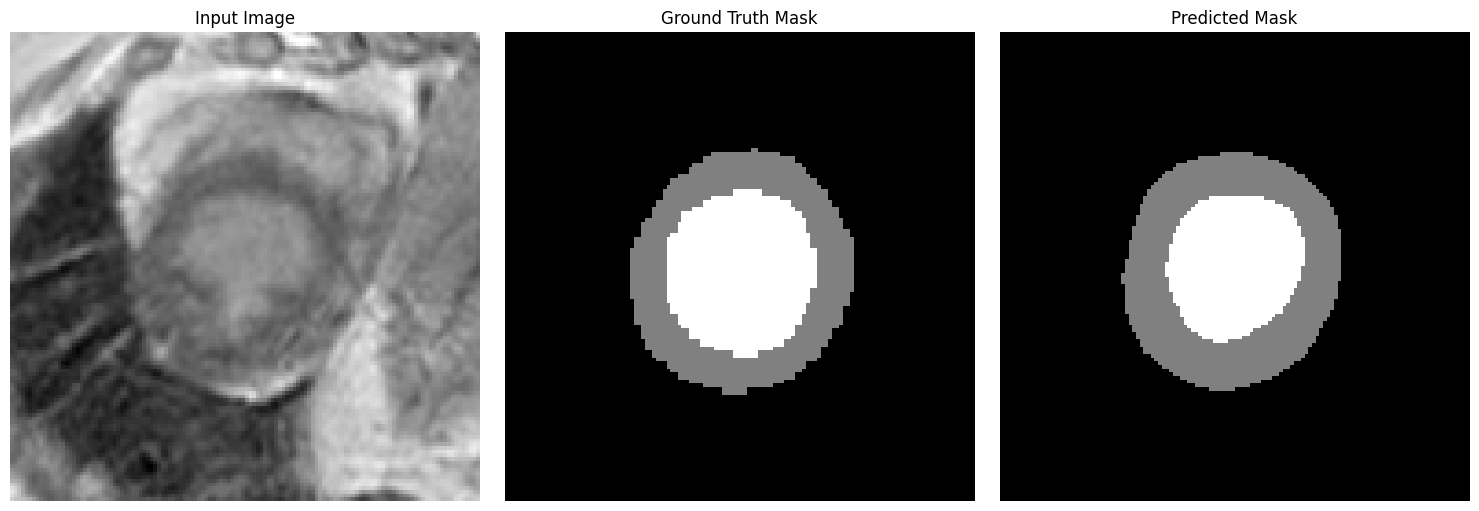


Per-class Dice scores:
  Class 0: Dice = 0.9858
  Class 1: Dice = 0.9251
  Class 2: Dice = 0.8163
  Class 3: Dice = 0.5905
  Class 4: Dice = 0.4275

Epoch 25: Mean Dice = 0.7490
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 268s 214ms/step - loss: 0.3103 - sparse_categorical_accuracy: 0.9773 - val_loss: 1.5306 - val_sparse_categorical_accuracy: 0.9559
Epoch 26/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.3013 - sparse_categorical_accuracy: 0.9777Generating predictions at epoch 26


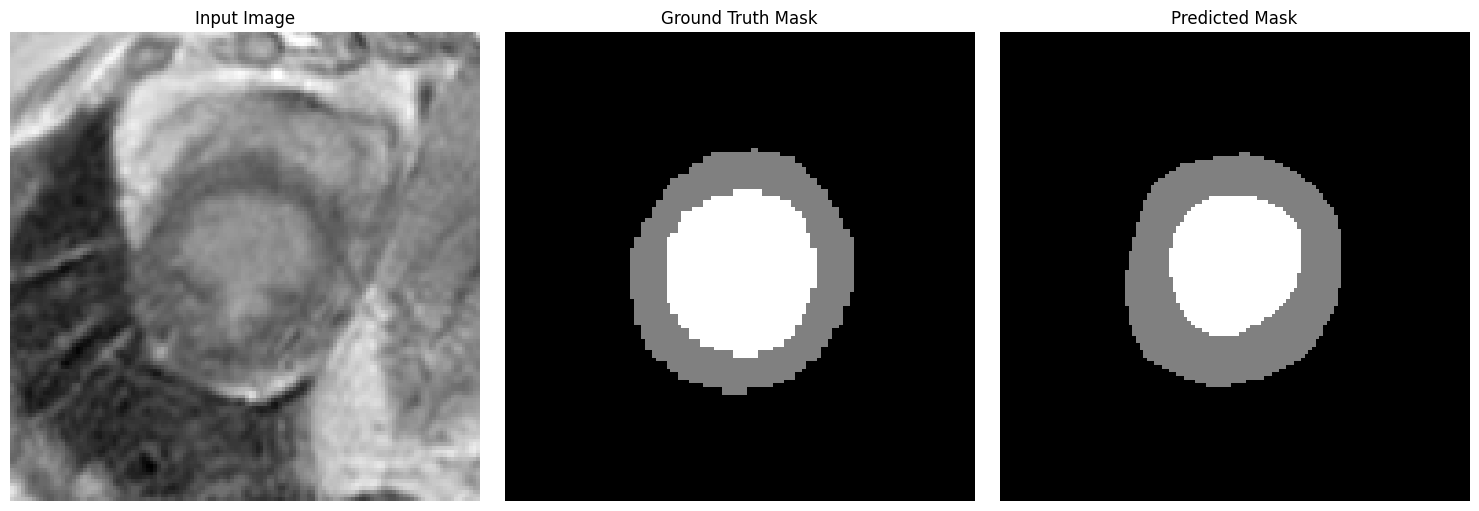


Per-class Dice scores:
  Class 0: Dice = 0.9862
  Class 1: Dice = 0.9267
  Class 2: Dice = 0.8201
  Class 3: Dice = 0.5977
  Class 4: Dice = 0.4044

Epoch 26: Mean Dice = 0.7470
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 323s 215ms/step - loss: 0.3013 - sparse_categorical_accuracy: 0.9777 - val_loss: 1.4730 - val_sparse_categorical_accuracy: 0.9567
Epoch 27/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2970 - sparse_categorical_accuracy: 0.9782Generating predictions at epoch 27


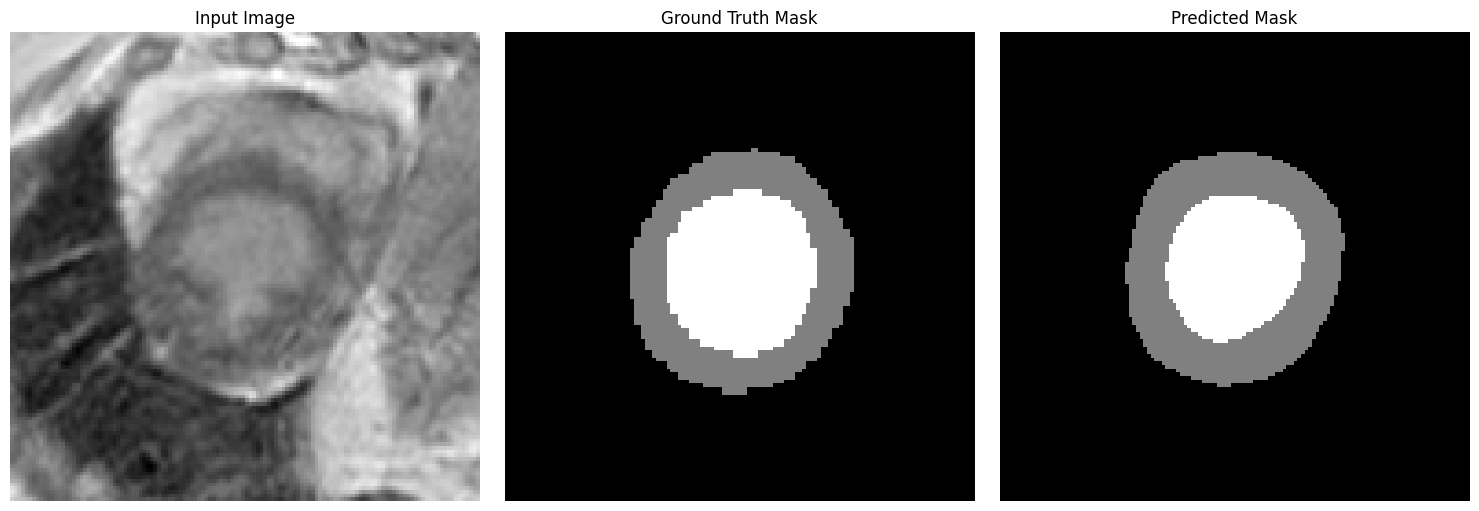


Per-class Dice scores:
  Class 0: Dice = 0.9867
  Class 1: Dice = 0.9310
  Class 2: Dice = 0.8249
  Class 3: Dice = 0.6033
  Class 4: Dice = 0.4054

Epoch 27: Mean Dice = 0.7502
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 215ms/step - loss: 0.2970 - sparse_categorical_accuracy: 0.9782 - val_loss: 1.4401 - val_sparse_categorical_accuracy: 0.9583
Epoch 28/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2900 - sparse_categorical_accuracy: 0.9786Generating predictions at epoch 28


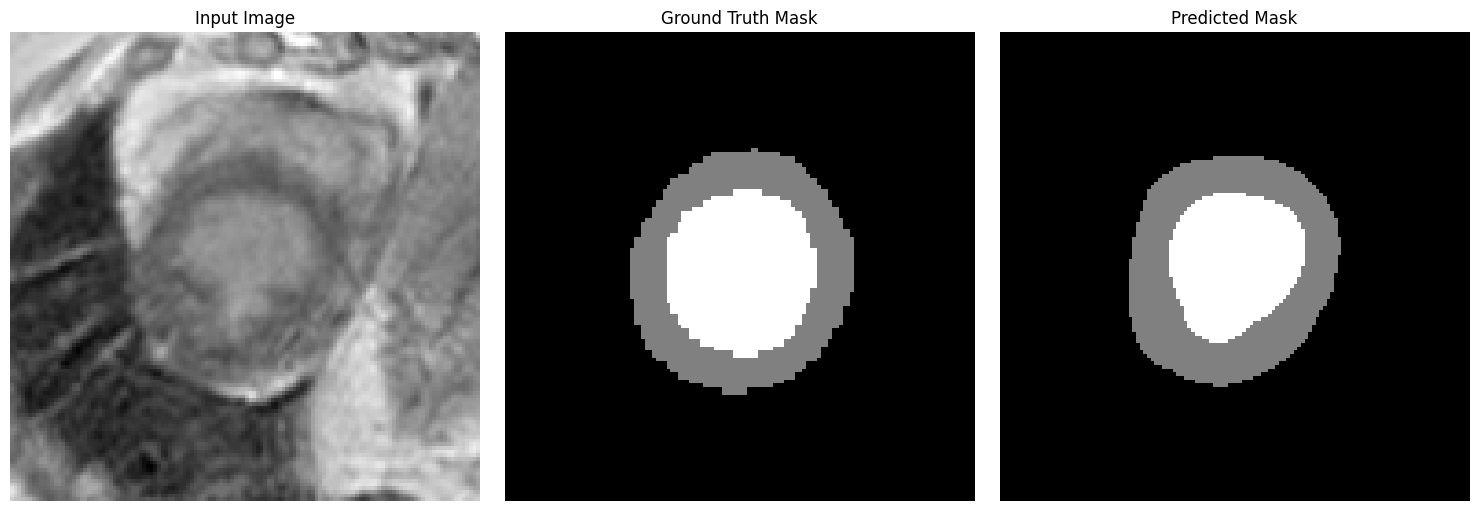


Per-class Dice scores:
  Class 0: Dice = 0.9869
  Class 1: Dice = 0.9289
  Class 2: Dice = 0.8229
  Class 3: Dice = 0.6067
  Class 4: Dice = 0.4270

Epoch 28: Mean Dice = 0.7545
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 215ms/step - loss: 0.2900 - sparse_categorical_accuracy: 0.9786 - val_loss: 1.5174 - val_sparse_categorical_accuracy: 0.9582
Epoch 29/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2828 - sparse_categorical_accuracy: 0.9791Generating predictions at epoch 29


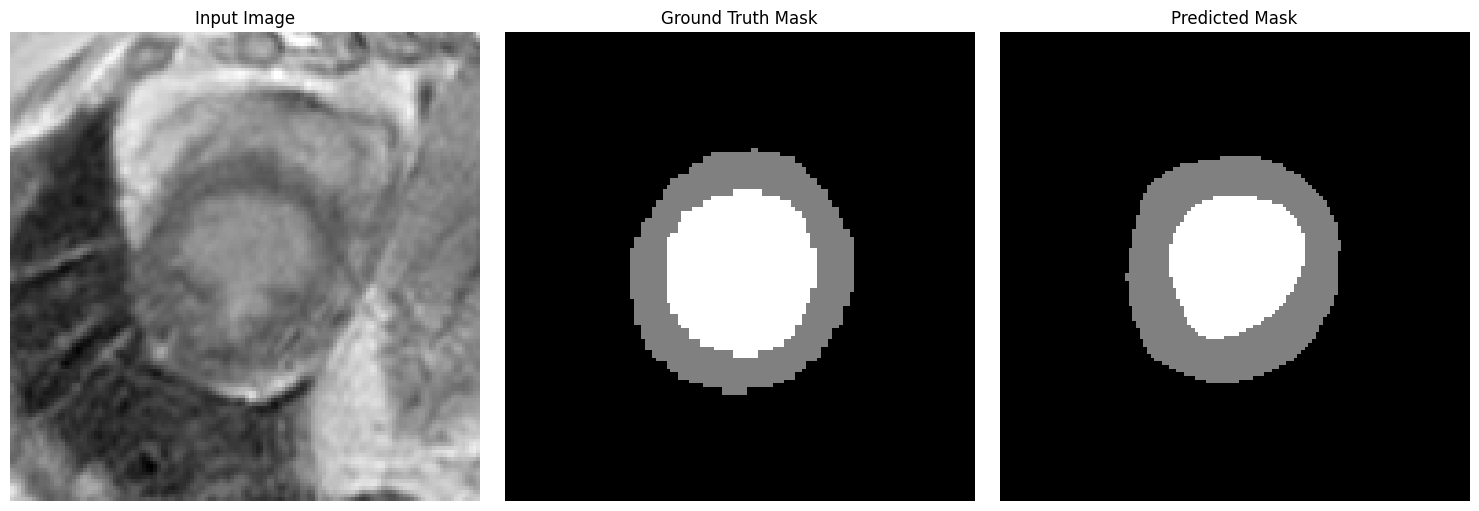


Per-class Dice scores:
  Class 0: Dice = 0.9871
  Class 1: Dice = 0.9282
  Class 2: Dice = 0.8223
  Class 3: Dice = 0.6061
  Class 4: Dice = 0.4510

Epoch 29: Mean Dice = 0.7589
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 323s 215ms/step - loss: 0.2828 - sparse_categorical_accuracy: 0.9791 - val_loss: 1.5756 - val_sparse_categorical_accuracy: 0.9585
Epoch 30/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2704 - sparse_categorical_accuracy: 0.9797Saved checkpoint: /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/ckpt/ckpt-epoch30.weights.h5
Generating predictions at epoch 30


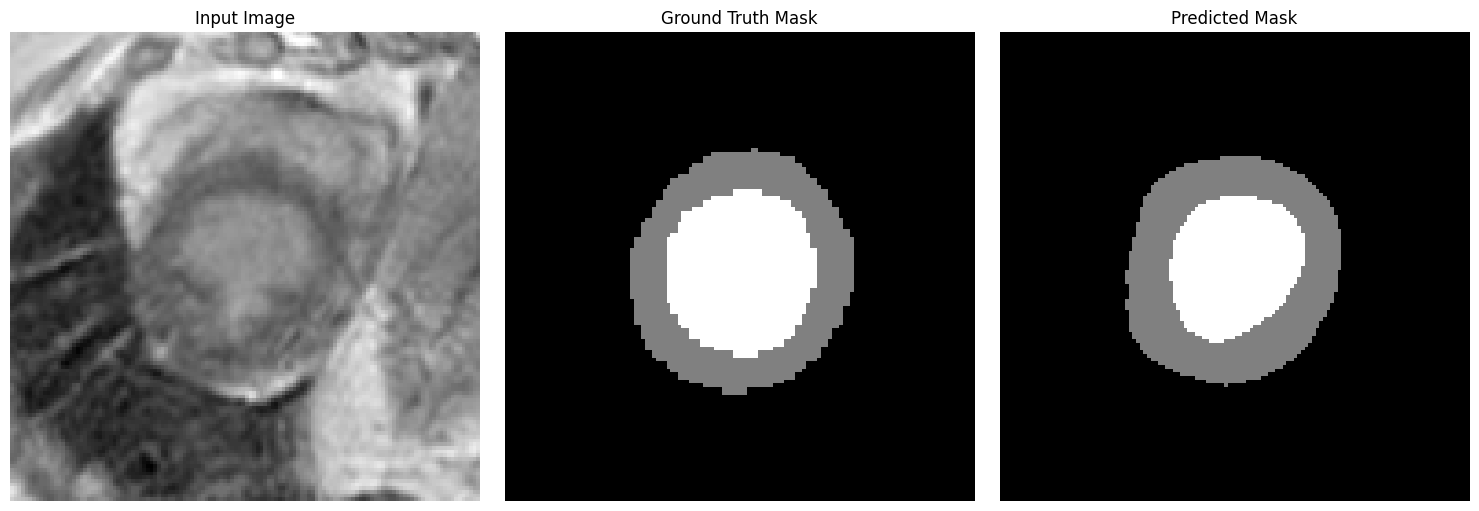


Per-class Dice scores:
  Class 0: Dice = 0.9868
  Class 1: Dice = 0.9288
  Class 2: Dice = 0.8224
  Class 3: Dice = 0.6103
  Class 4: Dice = 0.3924

Epoch 30: Mean Dice = 0.7482
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 325s 218ms/step - loss: 0.2704 - sparse_categorical_accuracy: 0.9797 - val_loss: 1.6806 - val_sparse_categorical_accuracy: 0.9585
Epoch 31/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2683 - sparse_categorical_accuracy: 0.9801Generating predictions at epoch 31


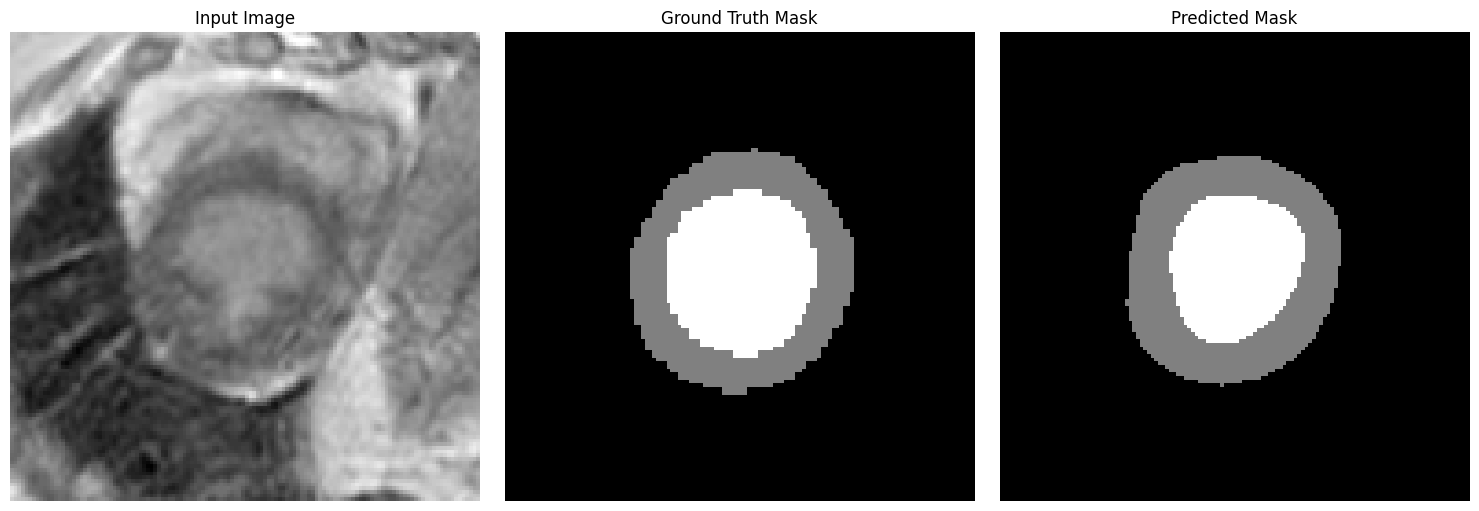


Per-class Dice scores:
  Class 0: Dice = 0.9863
  Class 1: Dice = 0.9268
  Class 2: Dice = 0.8207
  Class 3: Dice = 0.5987
  Class 4: Dice = 0.3971

Epoch 31: Mean Dice = 0.7459
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 318s 215ms/step - loss: 0.2683 - sparse_categorical_accuracy: 0.9801 - val_loss: 1.6439 - val_sparse_categorical_accuracy: 0.9573
Epoch 32/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2630 - sparse_categorical_accuracy: 0.9803Generating predictions at epoch 32


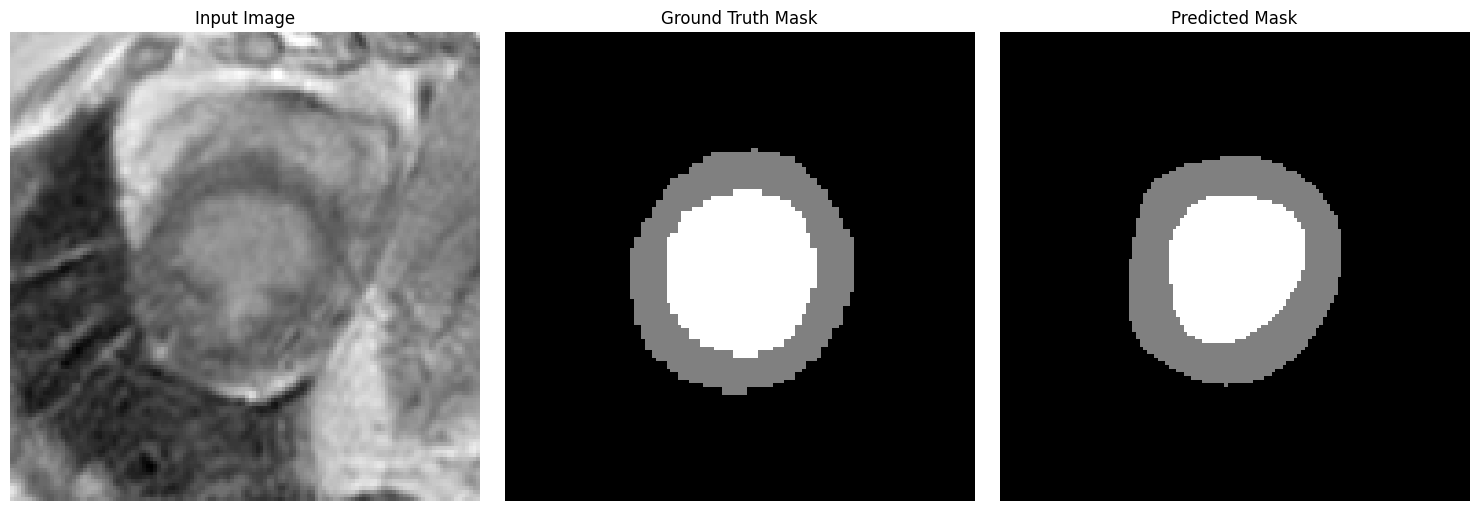


Per-class Dice scores:
  Class 0: Dice = 0.9870
  Class 1: Dice = 0.9290
  Class 2: Dice = 0.8237
  Class 3: Dice = 0.6129
  Class 4: Dice = 0.4533

Epoch 32: Mean Dice = 0.7612
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 321s 214ms/step - loss: 0.2630 - sparse_categorical_accuracy: 0.9803 - val_loss: 1.6437 - val_sparse_categorical_accuracy: 0.9589
Epoch 33/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2575 - sparse_categorical_accuracy: 0.9807Generating predictions at epoch 33


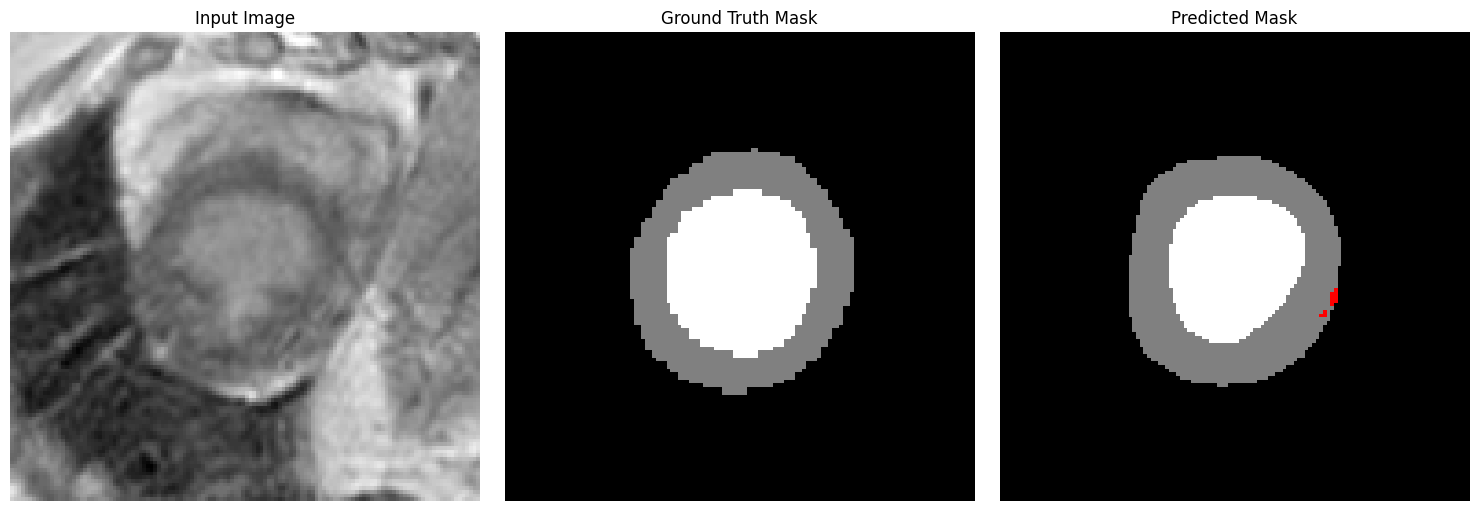


Per-class Dice scores:
  Class 0: Dice = 0.9870
  Class 1: Dice = 0.9290
  Class 2: Dice = 0.8254
  Class 3: Dice = 0.6062
  Class 4: Dice = 0.3851

Epoch 33: Mean Dice = 0.7466
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 323s 215ms/step - loss: 0.2575 - sparse_categorical_accuracy: 0.9807 - val_loss: 1.5977 - val_sparse_categorical_accuracy: 0.9587
Epoch 34/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2516 - sparse_categorical_accuracy: 0.9809Generating predictions at epoch 34


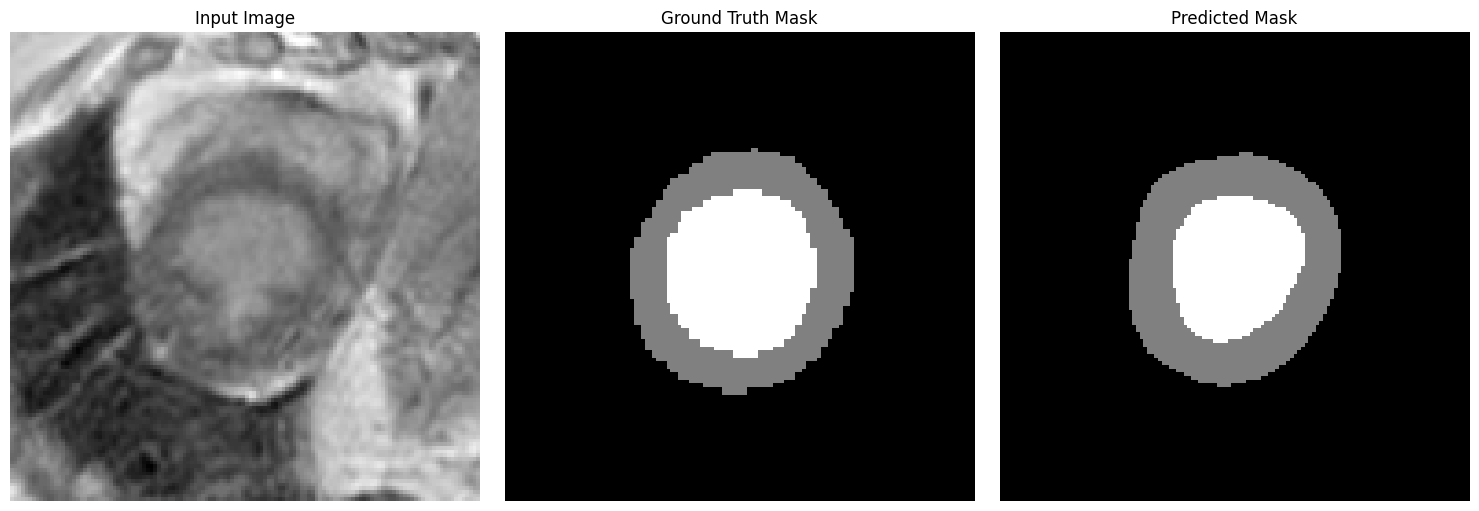


Per-class Dice scores:
  Class 0: Dice = 0.9863
  Class 1: Dice = 0.9313
  Class 2: Dice = 0.8230
  Class 3: Dice = 0.6095
  Class 4: Dice = 0.3926

Epoch 34: Mean Dice = 0.7485
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 268s 214ms/step - loss: 0.2516 - sparse_categorical_accuracy: 0.9809 - val_loss: 1.6894 - val_sparse_categorical_accuracy: 0.9584
Epoch 35/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 0.2445 - sparse_categorical_accuracy: 0.9815Generating predictions at epoch 35


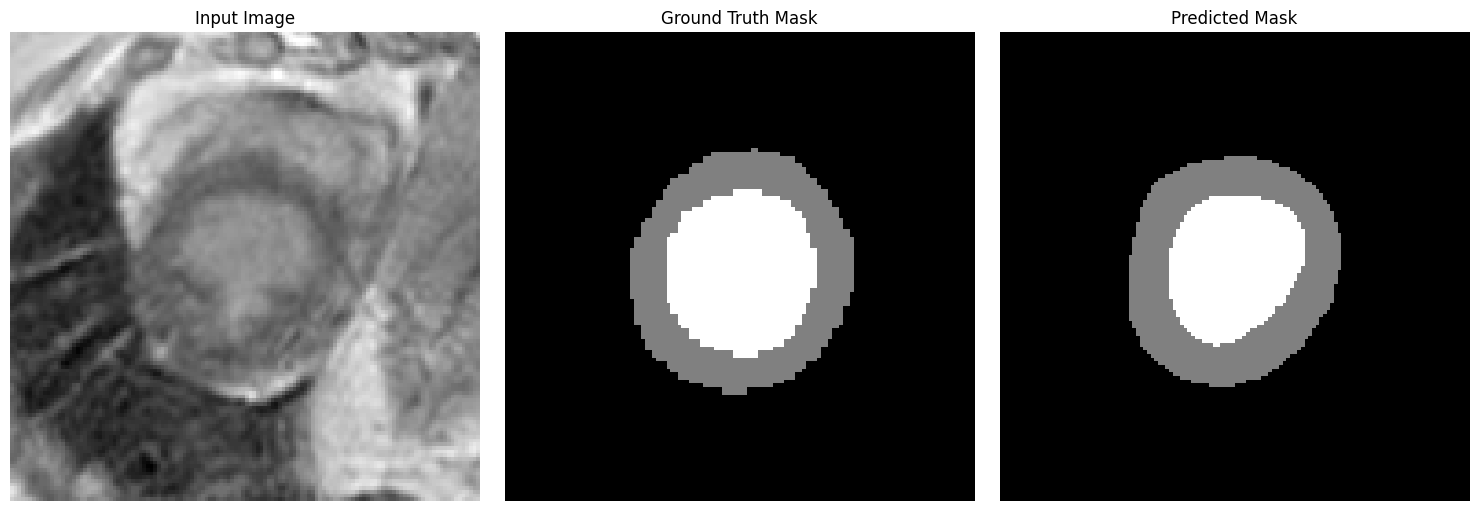


Per-class Dice scores:
  Class 0: Dice = 0.9869
  Class 1: Dice = 0.9310
  Class 2: Dice = 0.8228
  Class 3: Dice = 0.6148
  Class 4: Dice = 0.4155

Epoch 35: Mean Dice = 0.7542
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 268s 214ms/step - loss: 0.2445 - sparse_categorical_accuracy: 0.9815 - val_loss: 1.7553 - val_sparse_categorical_accuracy: 0.9590
Epoch 36/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2406 - sparse_categorical_accuracy: 0.9817Generating predictions at epoch 36


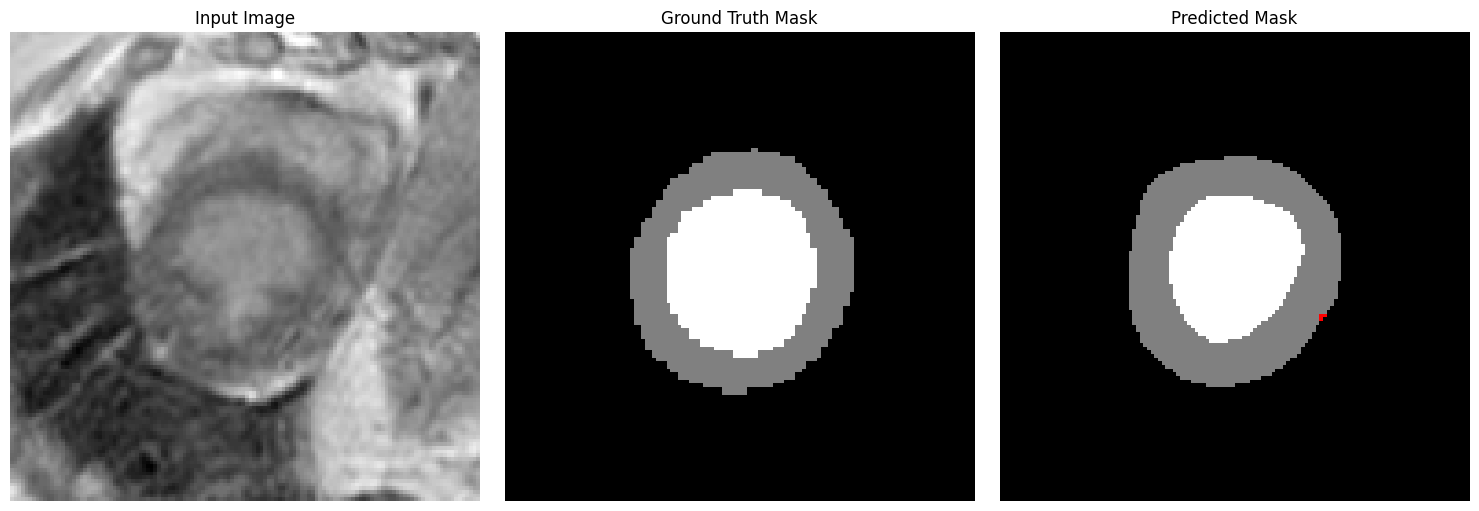


Per-class Dice scores:
  Class 0: Dice = 0.9875
  Class 1: Dice = 0.9296
  Class 2: Dice = 0.8287
  Class 3: Dice = 0.6050
  Class 4: Dice = 0.4024

Epoch 36: Mean Dice = 0.7506
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 324s 215ms/step - loss: 0.2406 - sparse_categorical_accuracy: 0.9817 - val_loss: 1.7958 - val_sparse_categorical_accuracy: 0.9598
Epoch 37/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2375 - sparse_categorical_accuracy: 0.9820Generating predictions at epoch 37


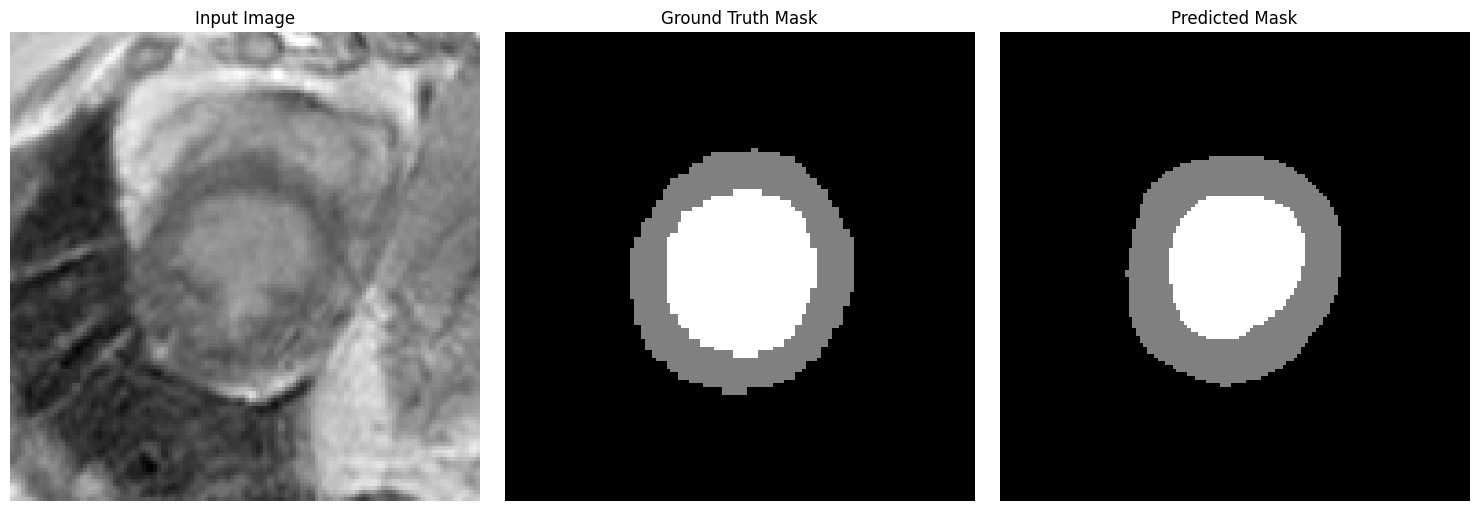


Per-class Dice scores:
  Class 0: Dice = 0.9867
  Class 1: Dice = 0.9307
  Class 2: Dice = 0.8236
  Class 3: Dice = 0.6082
  Class 4: Dice = 0.4040

Epoch 37: Mean Dice = 0.7507
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 321s 215ms/step - loss: 0.2375 - sparse_categorical_accuracy: 0.9820 - val_loss: 1.7954 - val_sparse_categorical_accuracy: 0.9586
Epoch 38/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2322 - sparse_categorical_accuracy: 0.9822Generating predictions at epoch 38


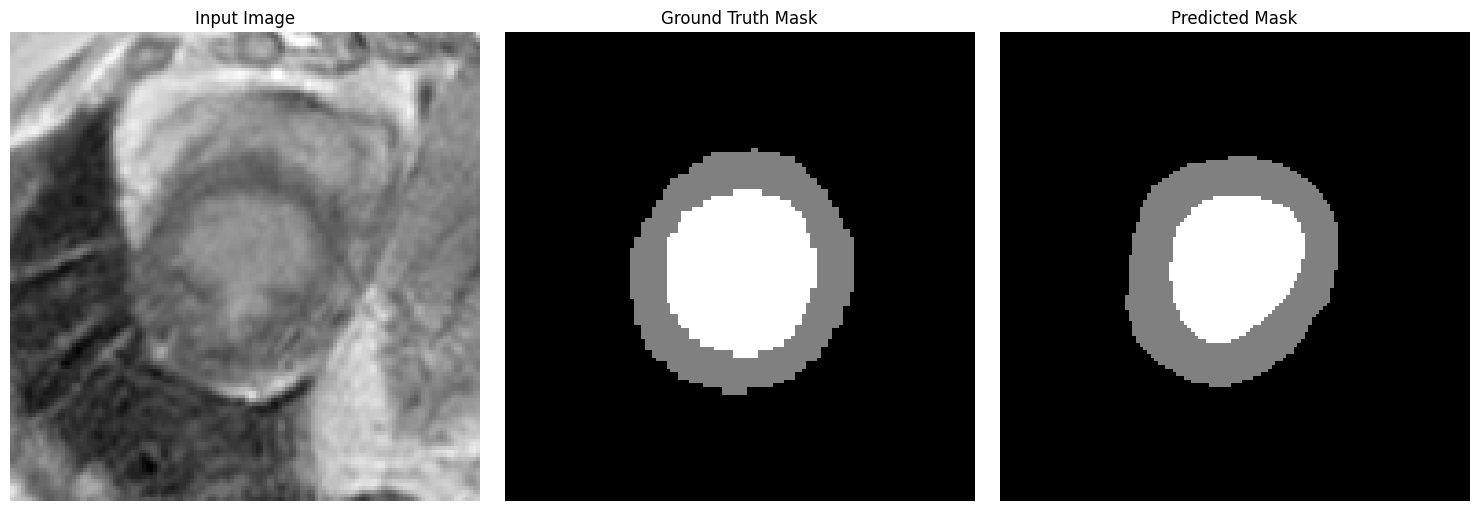


Per-class Dice scores:
  Class 0: Dice = 0.9870
  Class 1: Dice = 0.9281
  Class 2: Dice = 0.8256
  Class 3: Dice = 0.6078
  Class 4: Dice = 0.3606

Epoch 38: Mean Dice = 0.7418
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 215ms/step - loss: 0.2322 - sparse_categorical_accuracy: 0.9822 - val_loss: 1.8295 - val_sparse_categorical_accuracy: 0.9588
Epoch 39/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2304 - sparse_categorical_accuracy: 0.9825Generating predictions at epoch 39


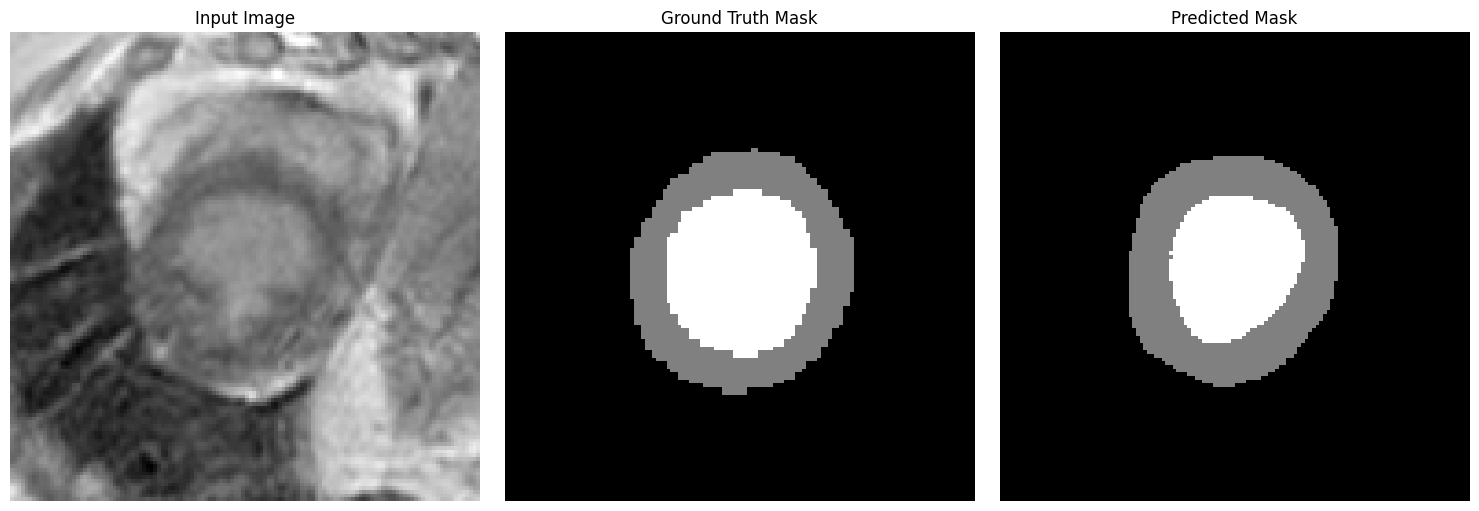


Per-class Dice scores:
  Class 0: Dice = 0.9872
  Class 1: Dice = 0.9316
  Class 2: Dice = 0.8227
  Class 3: Dice = 0.6024
  Class 4: Dice = 0.3788

Epoch 39: Mean Dice = 0.7445
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 215ms/step - loss: 0.2304 - sparse_categorical_accuracy: 0.9825 - val_loss: 1.8601 - val_sparse_categorical_accuracy: 0.9589
Epoch 40/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.2249 - sparse_categorical_accuracy: 0.9828Saved checkpoint: /content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/ckpt/ckpt-epoch40.weights.h5
Generating predictions at epoch 40


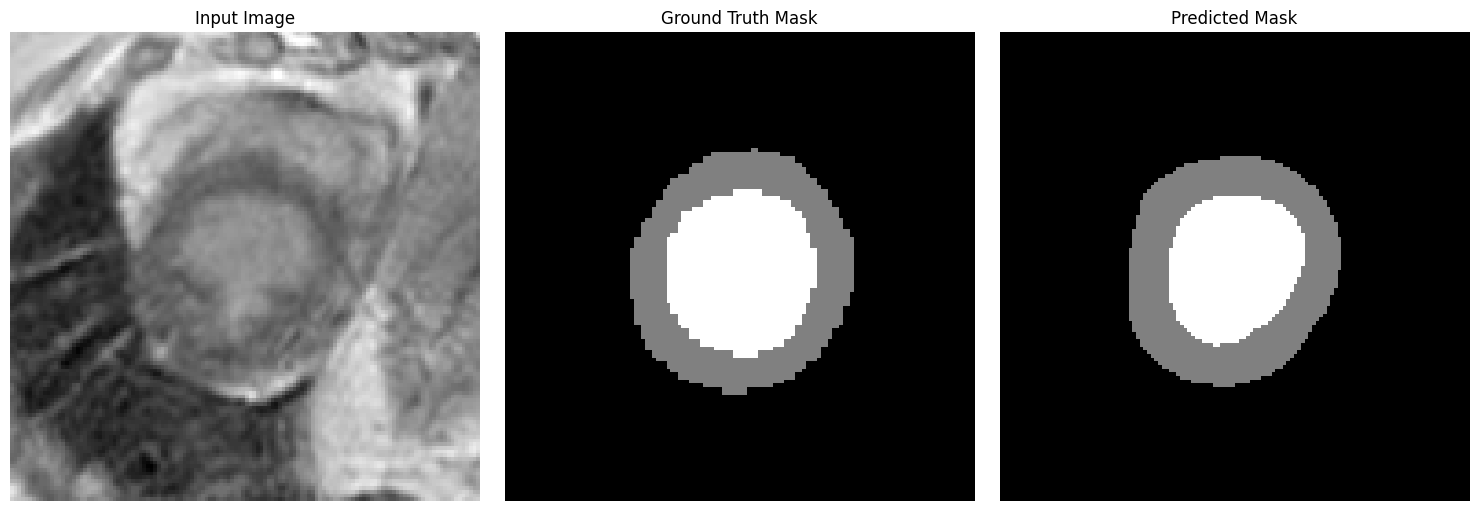


Per-class Dice scores:
  Class 0: Dice = 0.9863
  Class 1: Dice = 0.9302
  Class 2: Dice = 0.8235
  Class 3: Dice = 0.6112
  Class 4: Dice = 0.4273

Epoch 40: Mean Dice = 0.7557
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 273s 219ms/step - loss: 0.2249 - sparse_categorical_accuracy: 0.9828 - val_loss: 1.8378 - val_sparse_categorical_accuracy: 0.9583
Training time: 3:28:34.856952


In [ ]:
  # Start training
  start = datetime.now()

  history = model.fit(
      x=train_images_tensor,
      y=train_masks_tensor,
      batch_size=batch_size,
      epochs=40,
      verbose=1,
      validation_data=(val_images_tensor, val_masks_tensor),
      shuffle=True,
      callbacks=callbacks
  )

  stop = datetime.now()
  print("Training time:", stop - start)

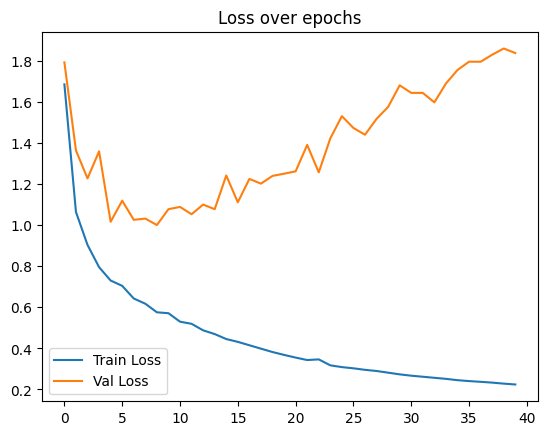

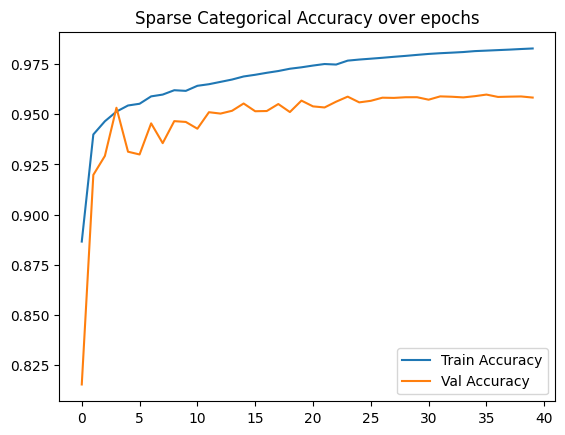

In [ ]:
# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over epochs")
plt.legend()
plt.show()

# Plot accuracy
plt.plot(history.history['sparse_categorical_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Val Accuracy')
plt.title("Sparse Categorical Accuracy over epochs")
plt.legend()
plt.show()

  0%|          | 0/80 [00:00<?, ?it/s]

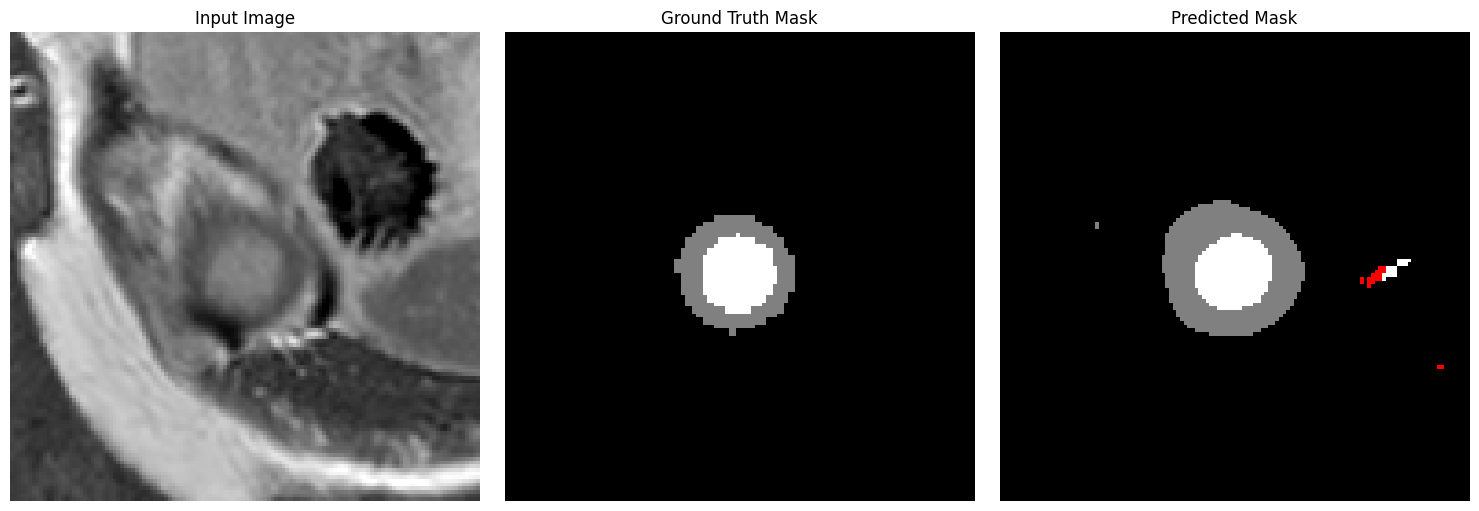

  1%|▏         | 1/80 [00:00<00:32,  2.42it/s]

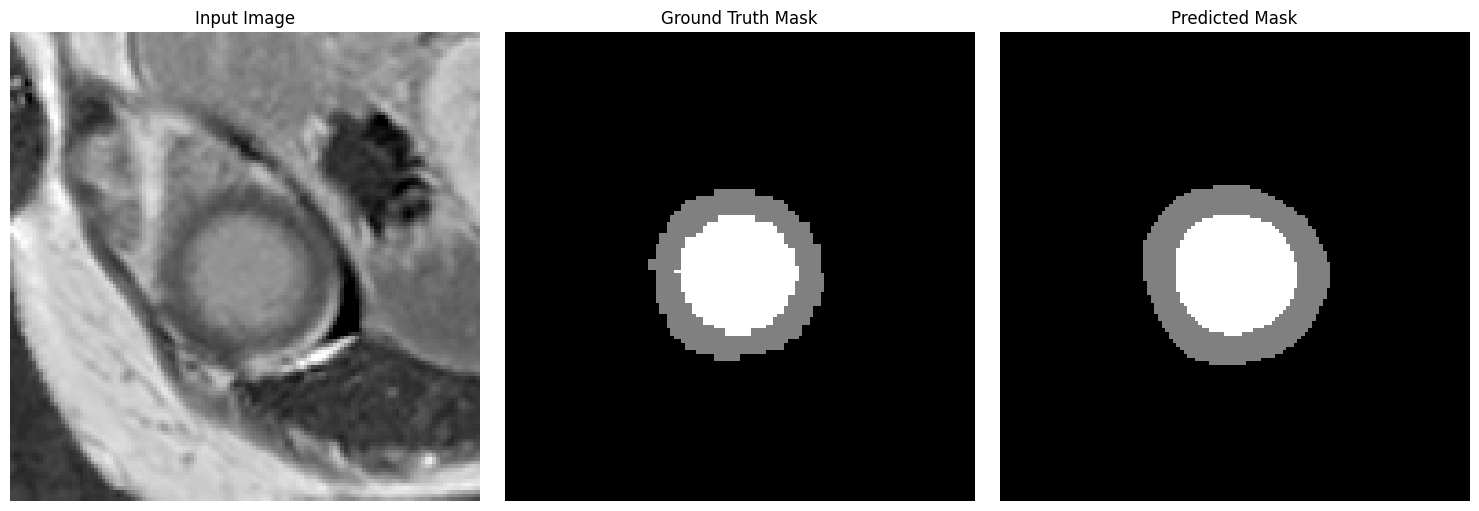

  2%|▎         | 2/80 [00:00<00:31,  2.48it/s]

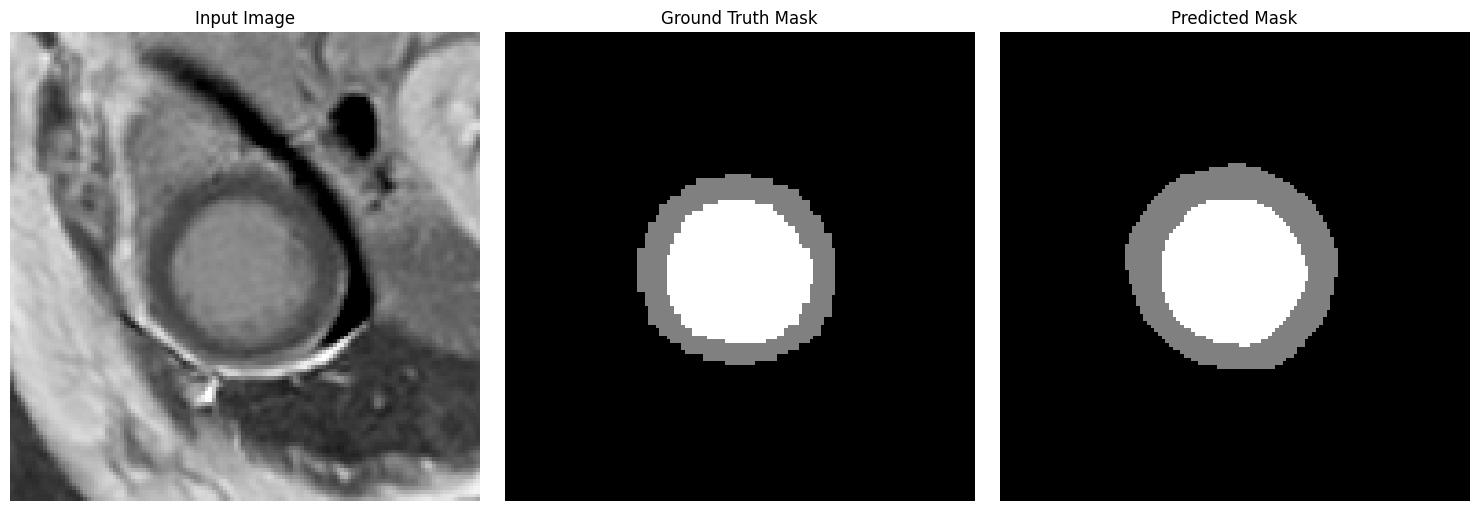

  4%|▍         | 3/80 [00:01<00:31,  2.47it/s]

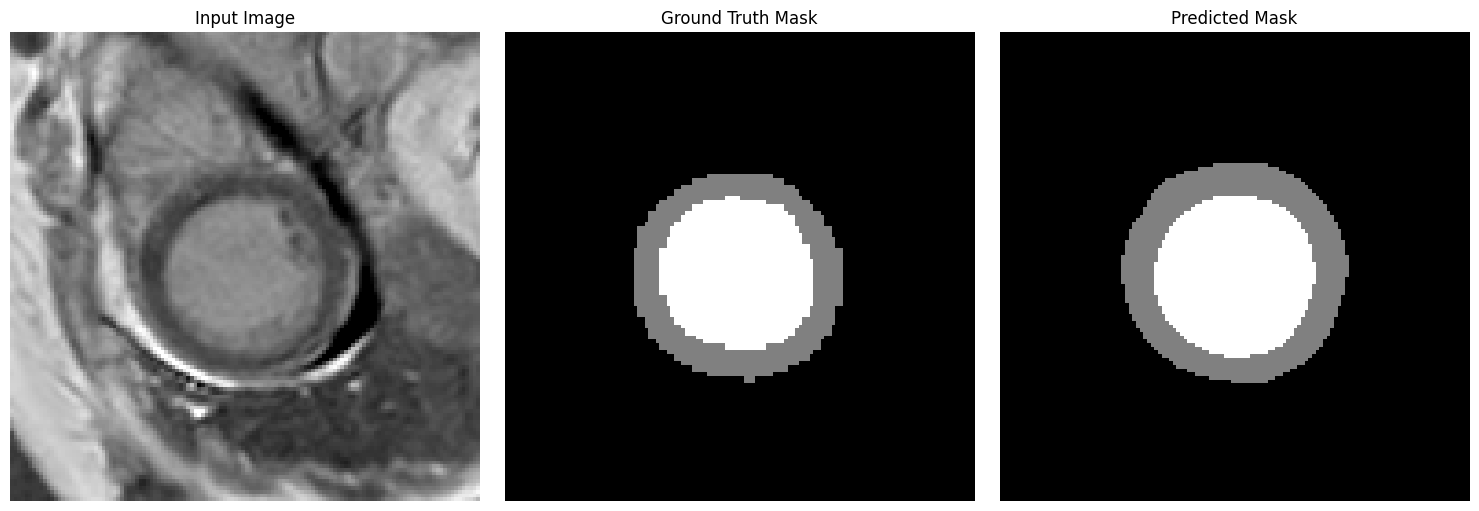

  5%|▌         | 4/80 [00:01<00:30,  2.48it/s]

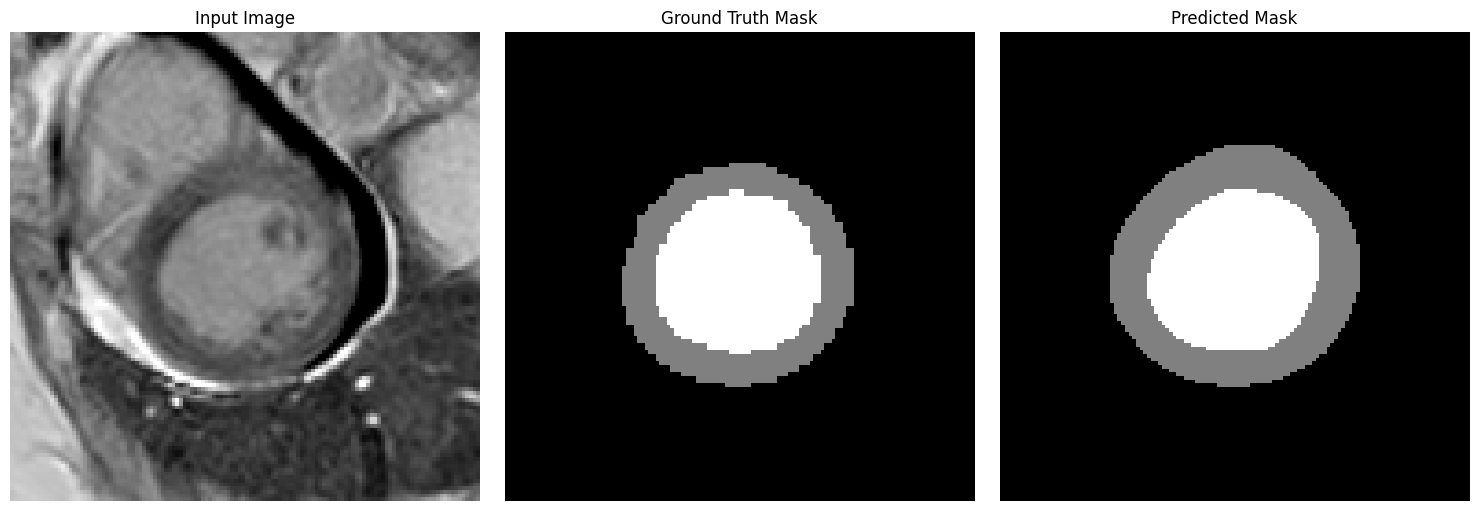

  6%|▋         | 5/80 [00:02<00:30,  2.49it/s]

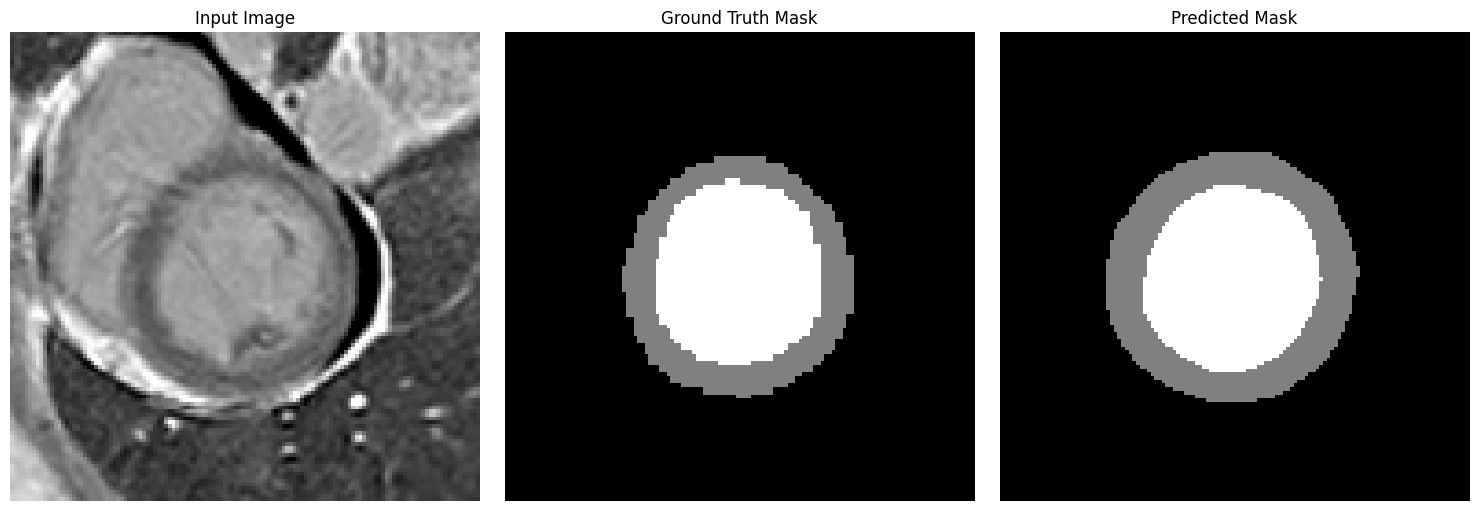

  8%|▊         | 6/80 [00:02<00:29,  2.47it/s]

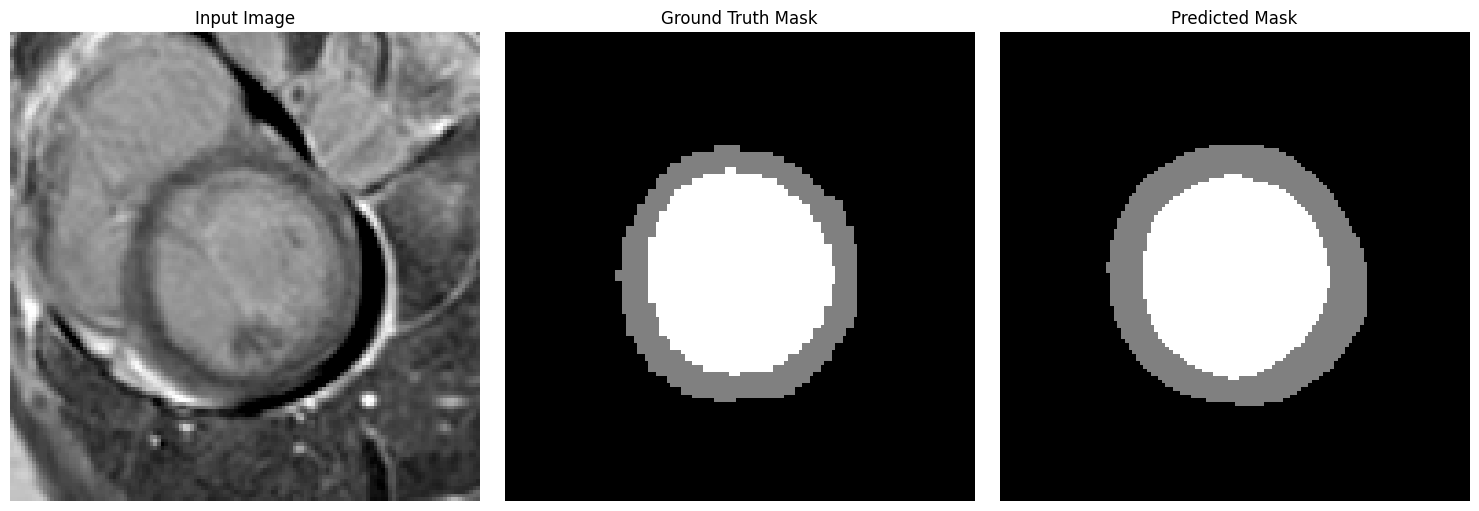

  9%|▉         | 7/80 [00:02<00:29,  2.49it/s]

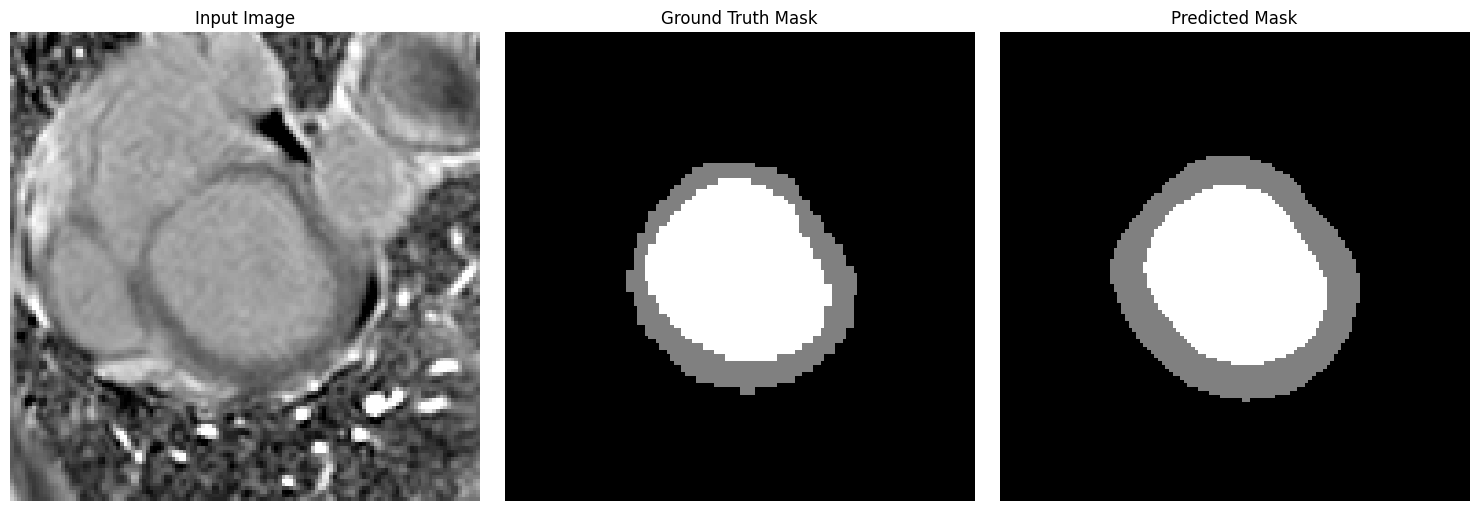

 10%|█         | 8/80 [00:03<00:29,  2.46it/s]

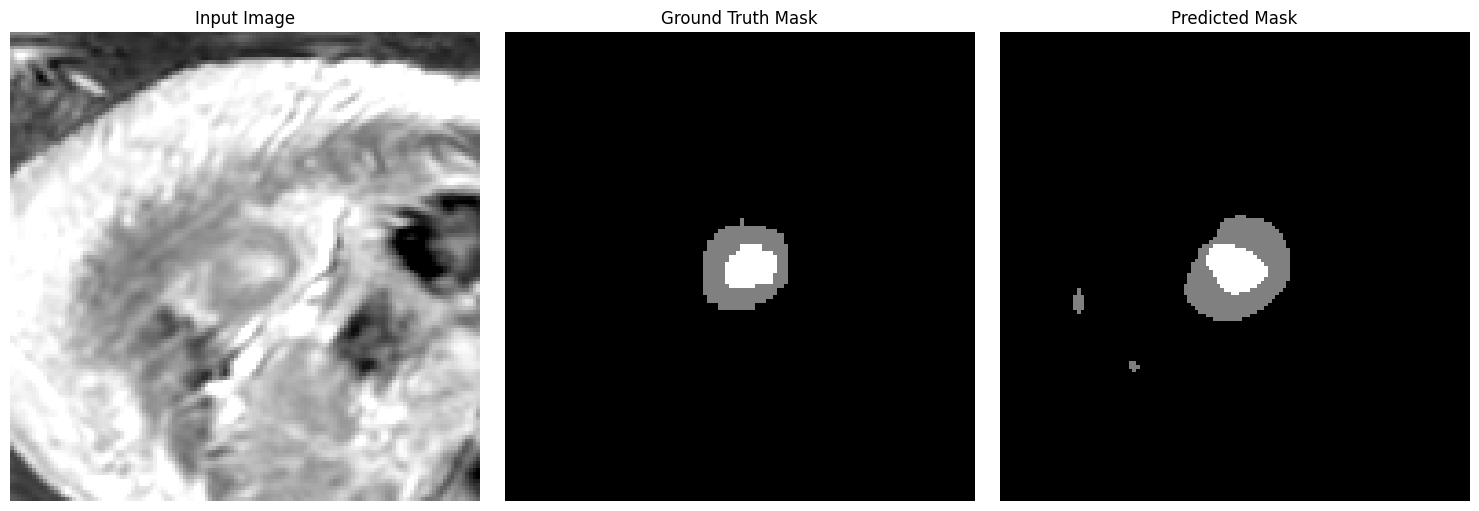

 11%|█▏        | 9/80 [00:03<00:28,  2.45it/s]

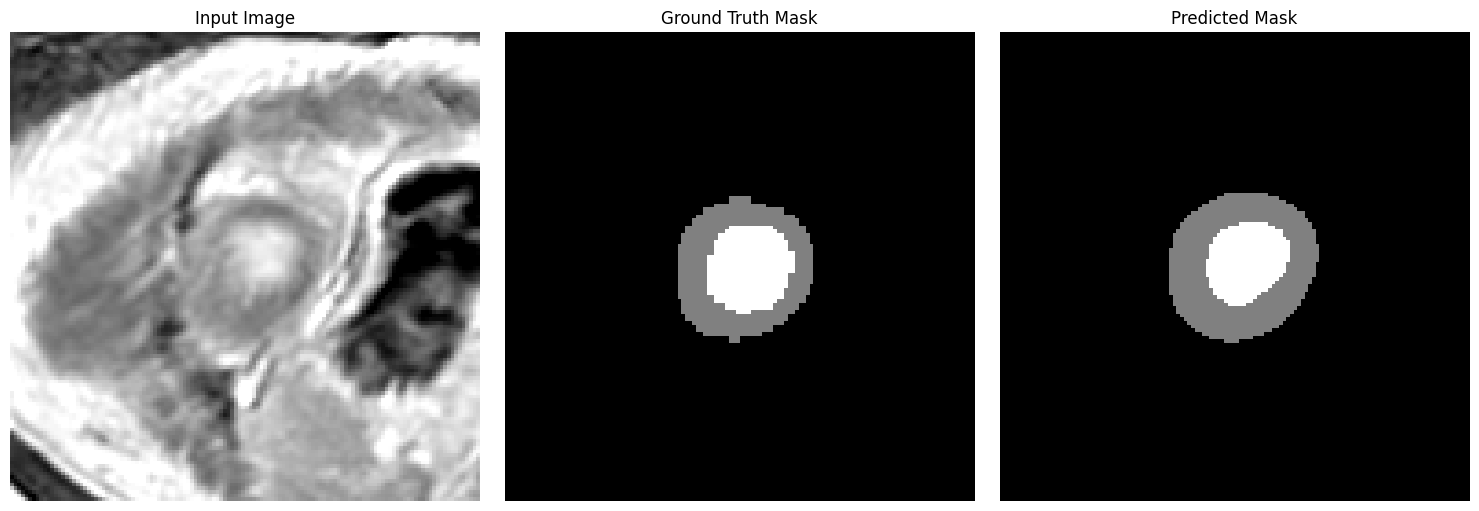

 12%|█▎        | 10/80 [00:04<00:28,  2.46it/s]

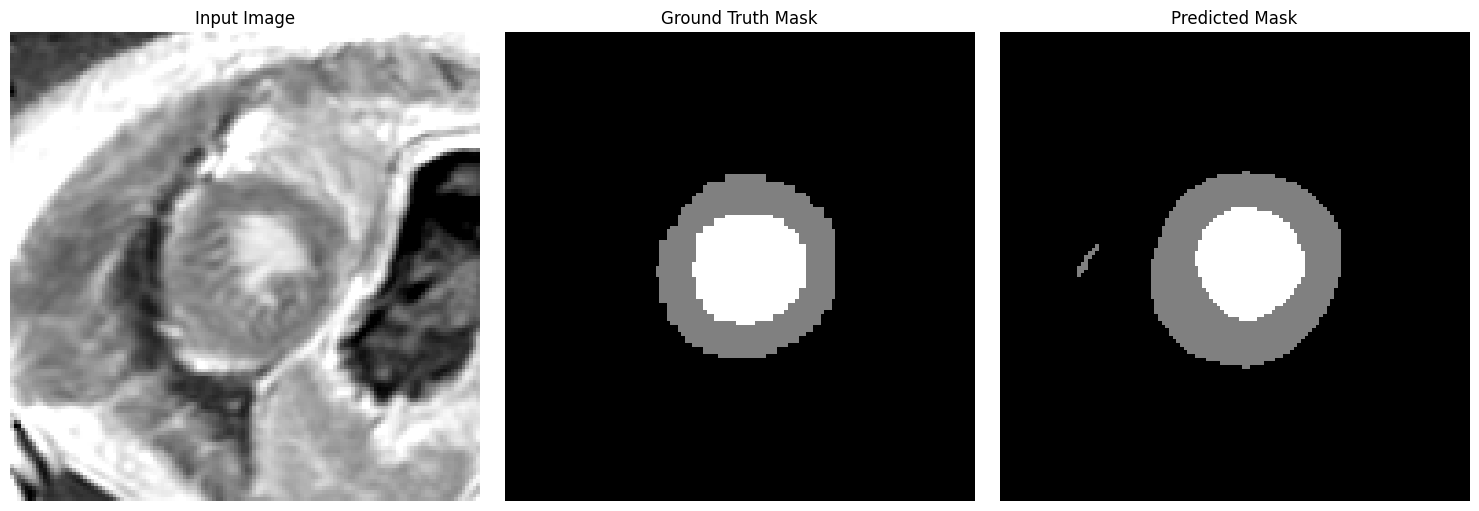

 14%|█▍        | 11/80 [00:04<00:28,  2.44it/s]

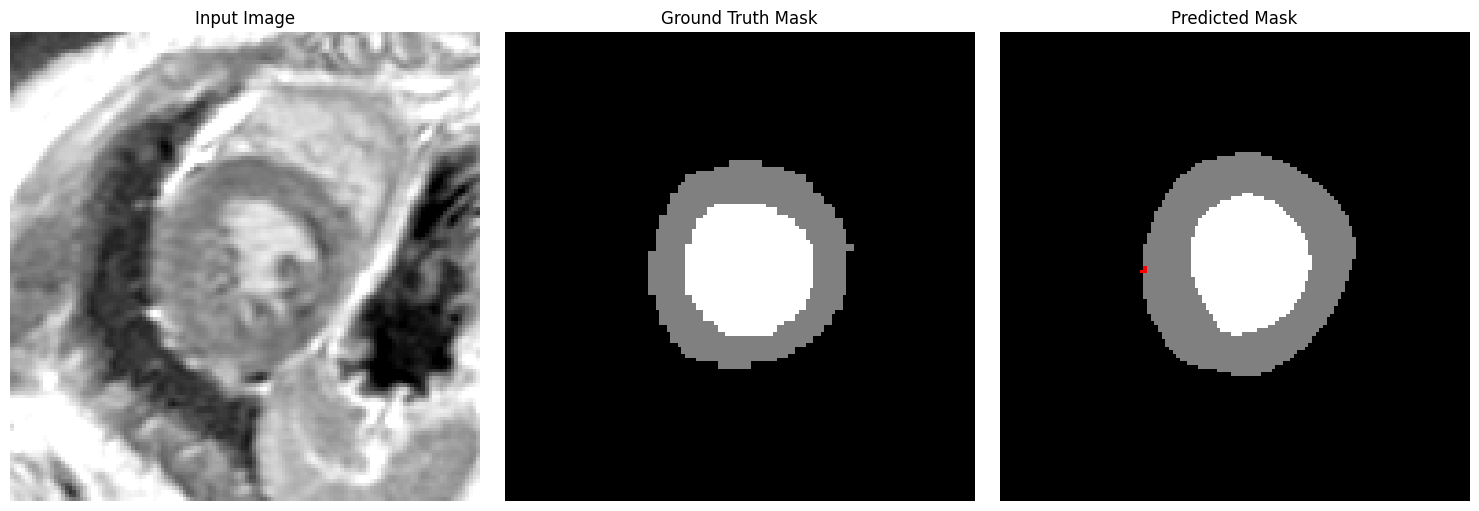

 15%|█▌        | 12/80 [00:04<00:27,  2.44it/s]

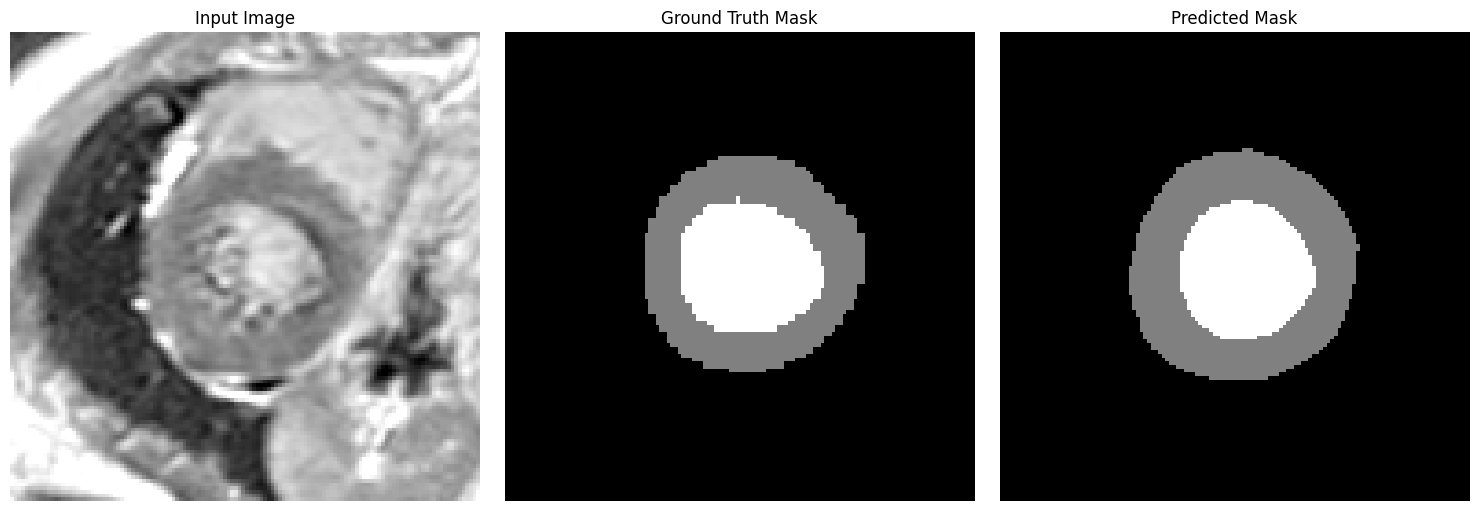

 16%|█▋        | 13/80 [00:05<00:27,  2.43it/s]

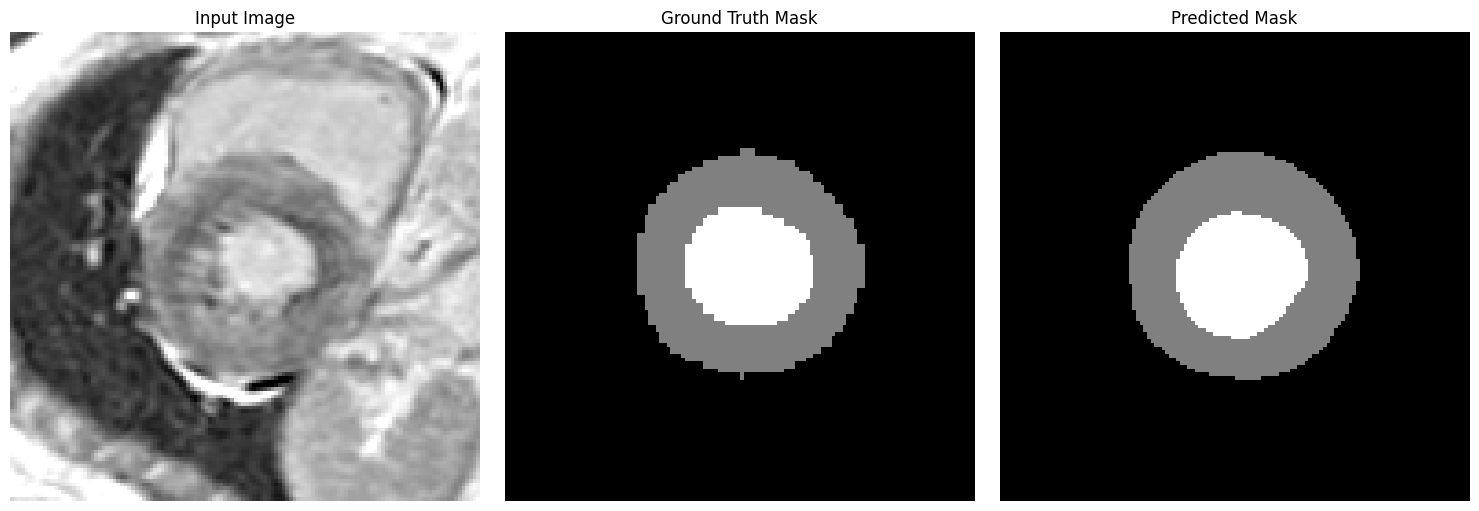

 18%|█▊        | 14/80 [00:05<00:26,  2.45it/s]

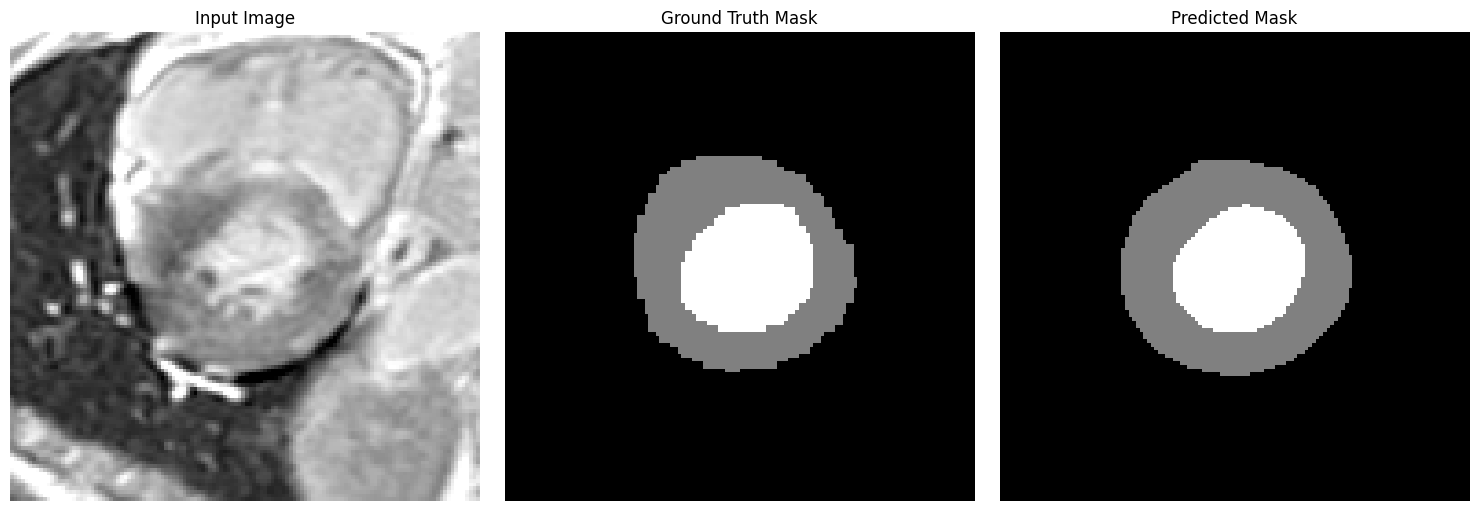

 19%|█▉        | 15/80 [00:06<00:26,  2.46it/s]

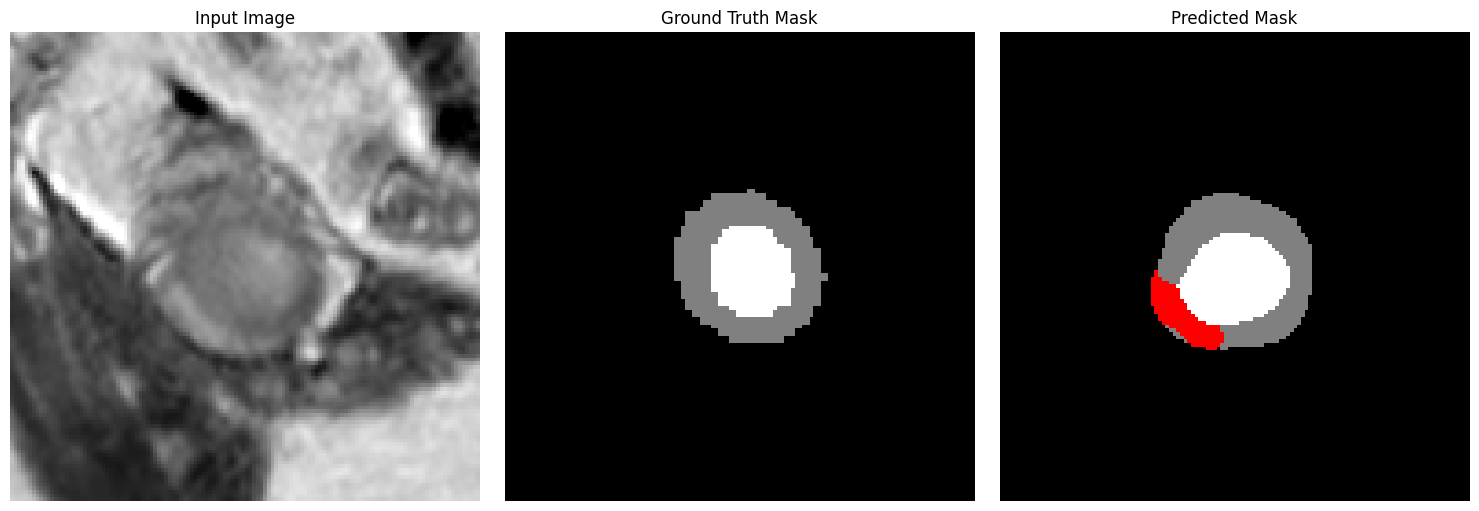

 20%|██        | 16/80 [00:06<00:26,  2.45it/s]

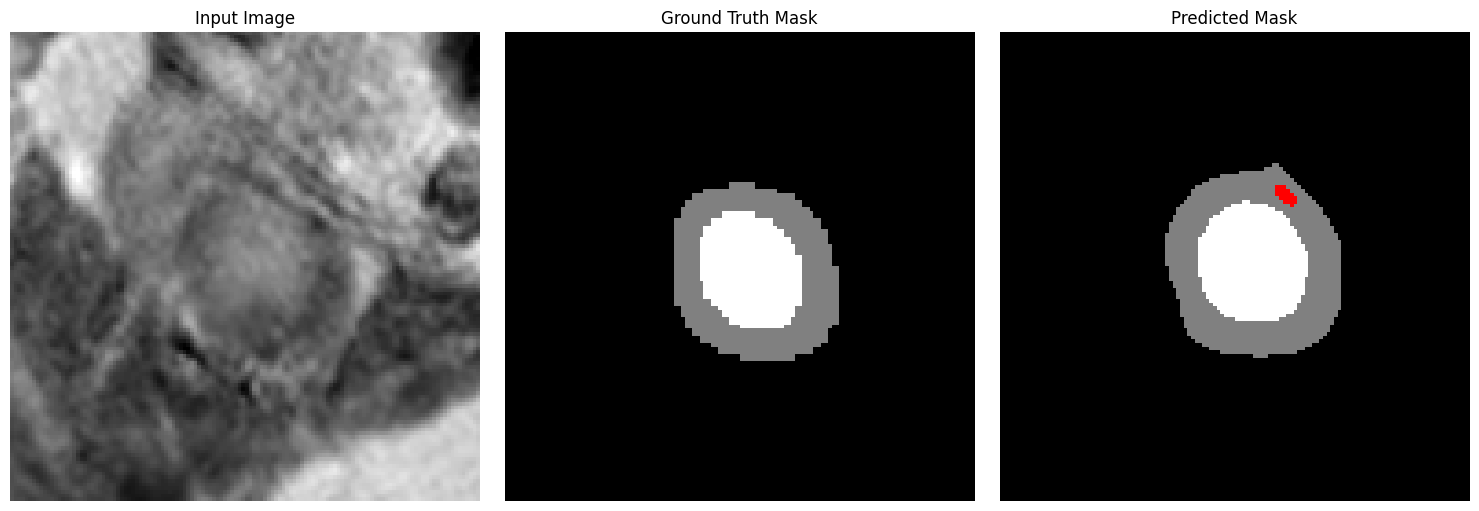

 21%|██▏       | 17/80 [00:06<00:25,  2.45it/s]

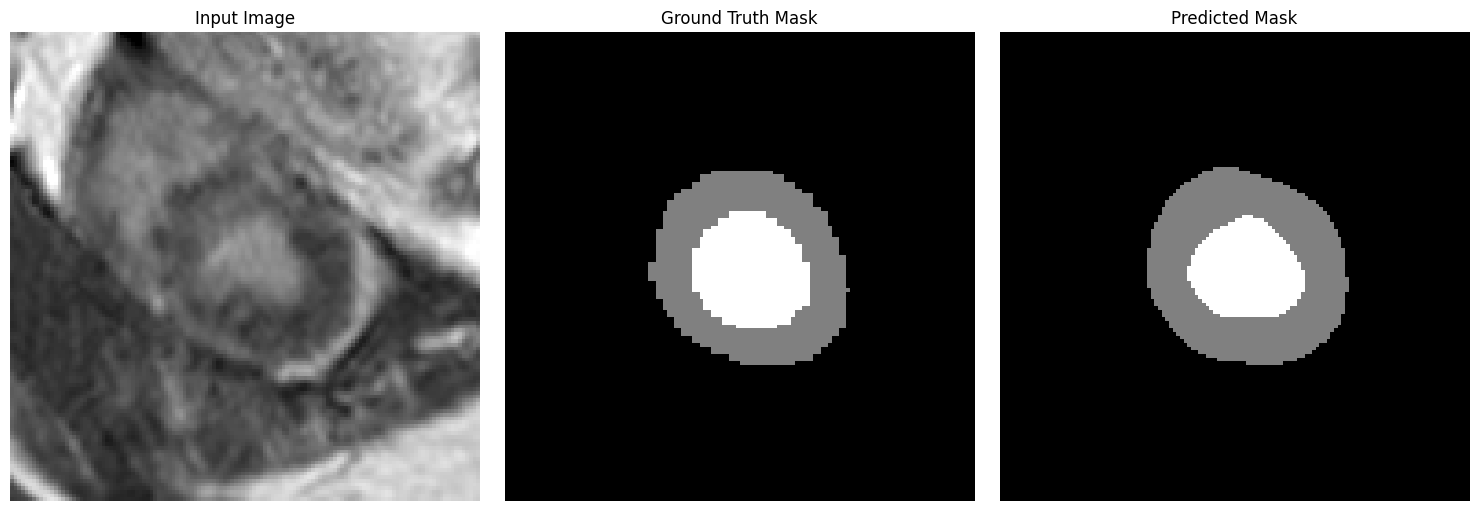

 22%|██▎       | 18/80 [00:07<00:26,  2.33it/s]

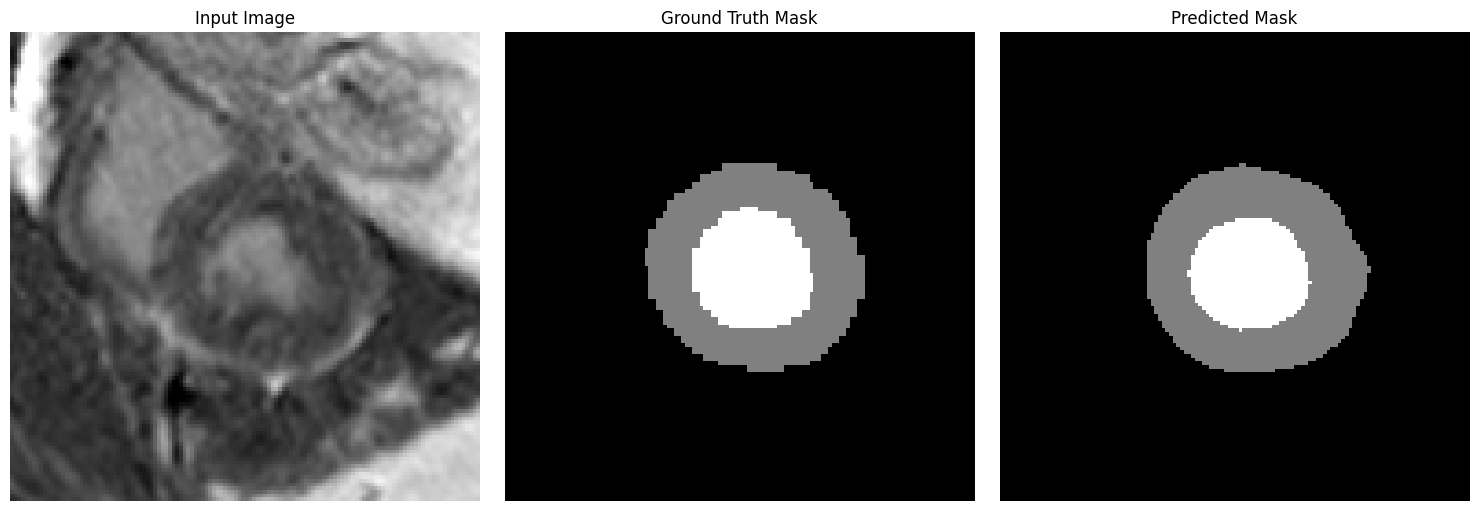

 24%|██▍       | 19/80 [00:08<00:42,  1.44it/s]

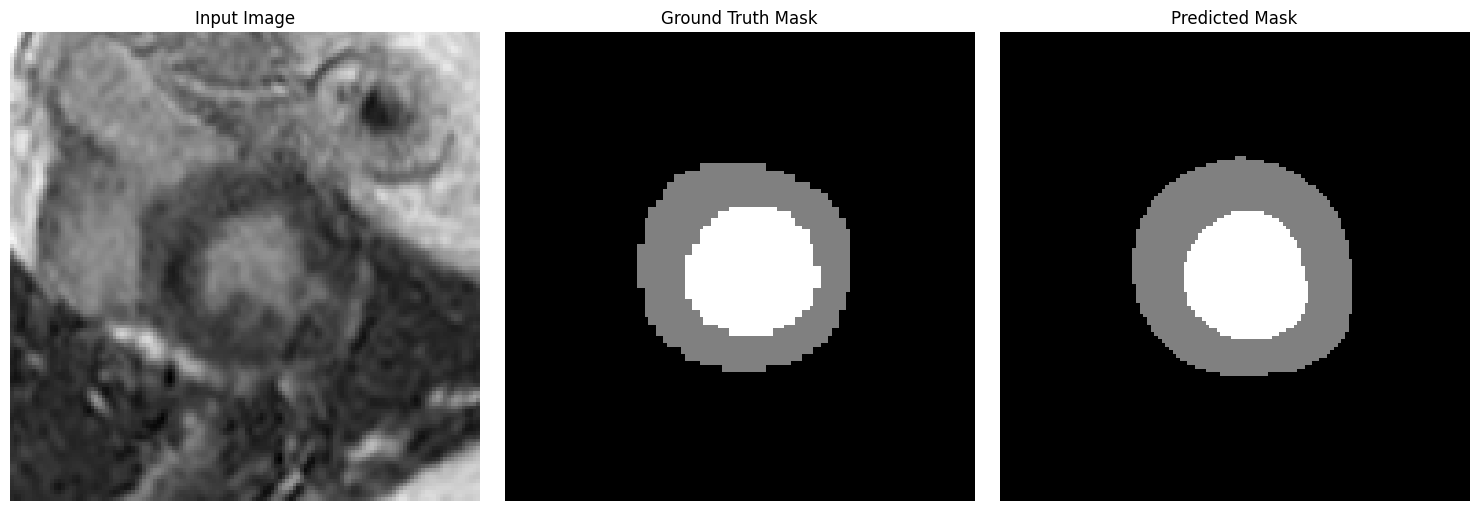

 25%|██▌       | 20/80 [00:09<00:39,  1.51it/s]

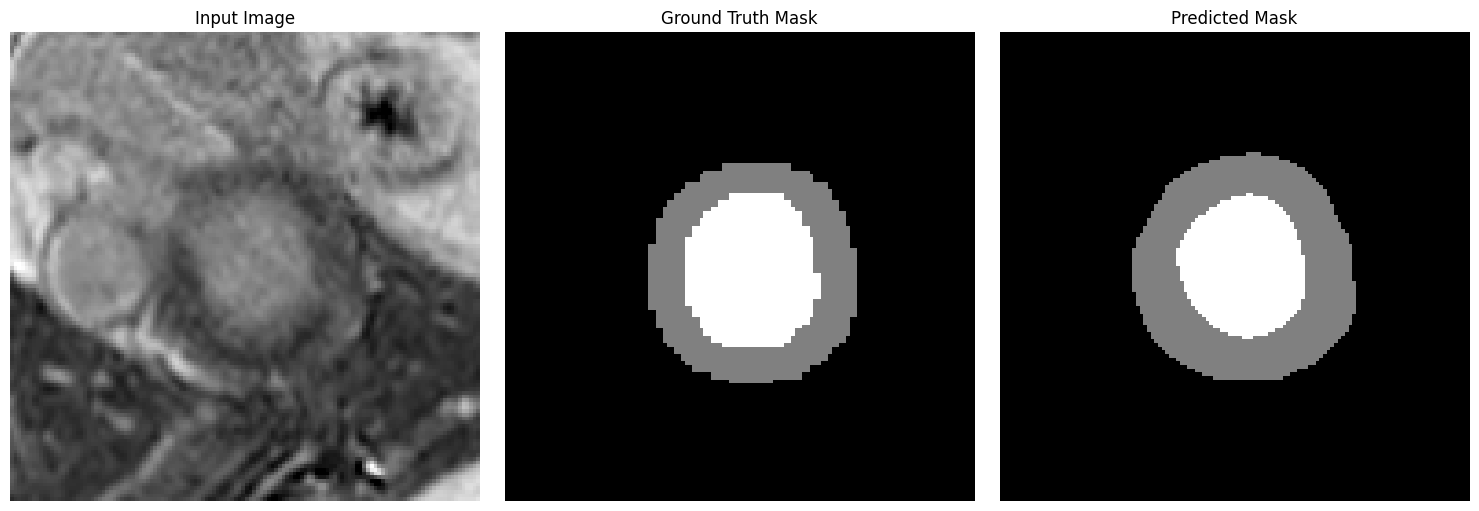

 26%|██▋       | 21/80 [00:09<00:37,  1.55it/s]

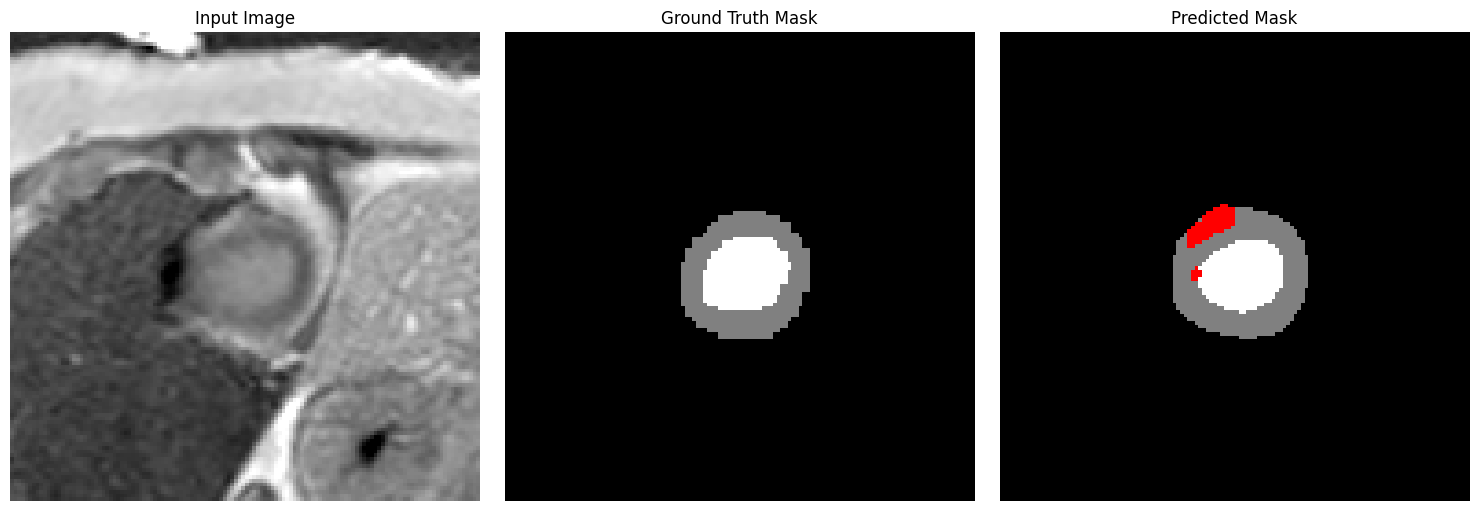

 28%|██▊       | 22/80 [00:10<00:36,  1.60it/s]

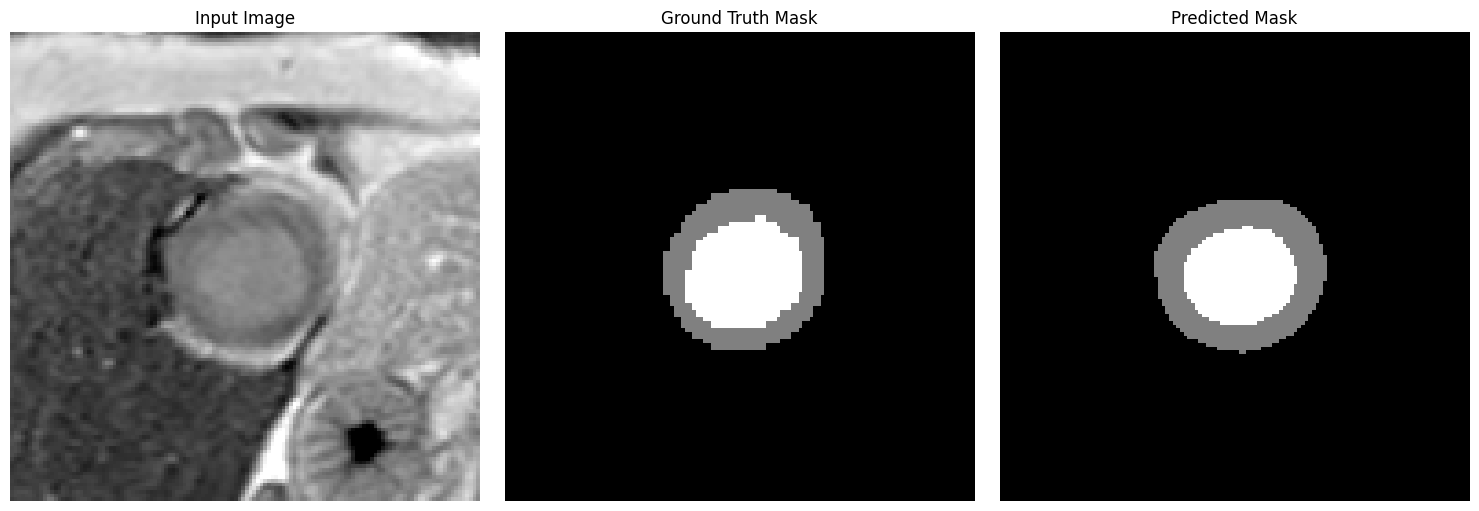

 29%|██▉       | 23/80 [00:10<00:31,  1.78it/s]

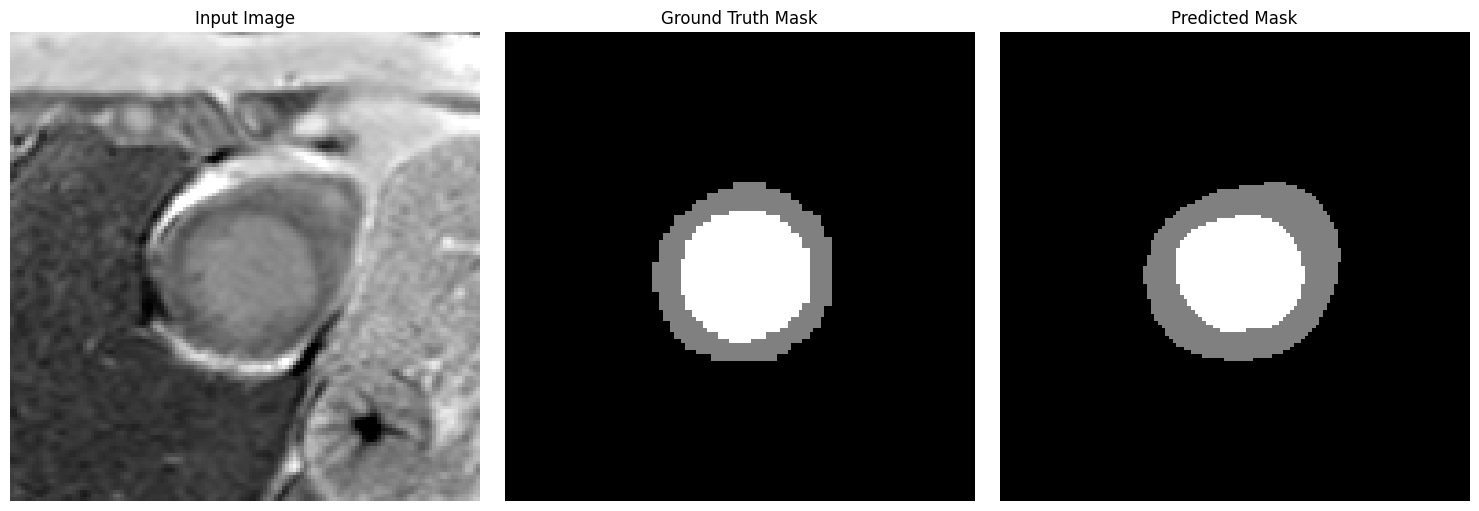

 30%|███       | 24/80 [00:11<00:28,  1.94it/s]

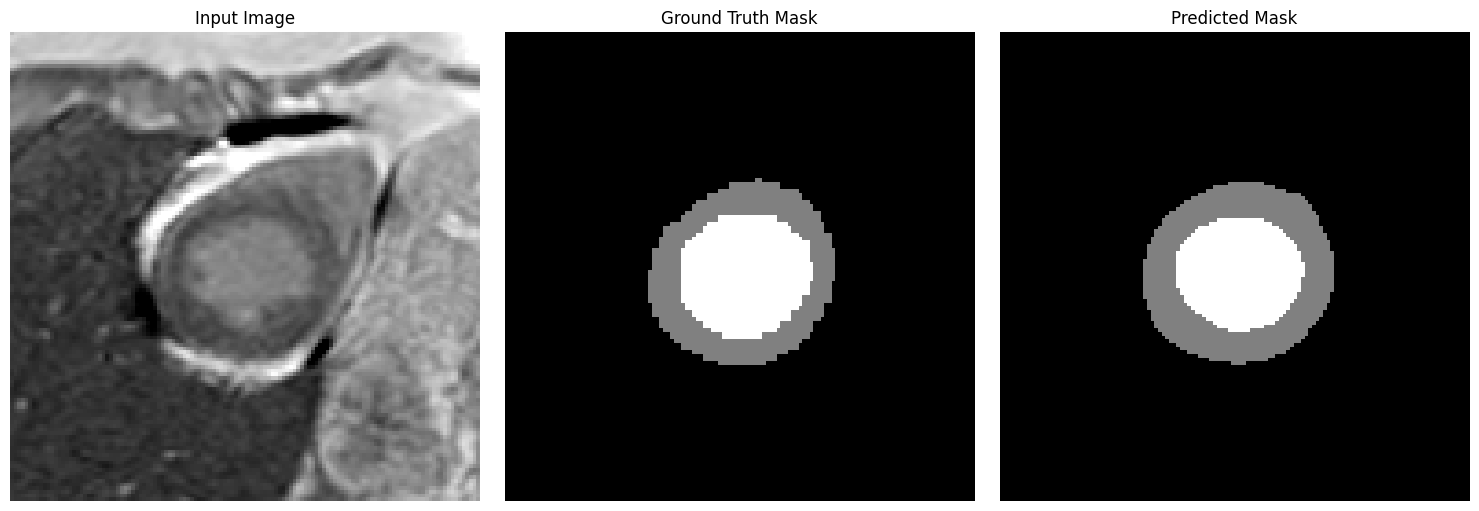

 31%|███▏      | 25/80 [00:11<00:27,  2.03it/s]

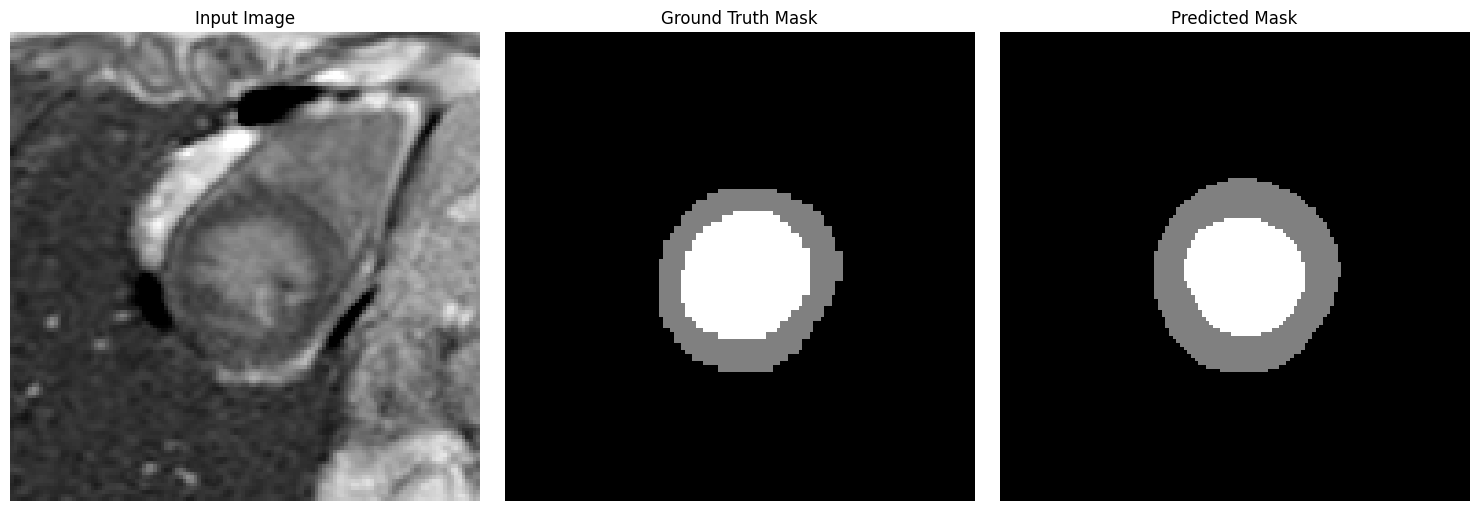

 32%|███▎      | 26/80 [00:12<00:25,  2.13it/s]

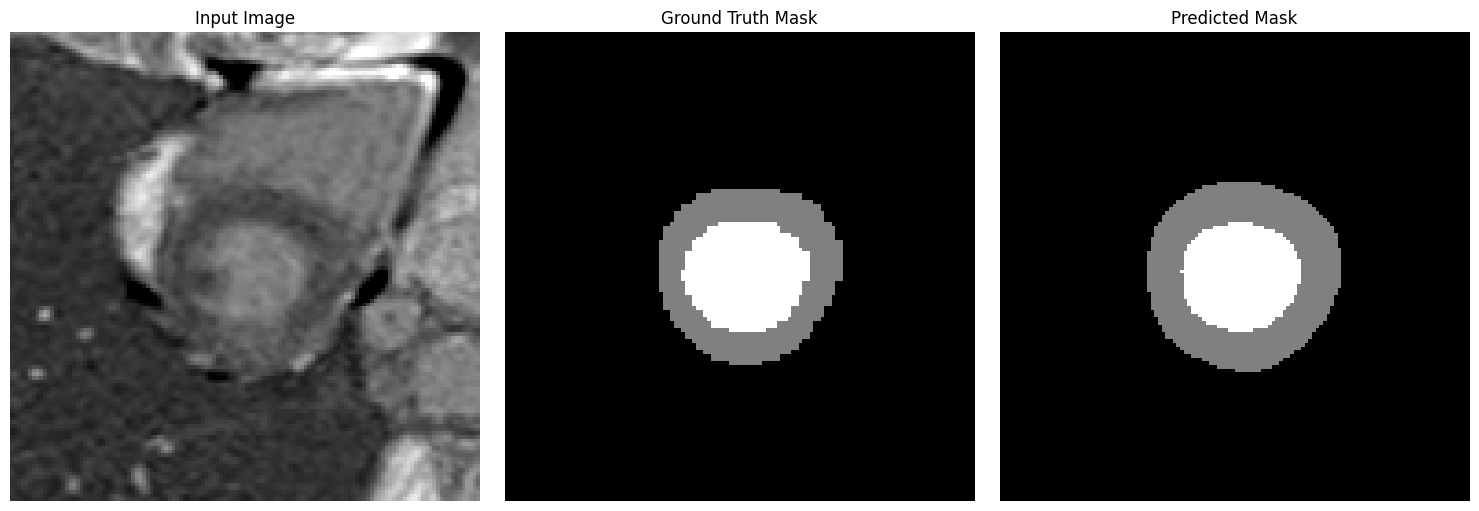

 34%|███▍      | 27/80 [00:12<00:24,  2.21it/s]

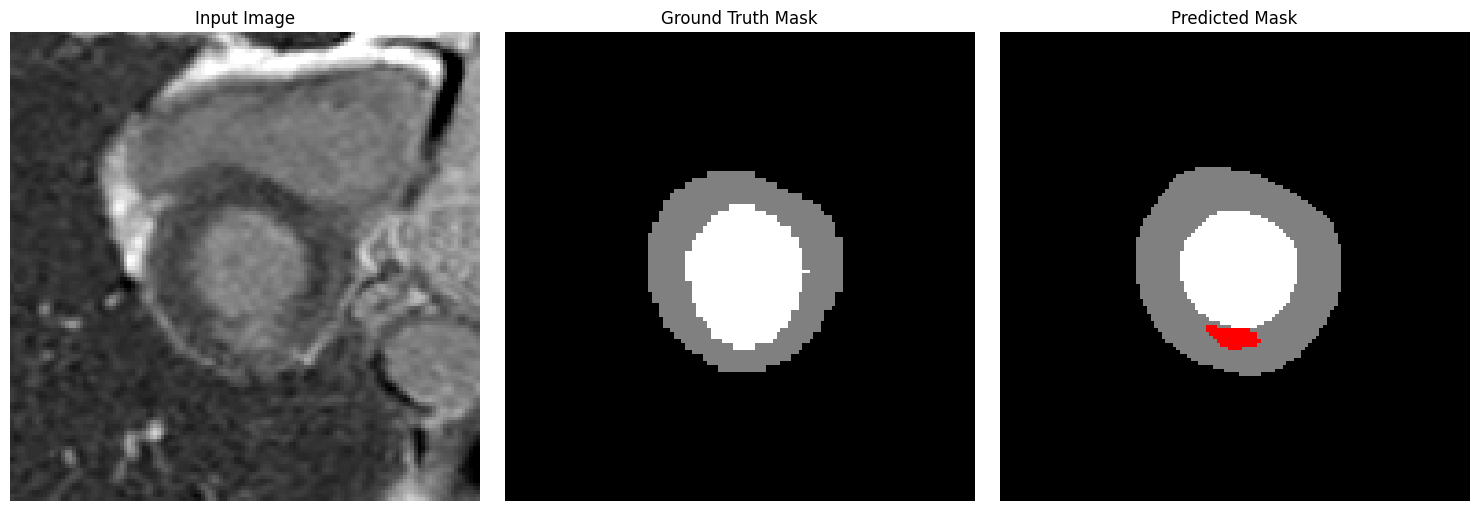

 35%|███▌      | 28/80 [00:12<00:23,  2.26it/s]

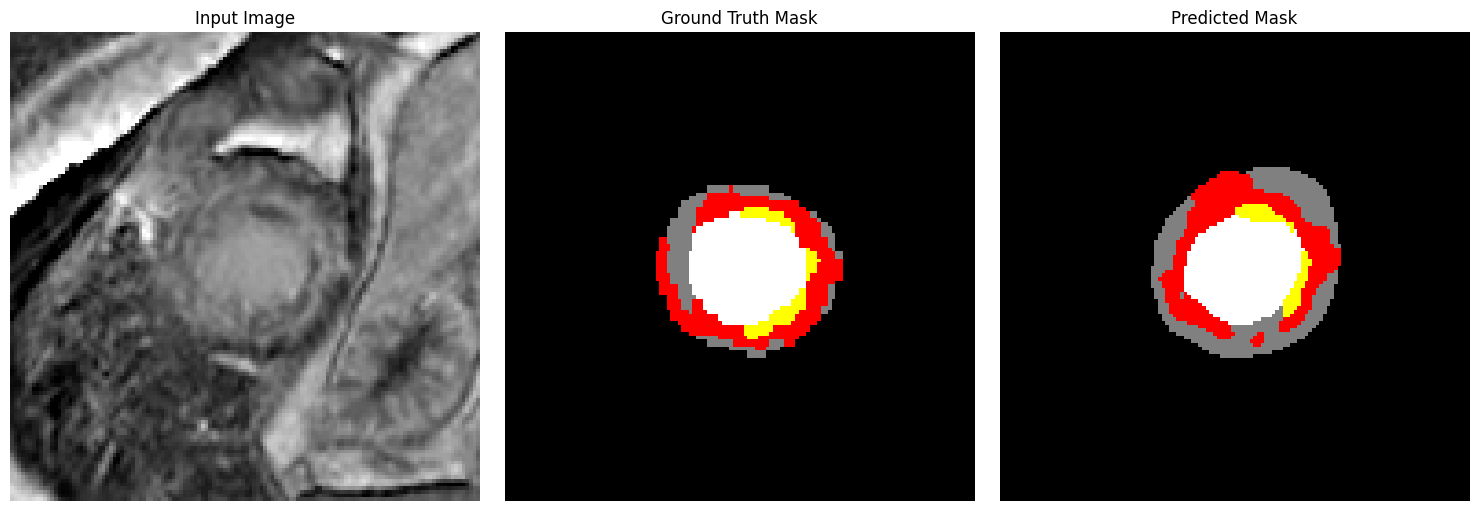

 36%|███▋      | 29/80 [00:13<00:21,  2.32it/s]

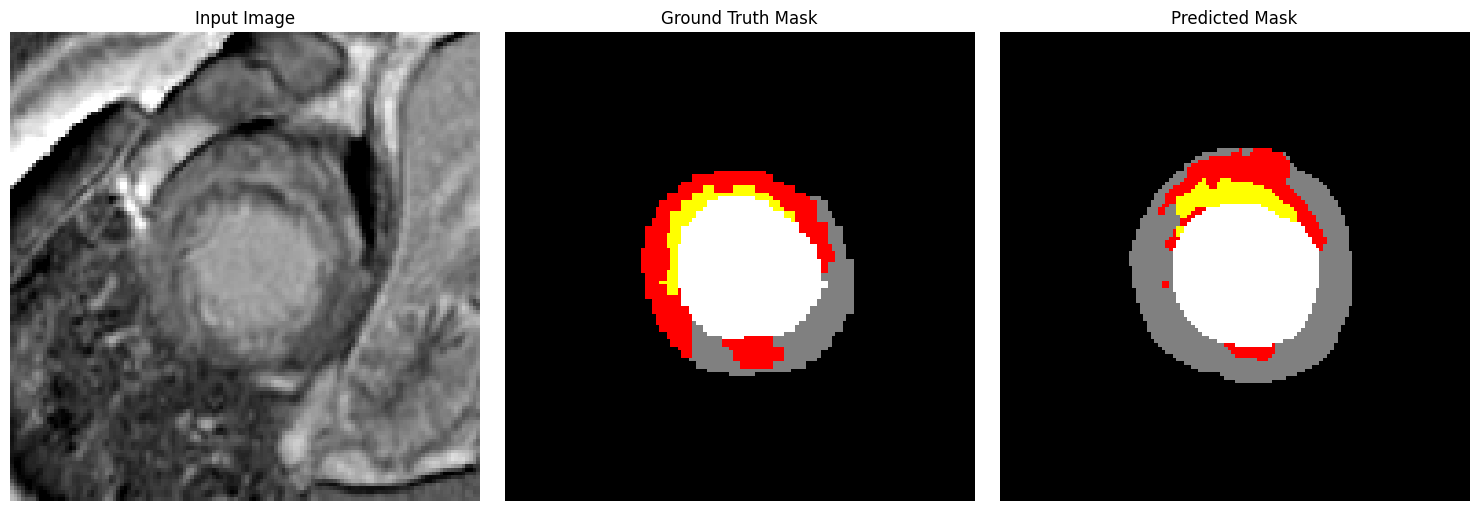

 38%|███▊      | 30/80 [00:13<00:21,  2.28it/s]

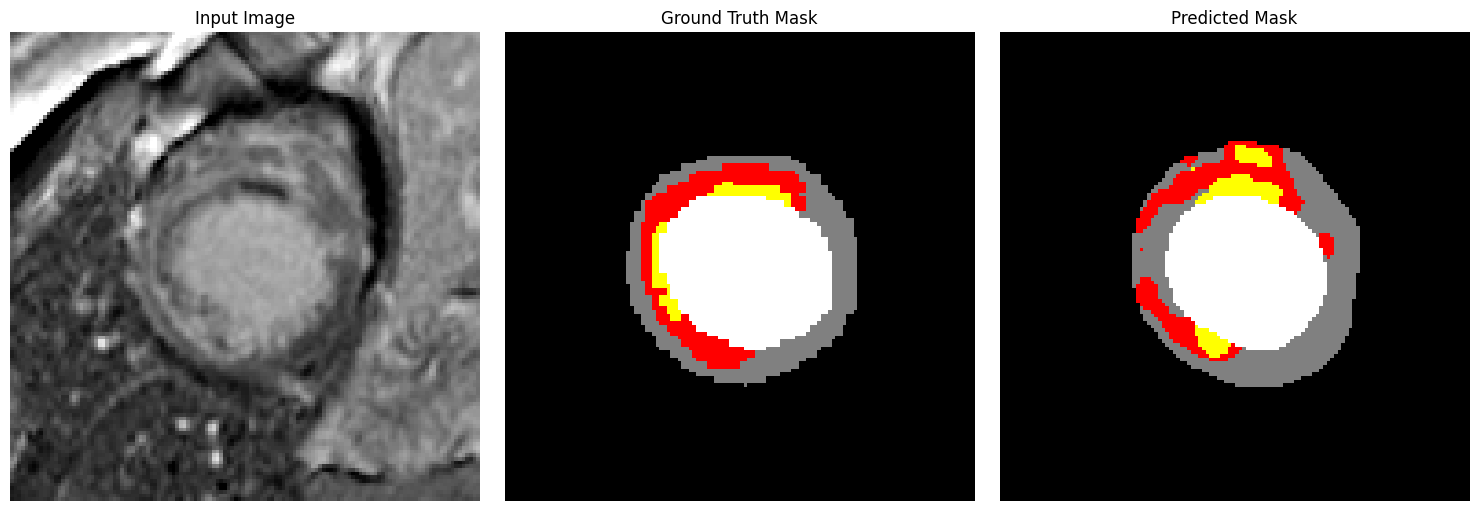

 39%|███▉      | 31/80 [00:14<00:21,  2.31it/s]

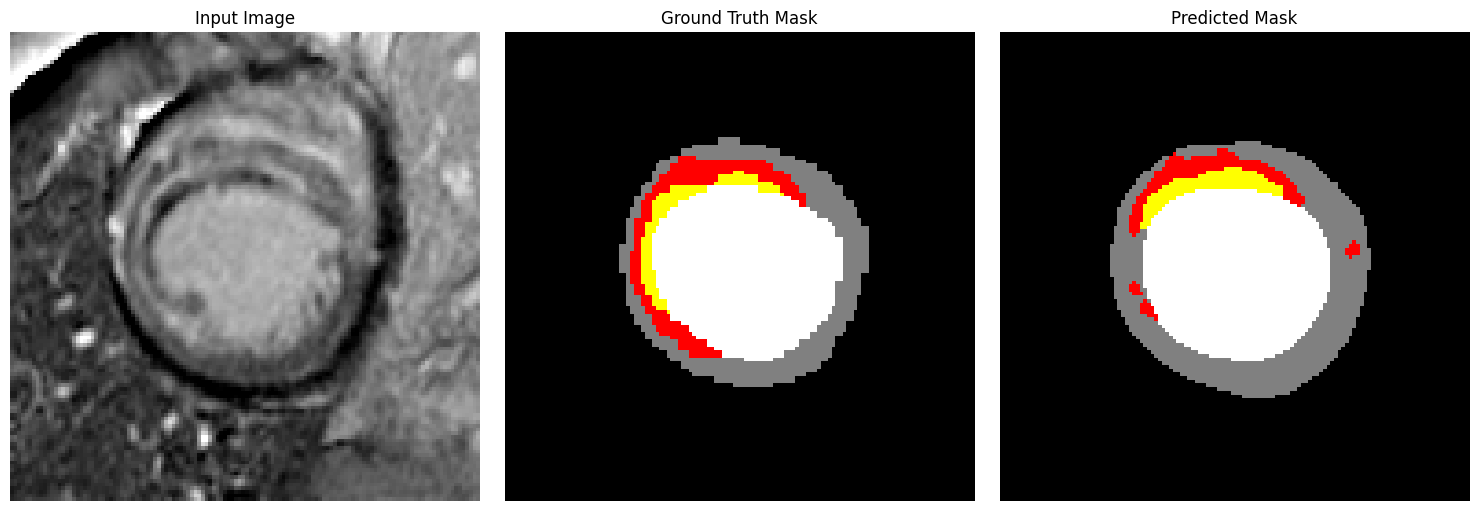

 40%|████      | 32/80 [00:14<00:20,  2.32it/s]

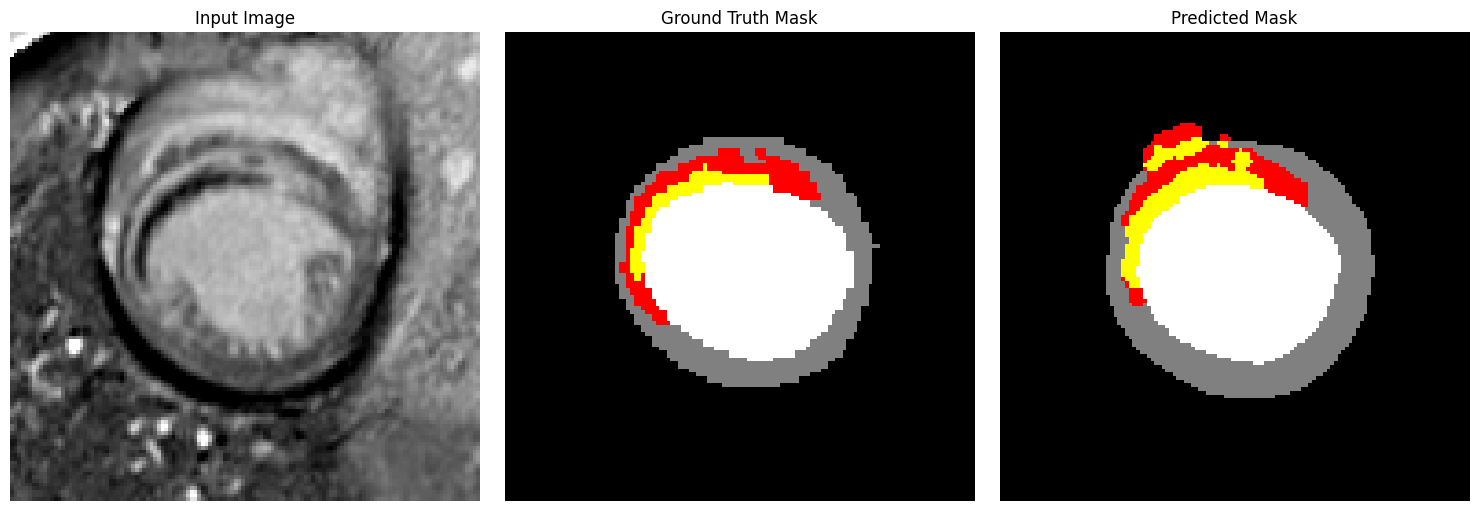

 41%|████▏     | 33/80 [00:15<00:20,  2.33it/s]

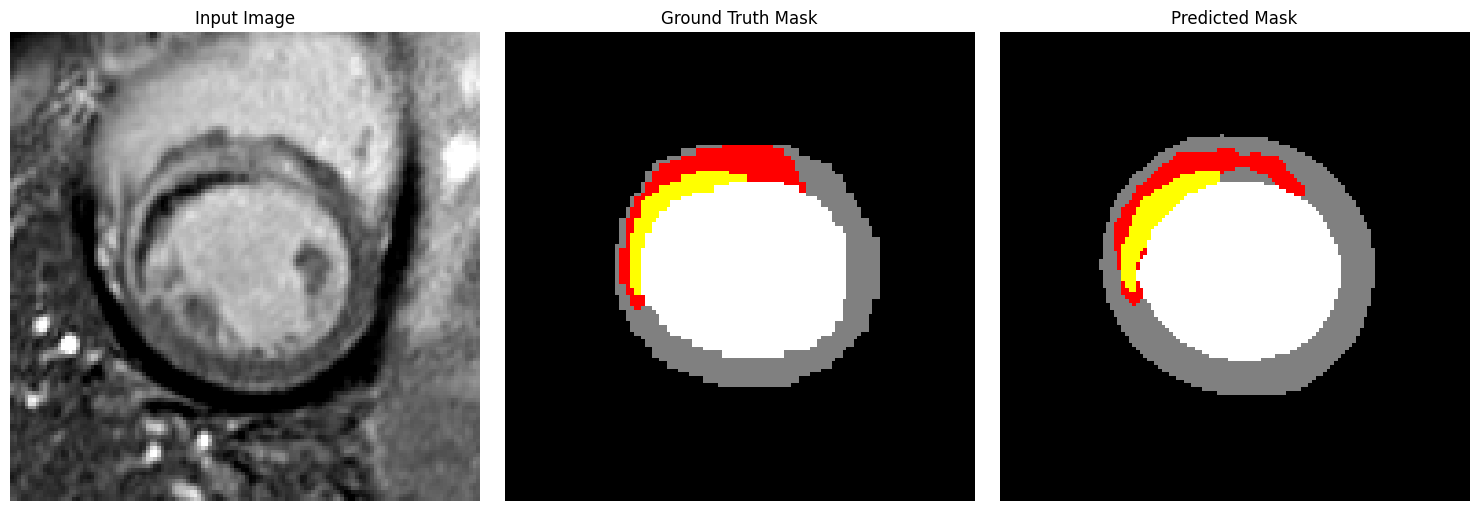

 42%|████▎     | 34/80 [00:15<00:19,  2.37it/s]

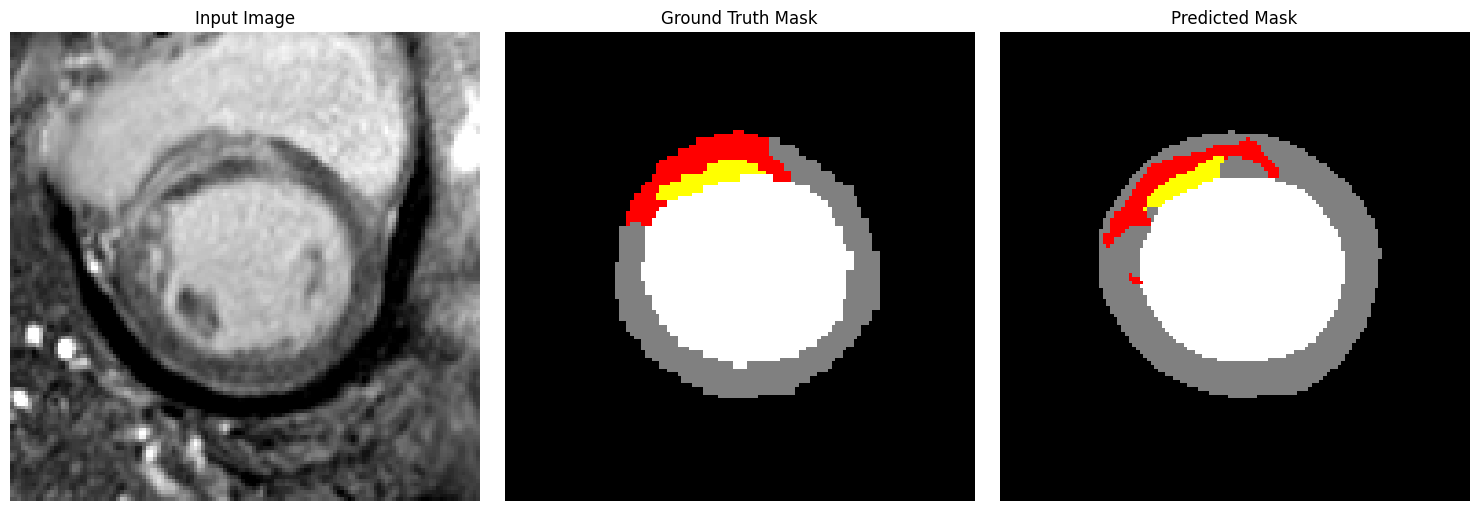

 44%|████▍     | 35/80 [00:15<00:19,  2.36it/s]

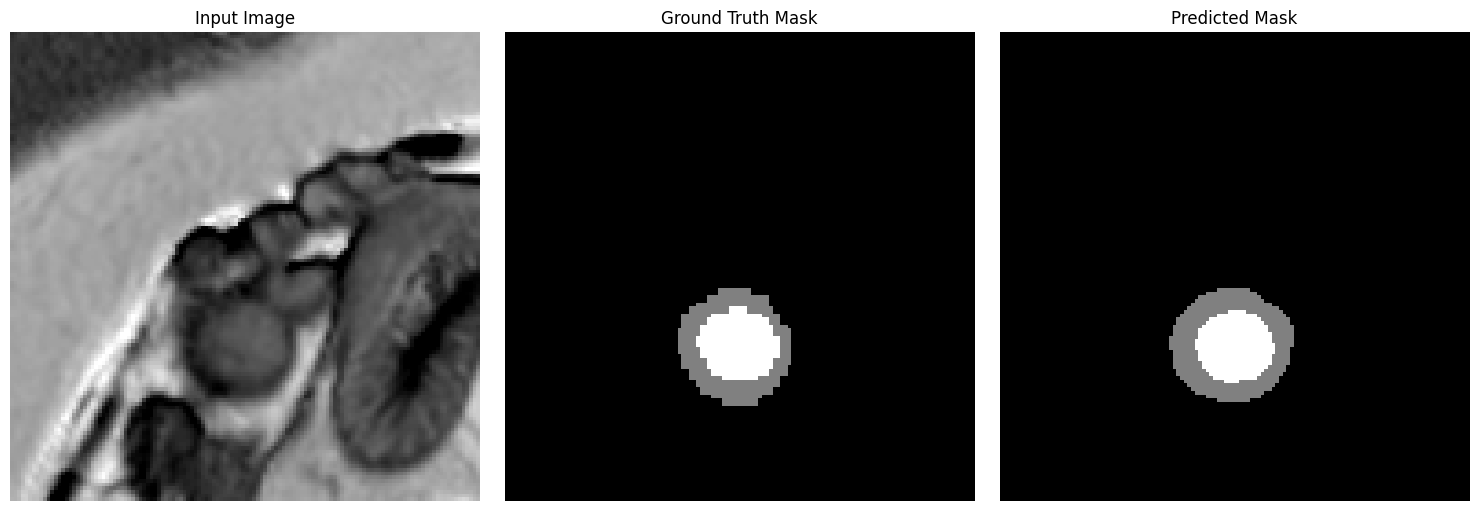

 45%|████▌     | 36/80 [00:16<00:18,  2.38it/s]

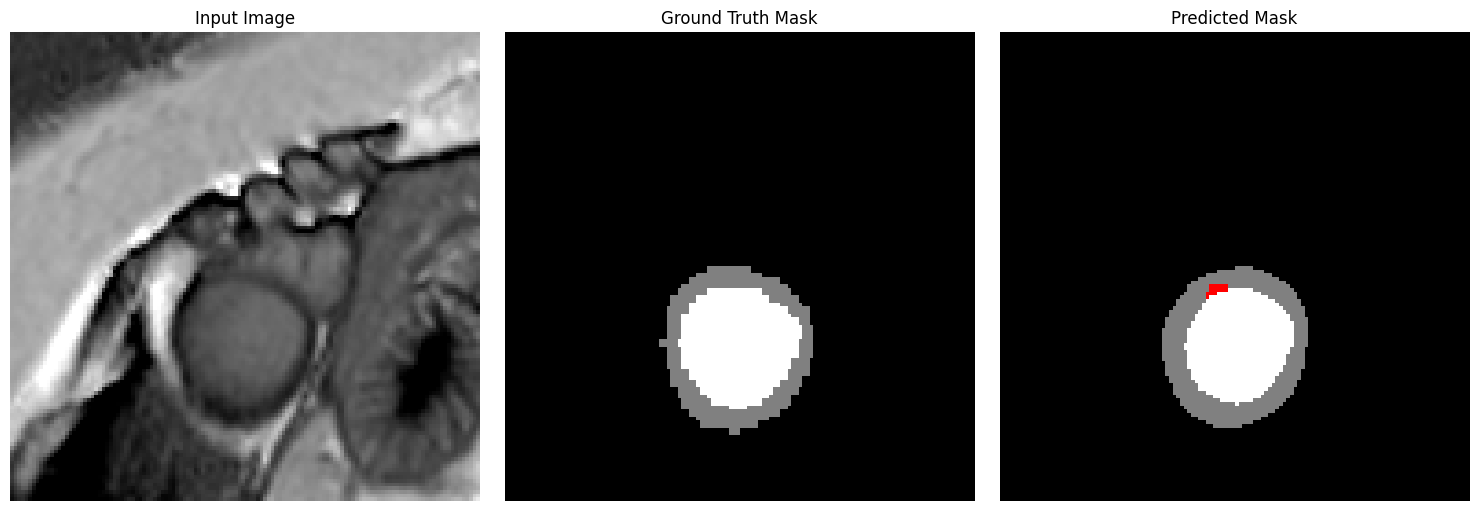

 46%|████▋     | 37/80 [00:16<00:18,  2.37it/s]

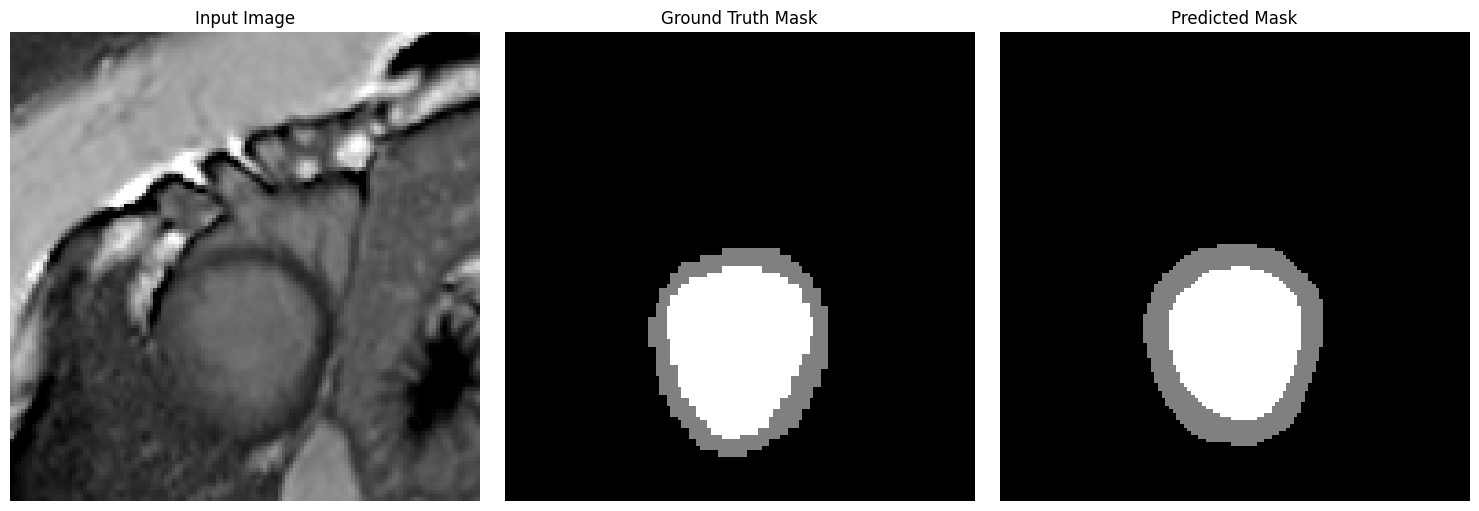

 48%|████▊     | 38/80 [00:17<00:17,  2.37it/s]

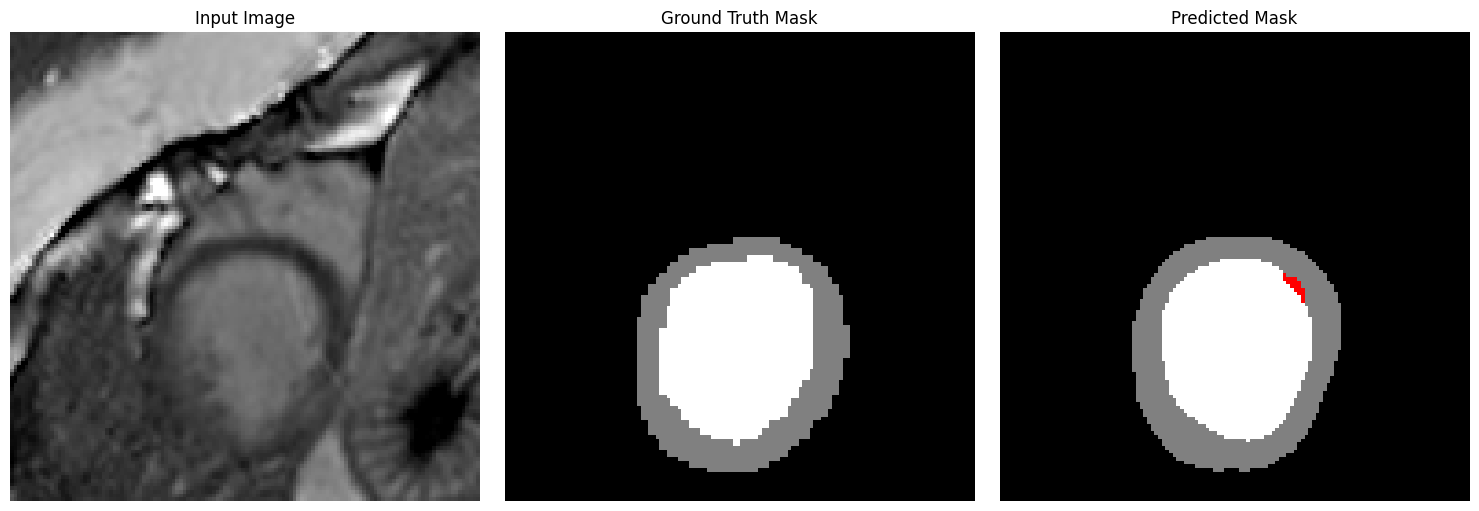

 49%|████▉     | 39/80 [00:17<00:17,  2.38it/s]

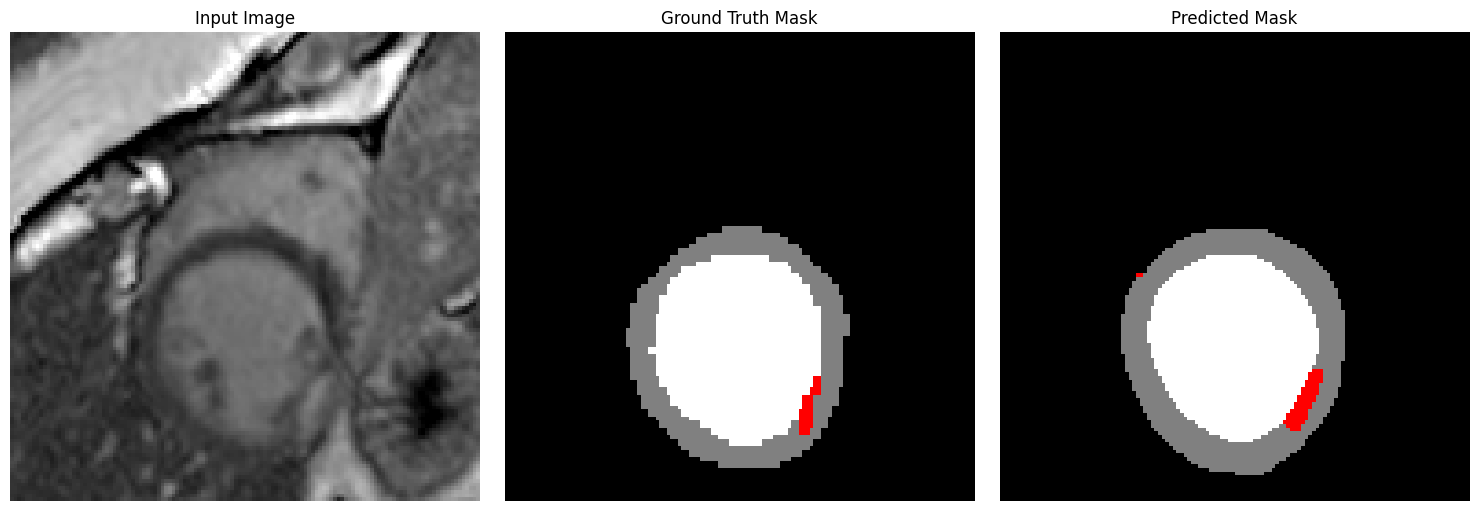

 50%|█████     | 40/80 [00:18<00:17,  2.35it/s]

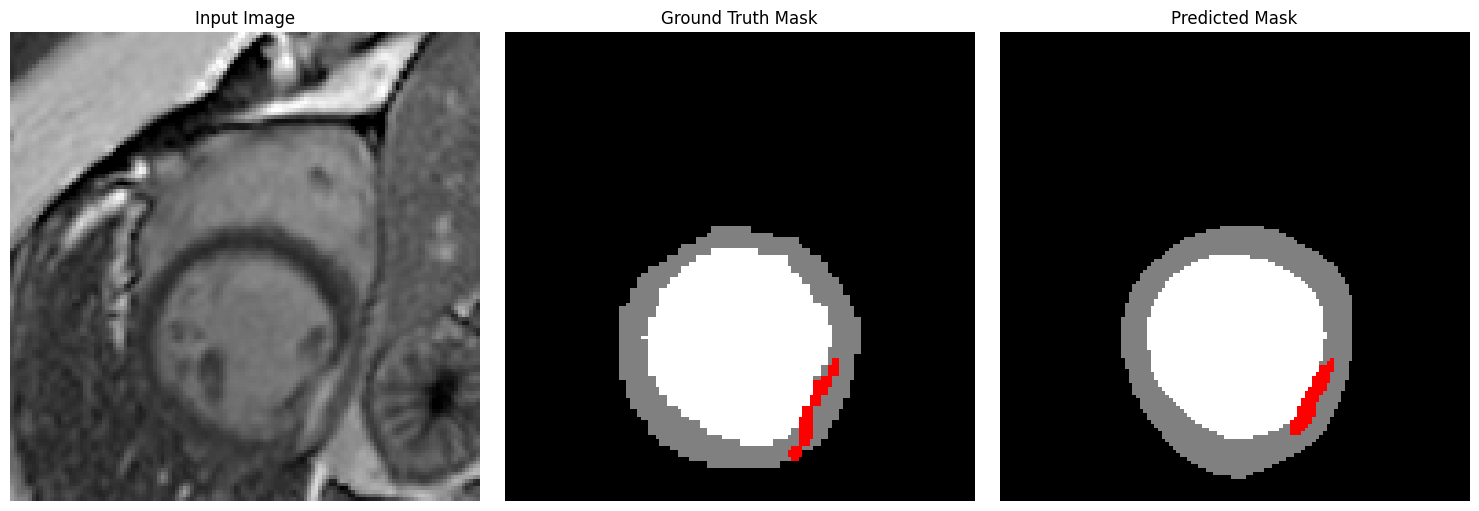

 51%|█████▏    | 41/80 [00:18<00:16,  2.37it/s]

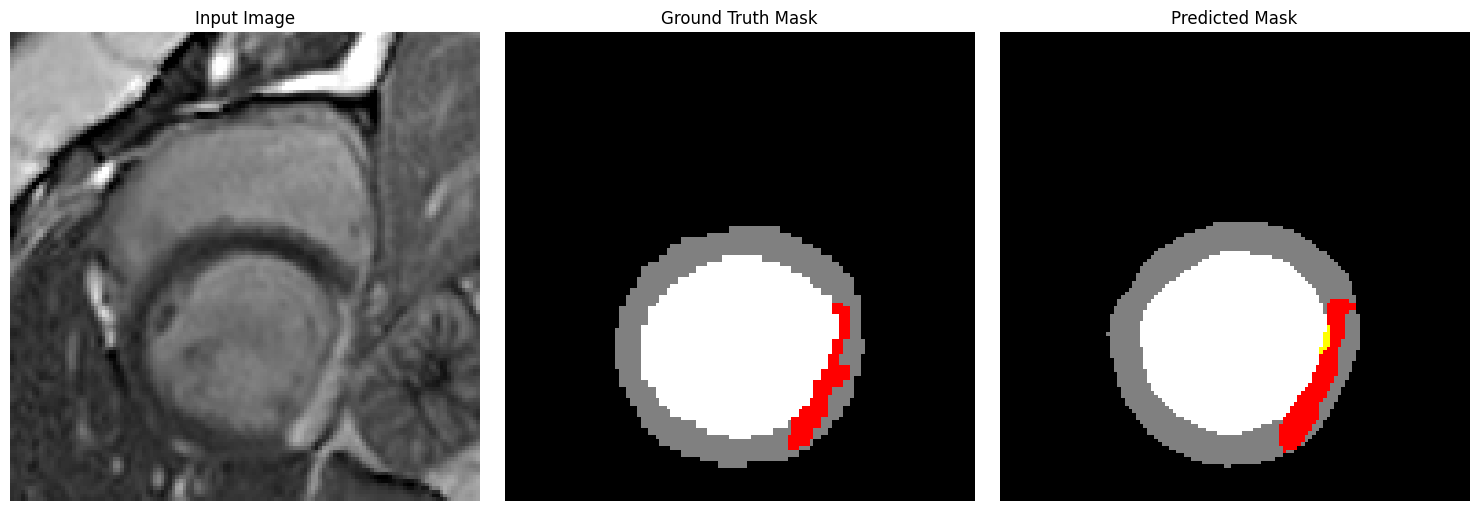

 52%|█████▎    | 42/80 [00:18<00:16,  2.36it/s]

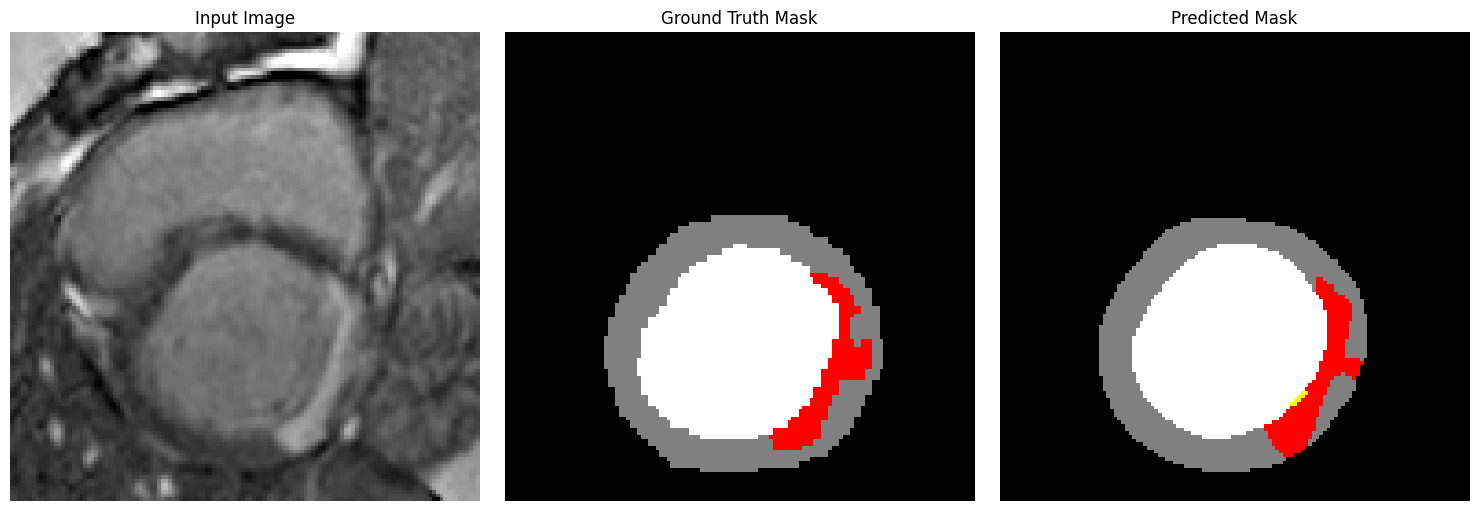

 54%|█████▍    | 43/80 [00:19<00:15,  2.39it/s]

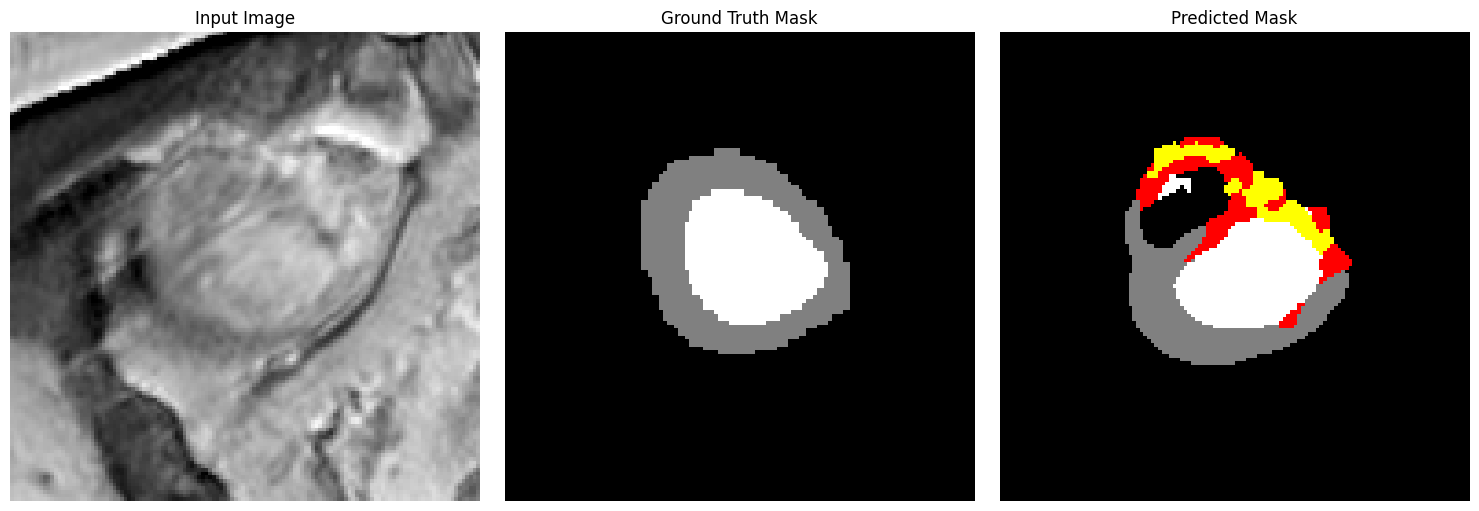

 55%|█████▌    | 44/80 [00:19<00:15,  2.40it/s]

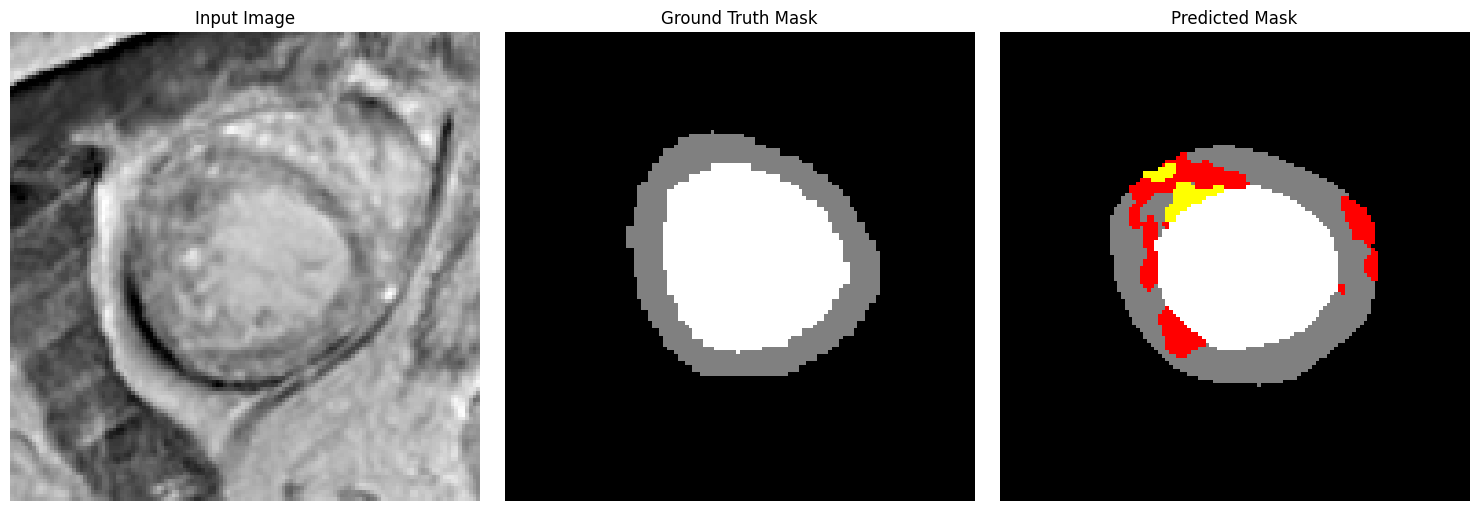

 56%|█████▋    | 45/80 [00:20<00:14,  2.36it/s]

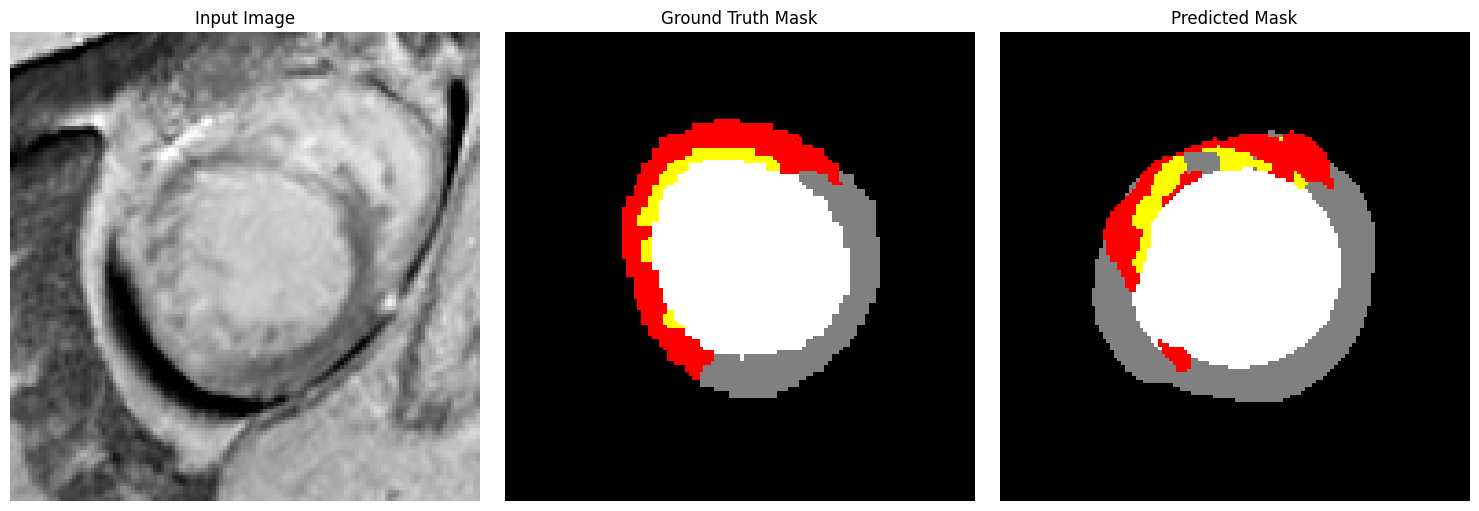

 57%|█████▊    | 46/80 [00:20<00:15,  2.17it/s]

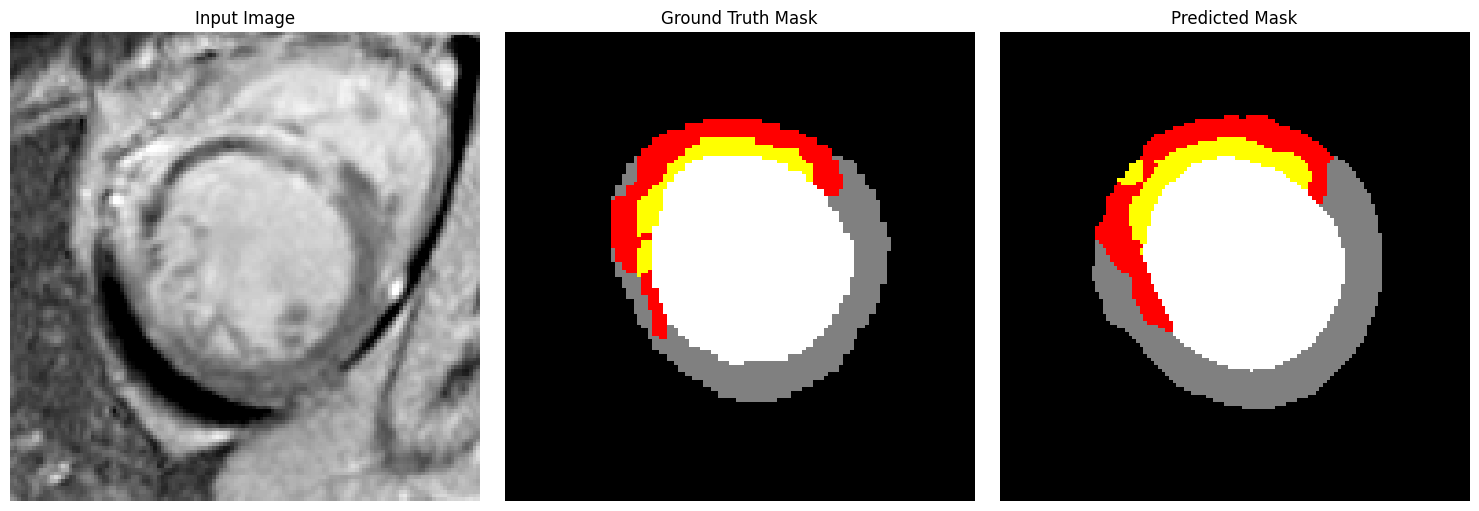

 59%|█████▉    | 47/80 [00:21<00:16,  2.00it/s]

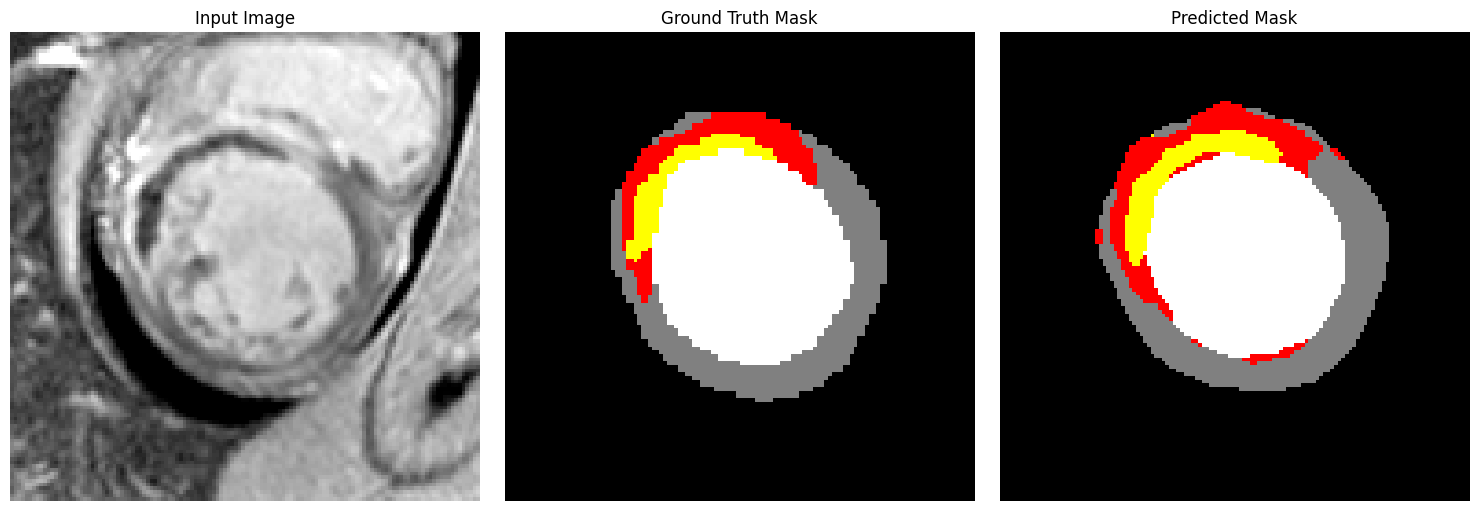

 60%|██████    | 48/80 [00:21<00:16,  1.90it/s]

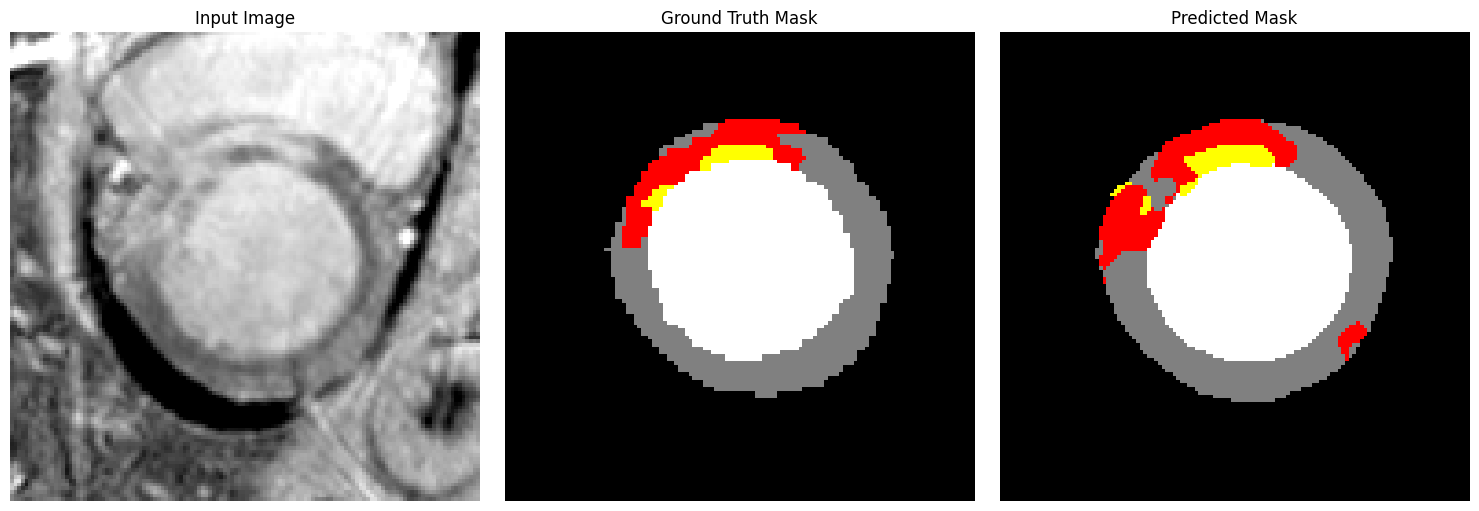

 61%|██████▏   | 49/80 [00:22<00:17,  1.82it/s]

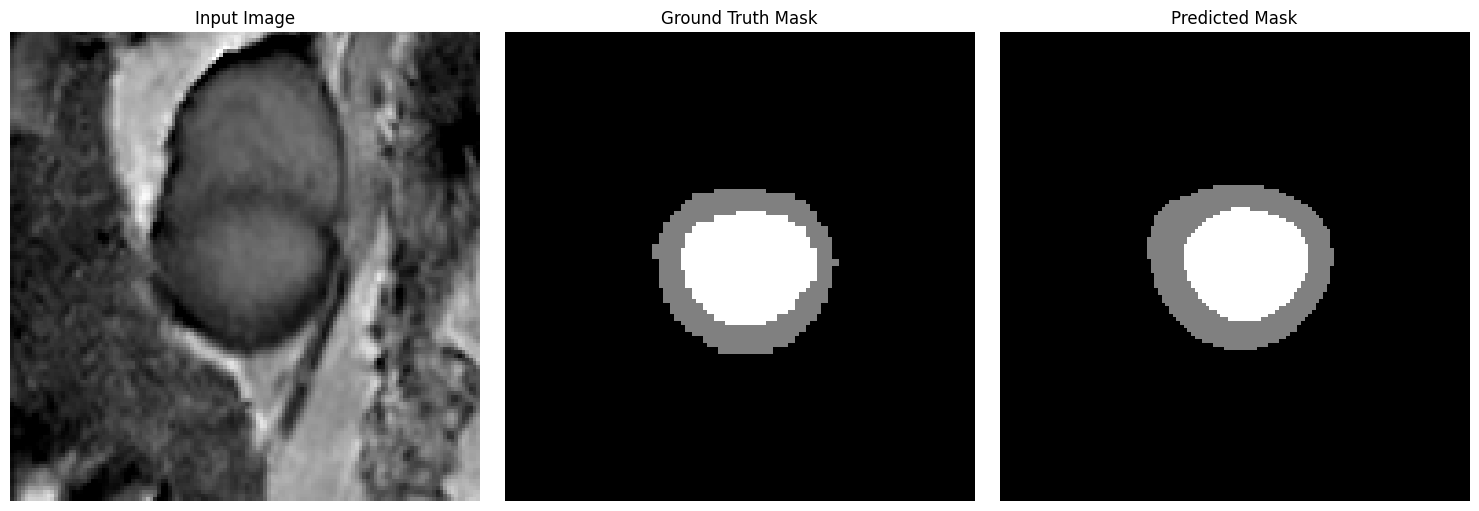

 62%|██████▎   | 50/80 [00:23<00:16,  1.81it/s]

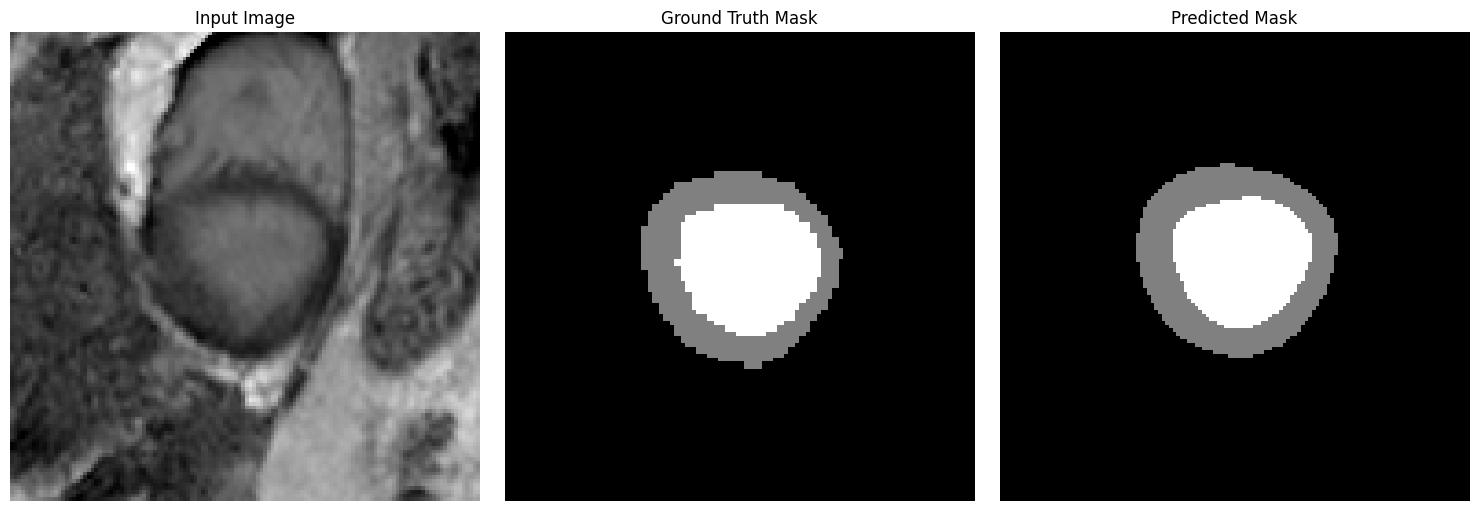

 64%|██████▍   | 51/80 [00:24<00:21,  1.35it/s]

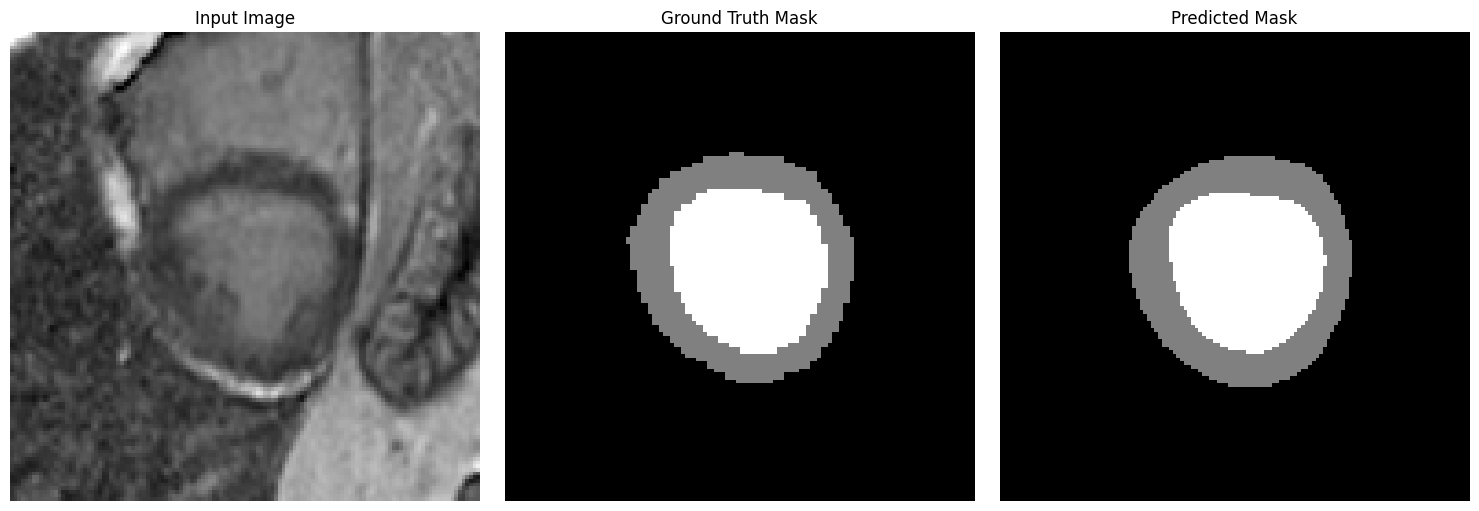

 65%|██████▌   | 52/80 [00:24<00:18,  1.53it/s]

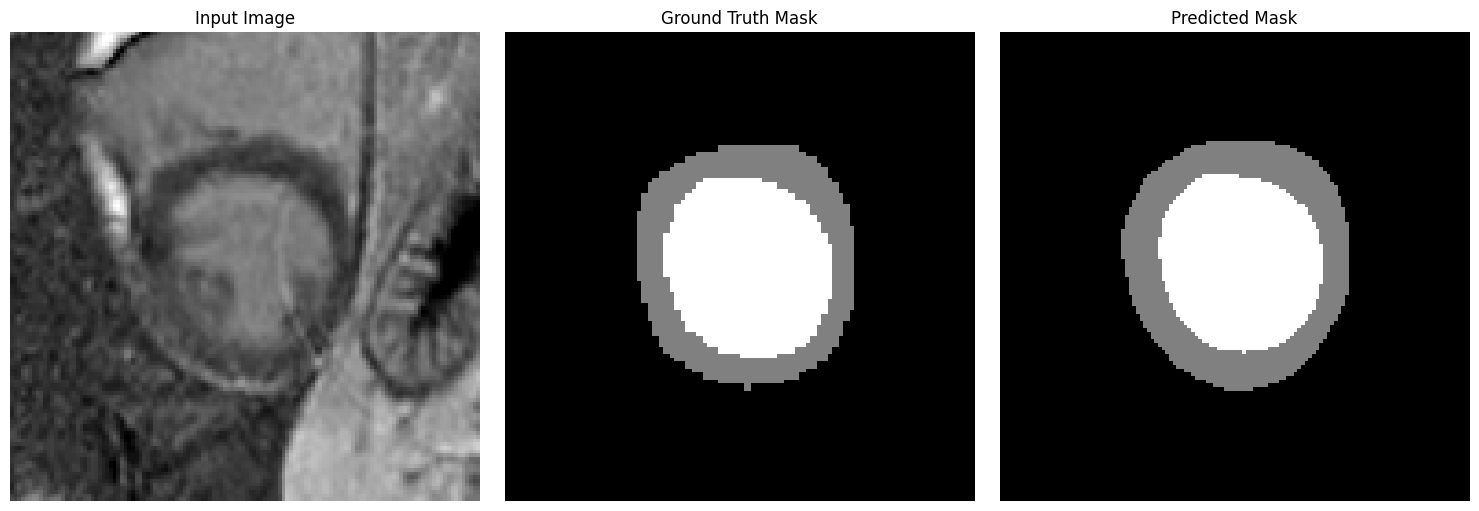

 66%|██████▋   | 53/80 [00:25<00:15,  1.69it/s]

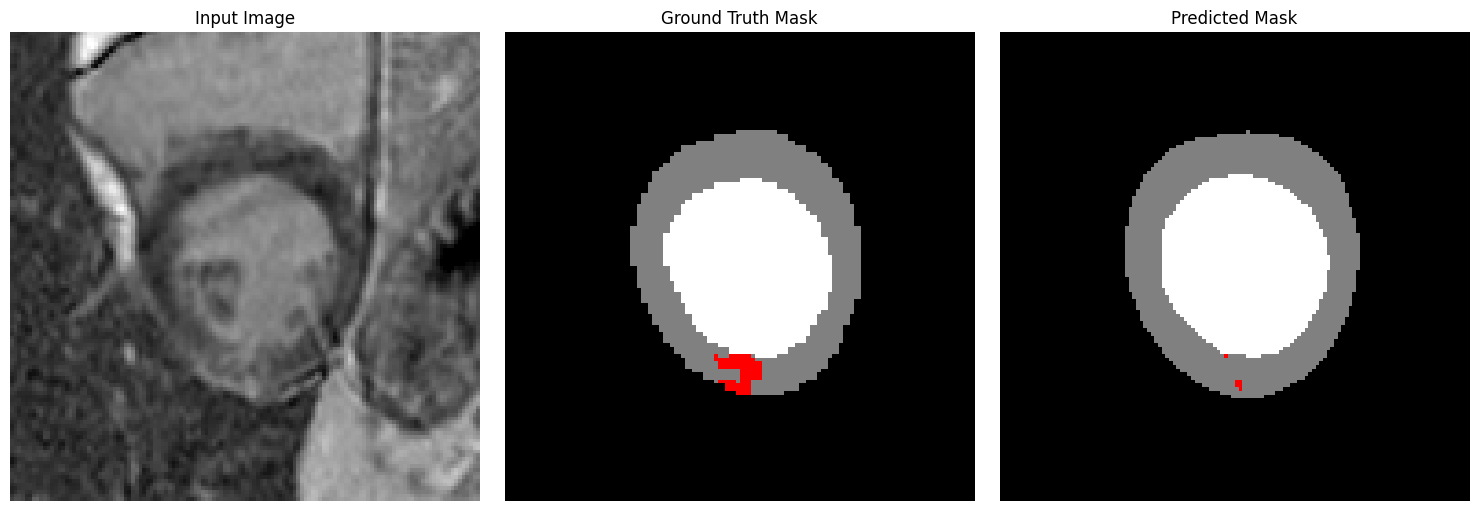

 68%|██████▊   | 54/80 [00:25<00:14,  1.85it/s]

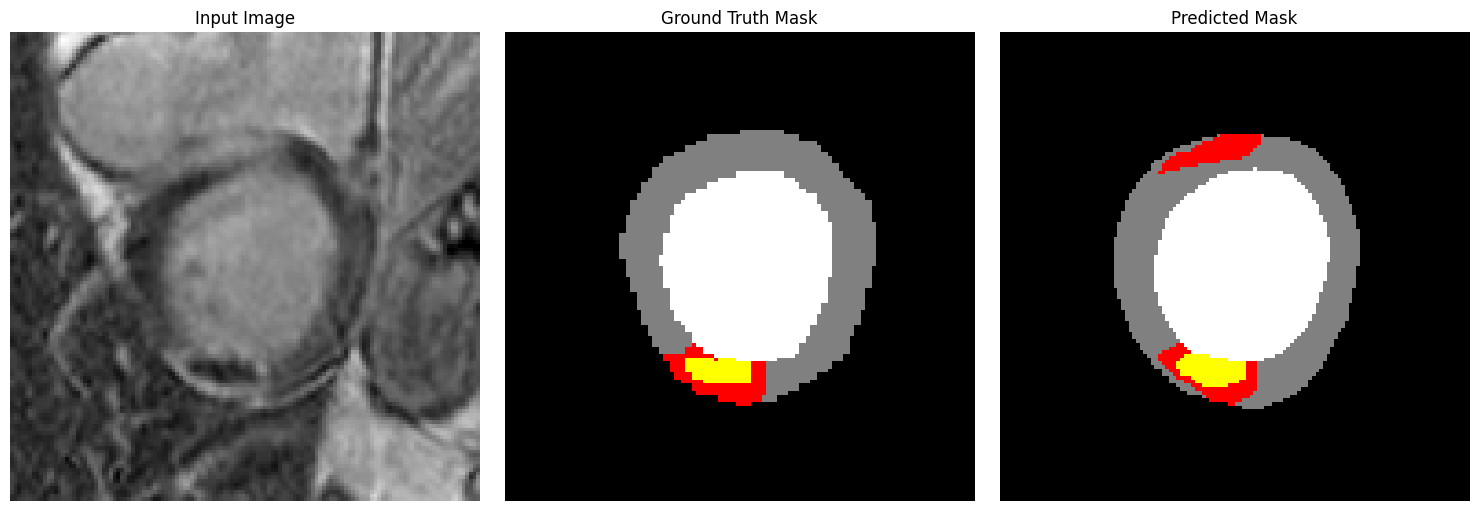

 69%|██████▉   | 55/80 [00:25<00:12,  1.97it/s]

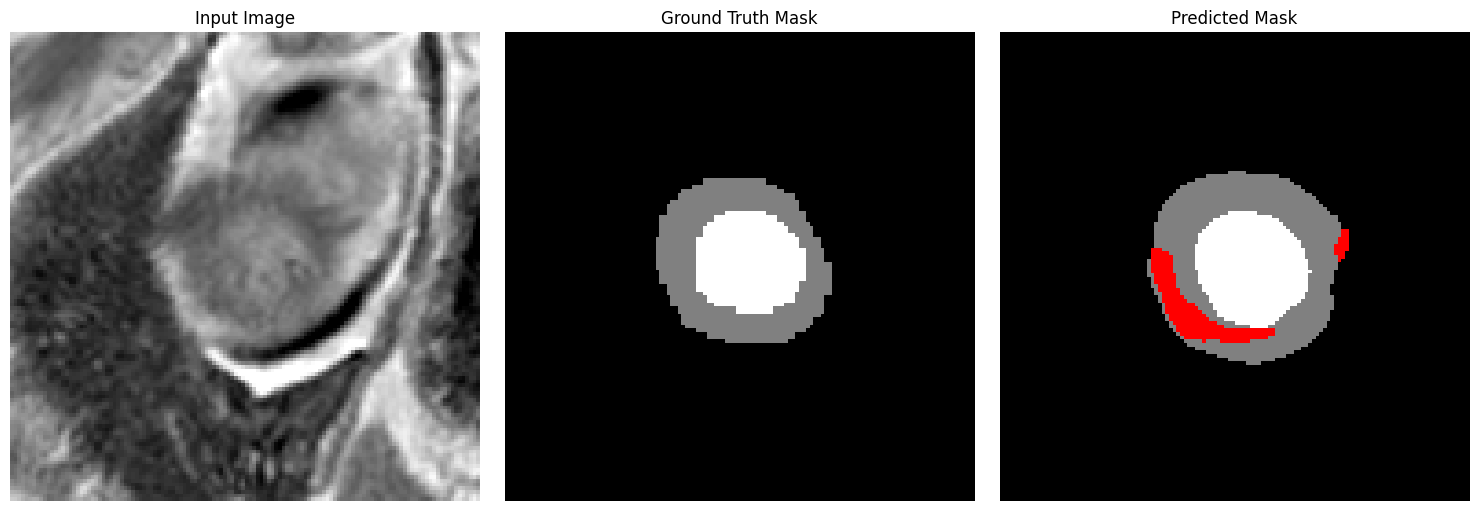

 70%|███████   | 56/80 [00:26<00:11,  2.06it/s]

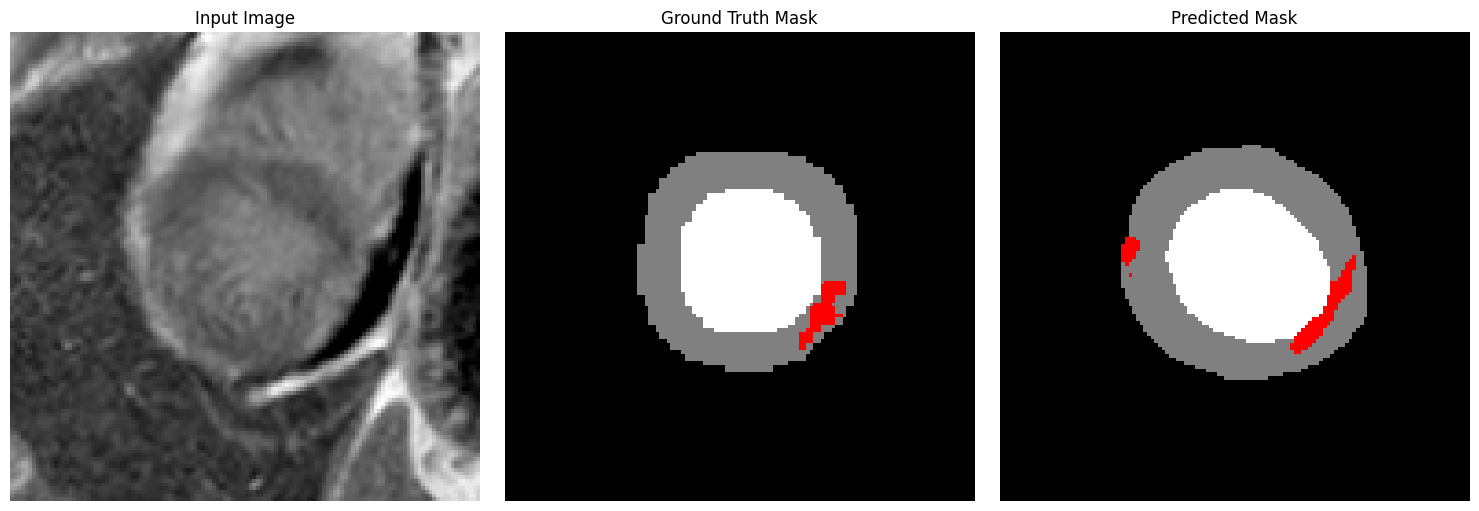

 71%|███████▏  | 57/80 [00:26<00:10,  2.14it/s]

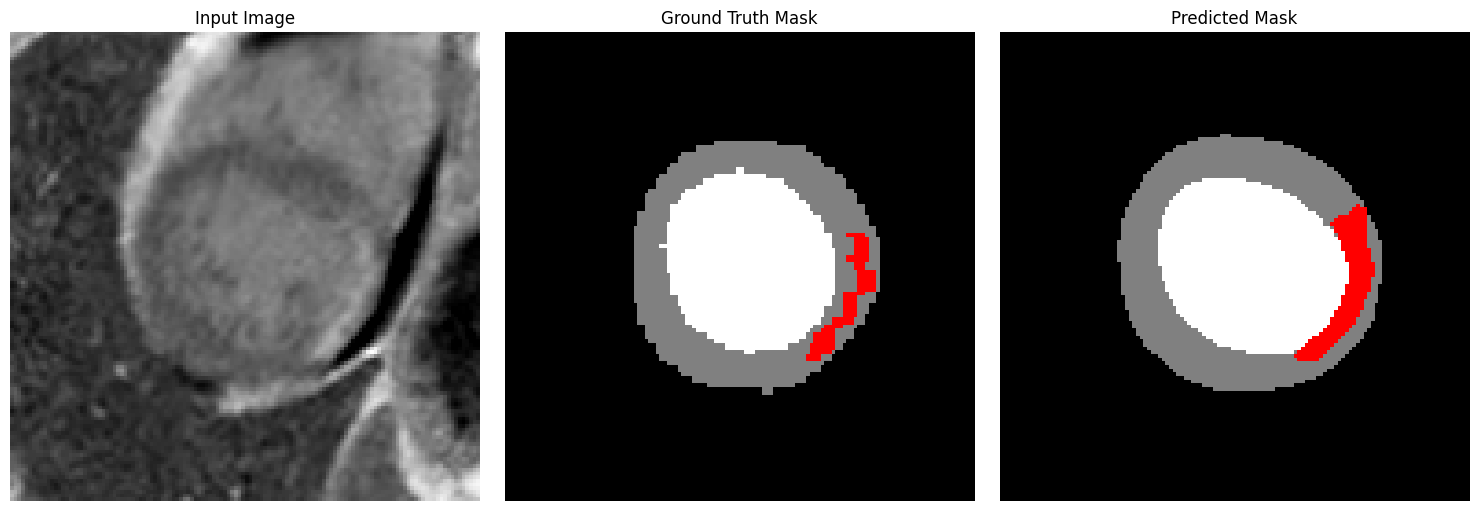

 72%|███████▎  | 58/80 [00:27<00:10,  2.18it/s]

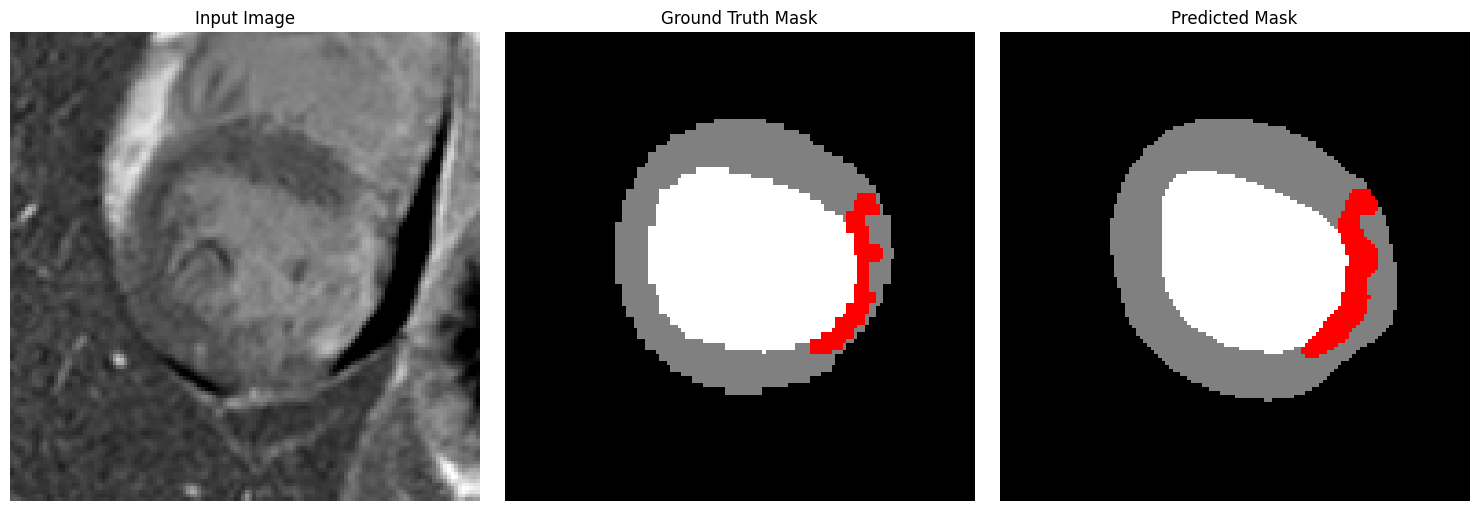

 74%|███████▍  | 59/80 [00:27<00:09,  2.24it/s]

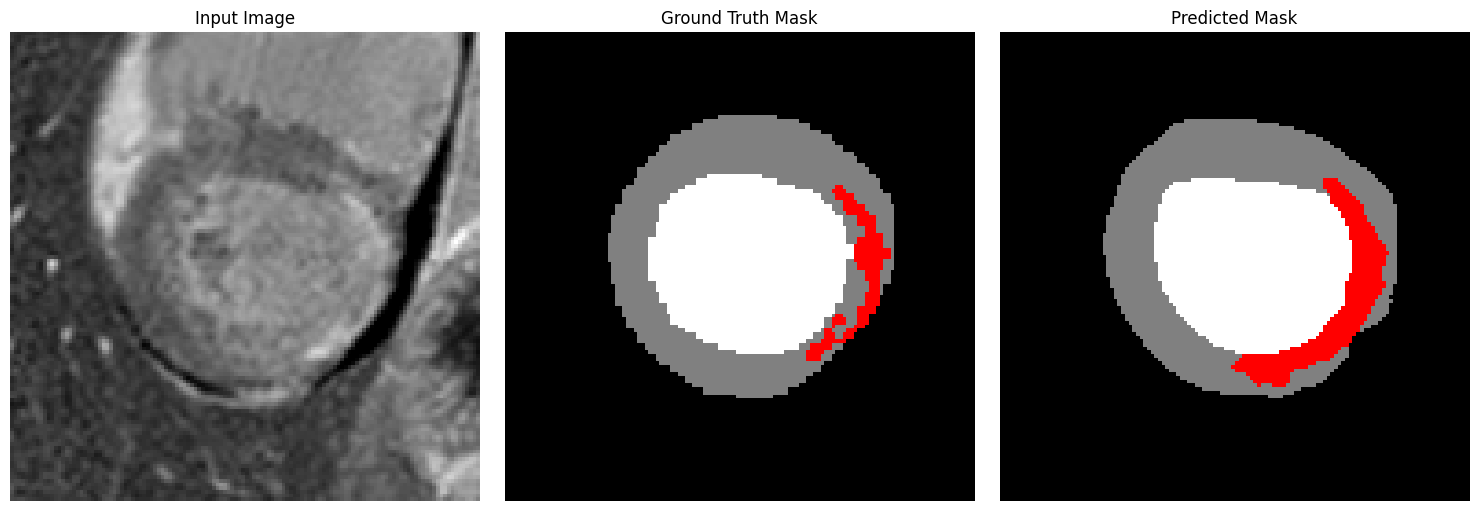

 75%|███████▌  | 60/80 [00:28<00:08,  2.27it/s]

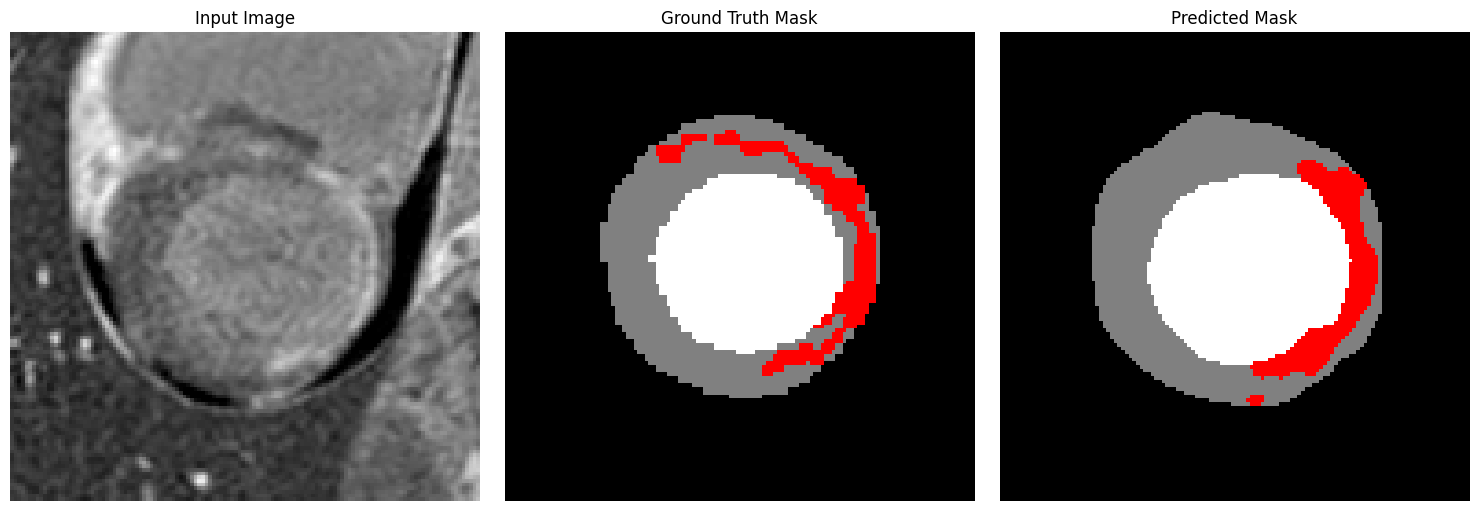

 76%|███████▋  | 61/80 [00:28<00:08,  2.27it/s]

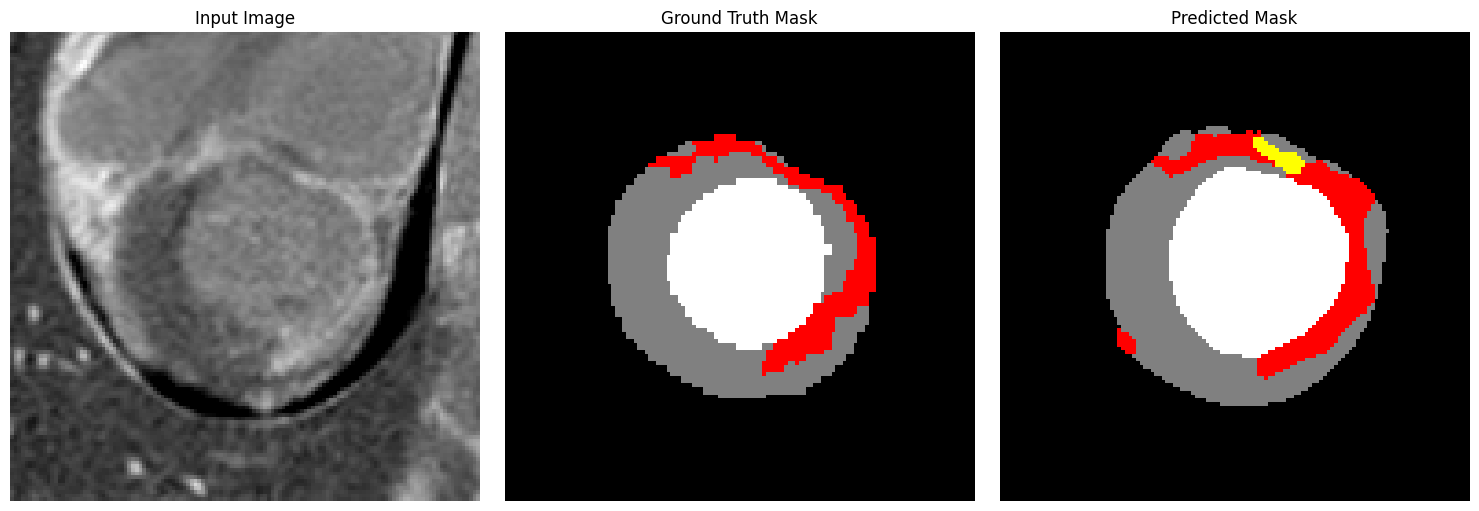

 78%|███████▊  | 62/80 [00:29<00:07,  2.27it/s]

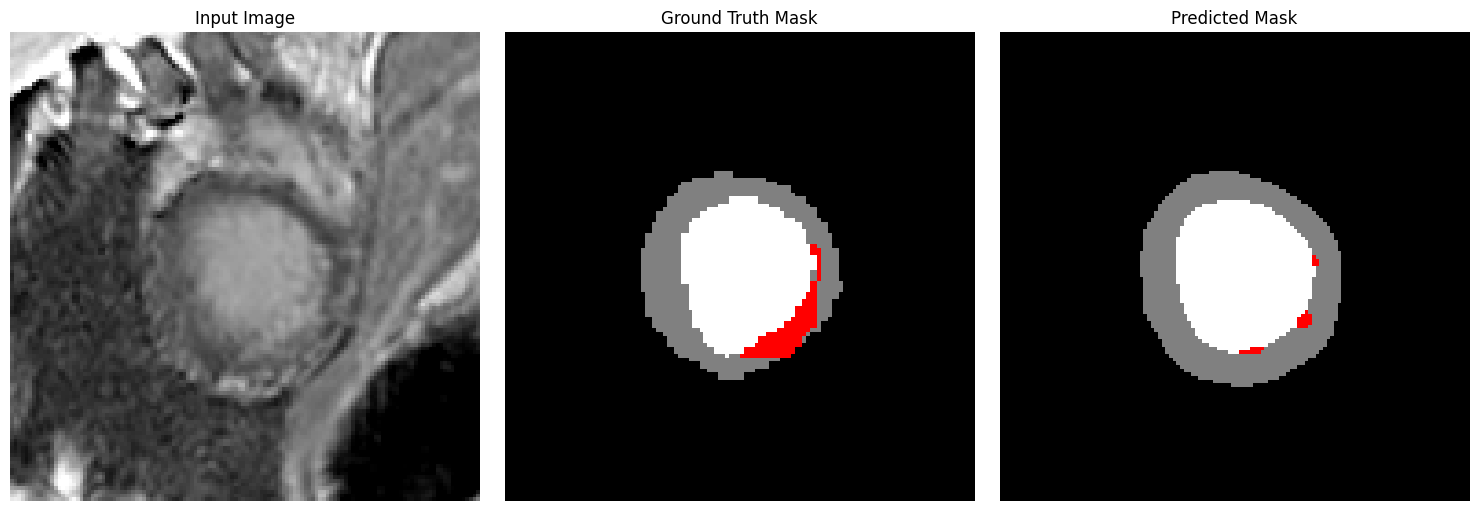

 79%|███████▉  | 63/80 [00:29<00:07,  2.28it/s]

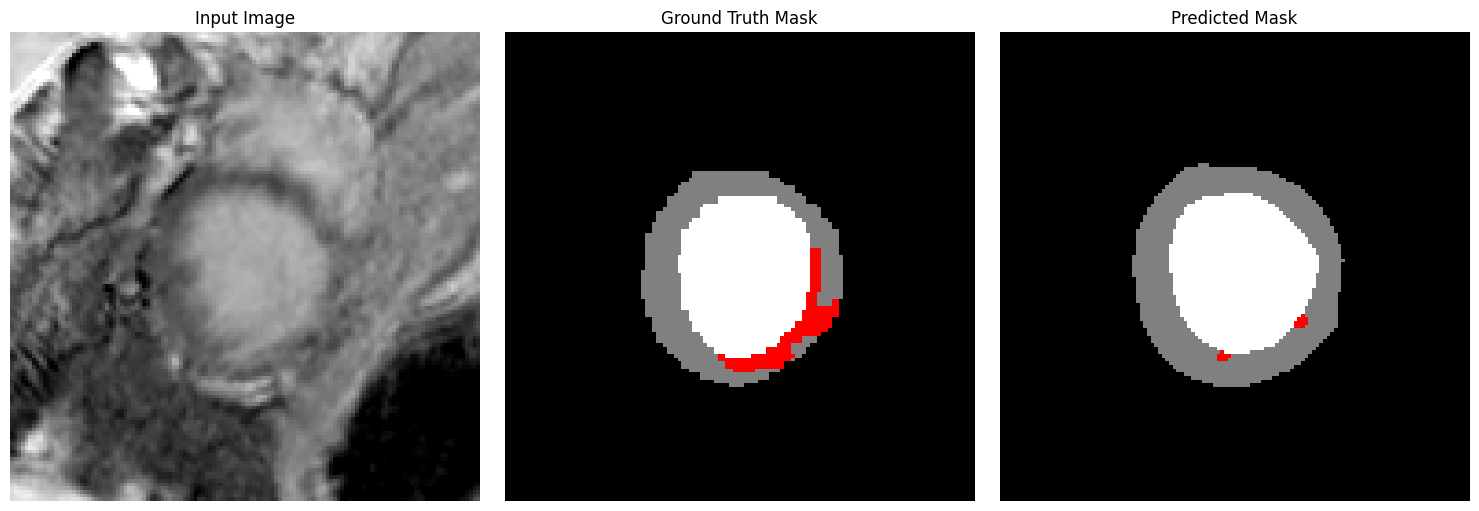

 80%|████████  | 64/80 [00:29<00:06,  2.29it/s]

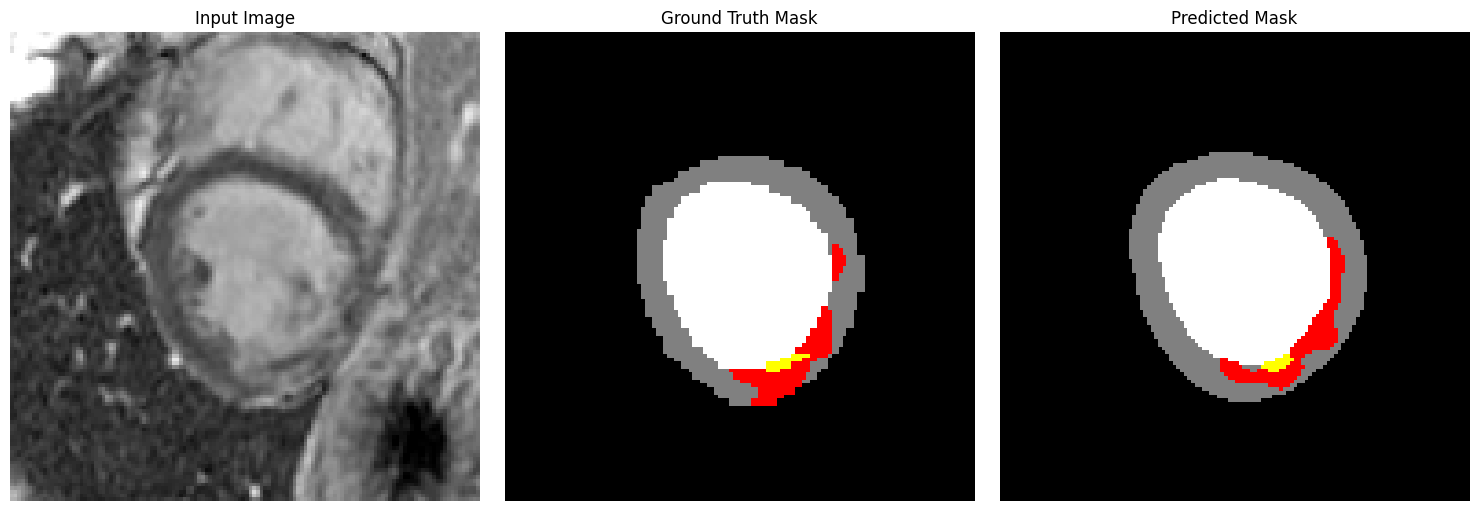

 81%|████████▏ | 65/80 [00:30<00:06,  2.30it/s]

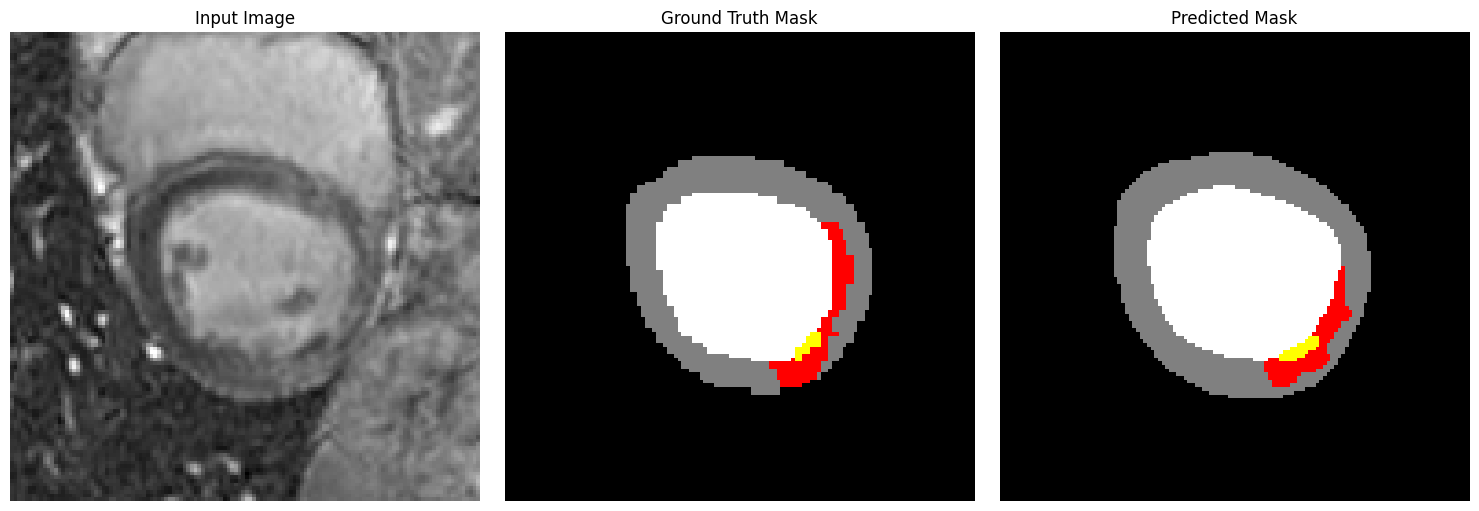

 82%|████████▎ | 66/80 [00:30<00:06,  2.31it/s]

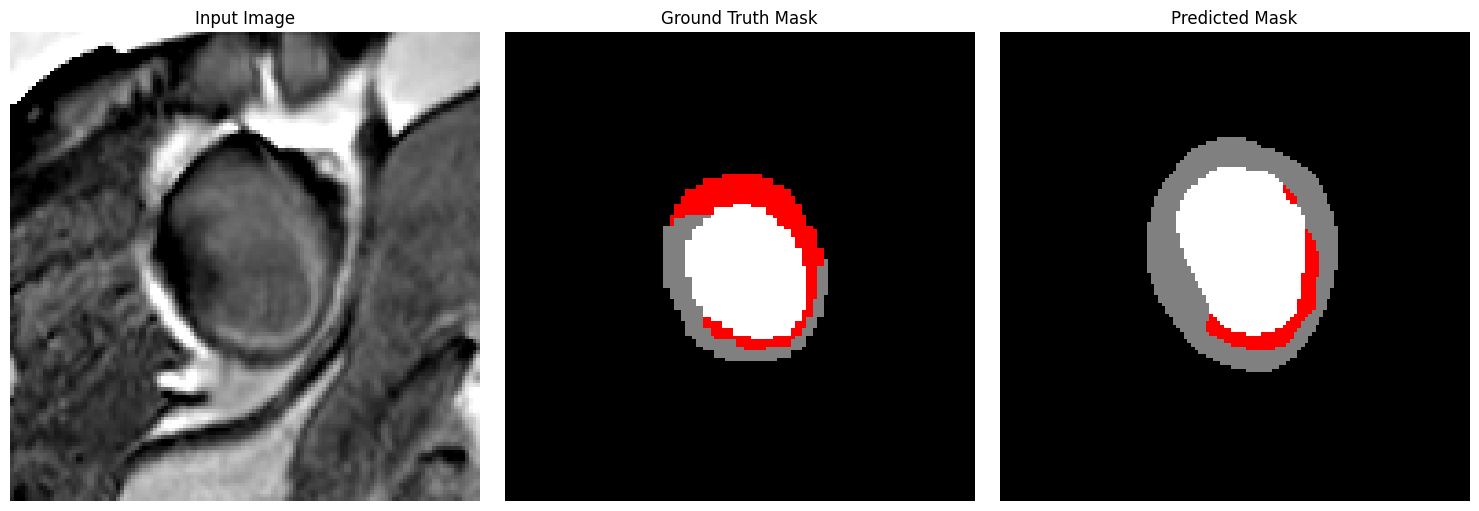

 84%|████████▍ | 67/80 [00:31<00:05,  2.31it/s]

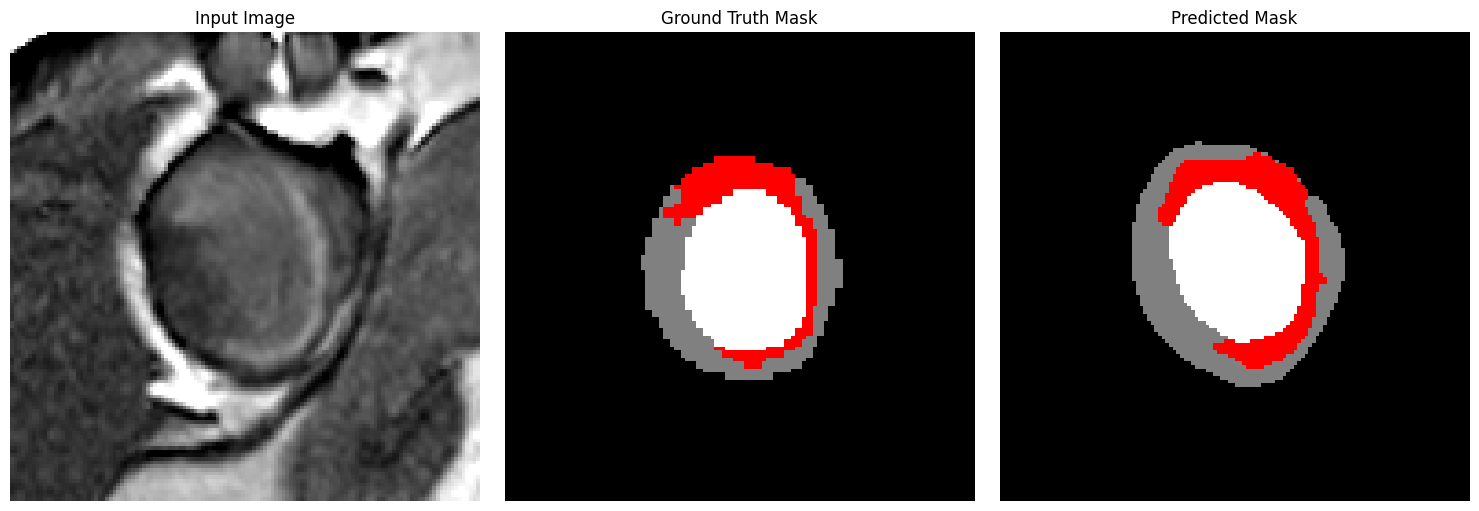

 85%|████████▌ | 68/80 [00:31<00:05,  2.30it/s]

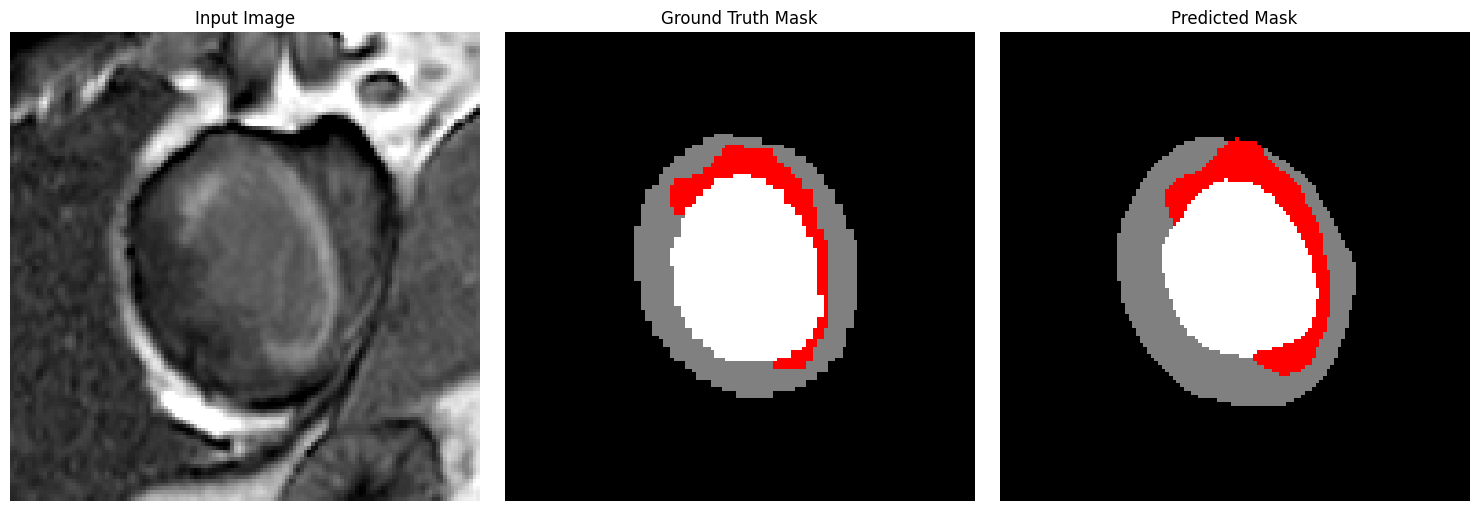

 86%|████████▋ | 69/80 [00:32<00:04,  2.31it/s]

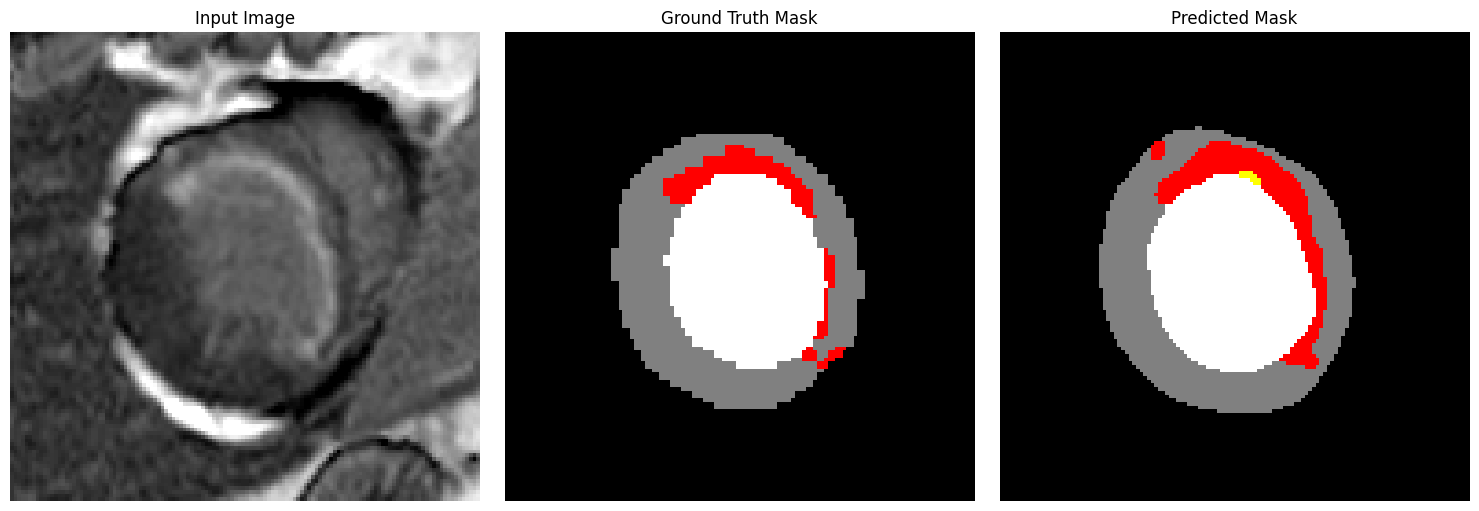

 88%|████████▊ | 70/80 [00:32<00:04,  2.30it/s]

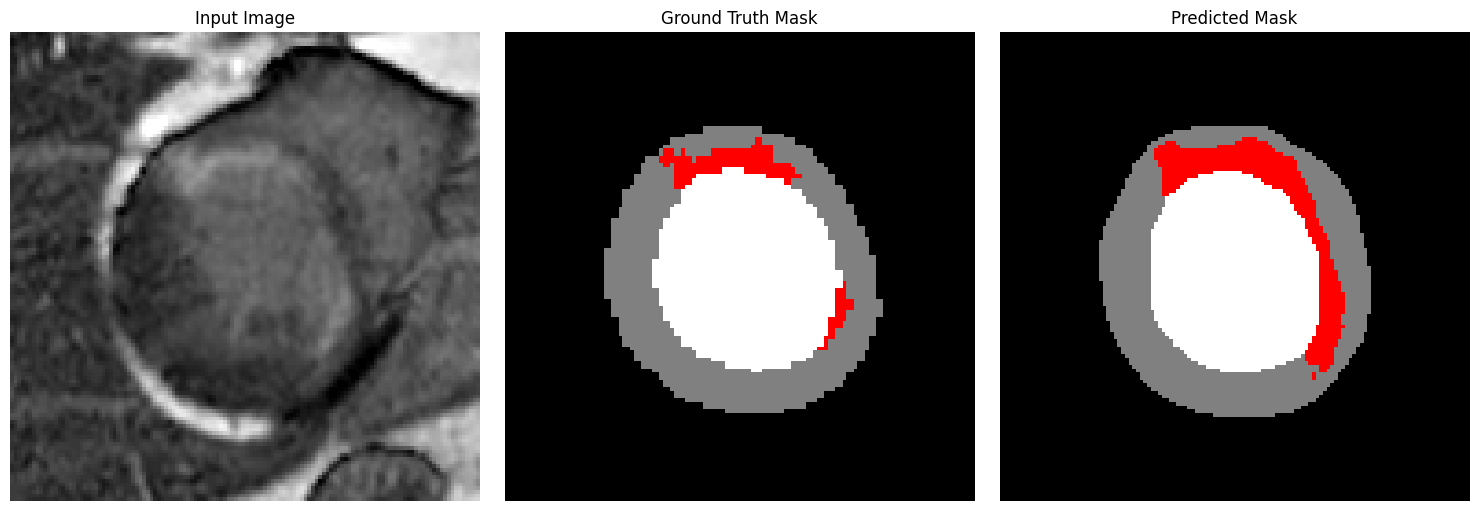

 89%|████████▉ | 71/80 [00:32<00:03,  2.31it/s]

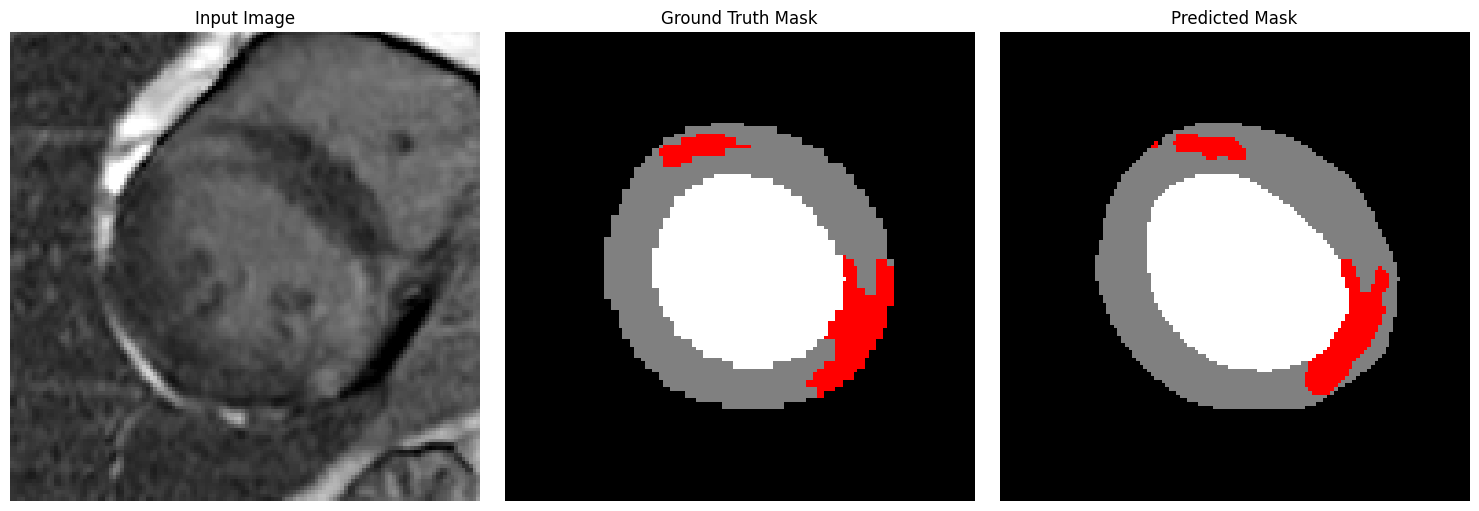

 90%|█████████ | 72/80 [00:33<00:03,  2.32it/s]

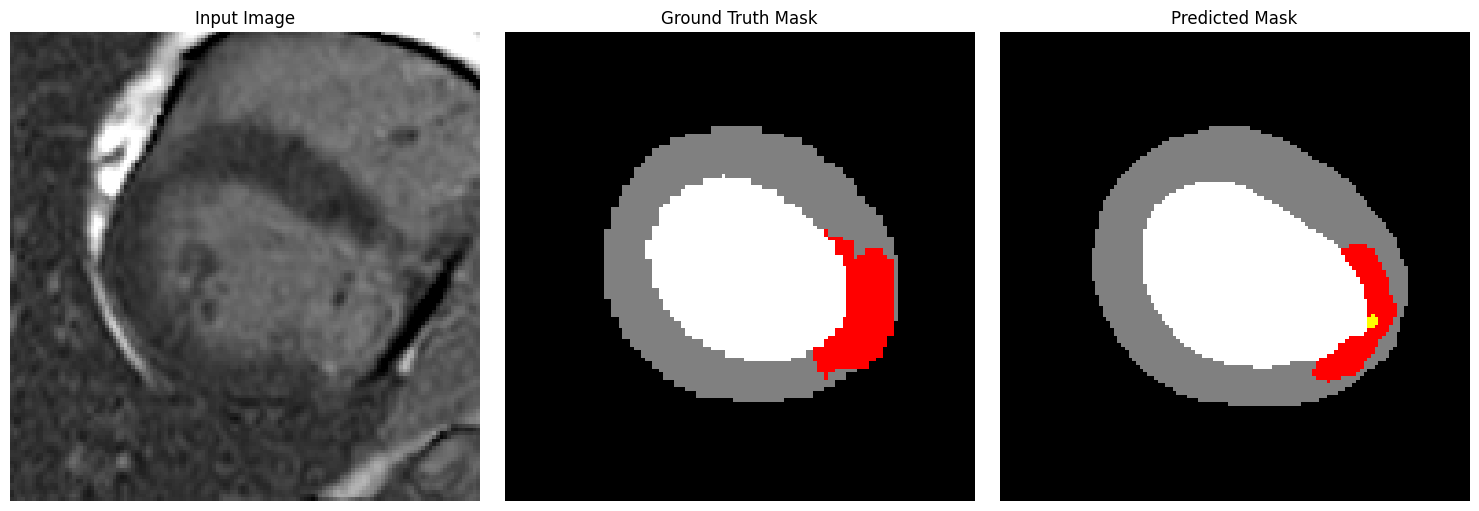

 91%|█████████▏| 73/80 [00:33<00:03,  2.27it/s]

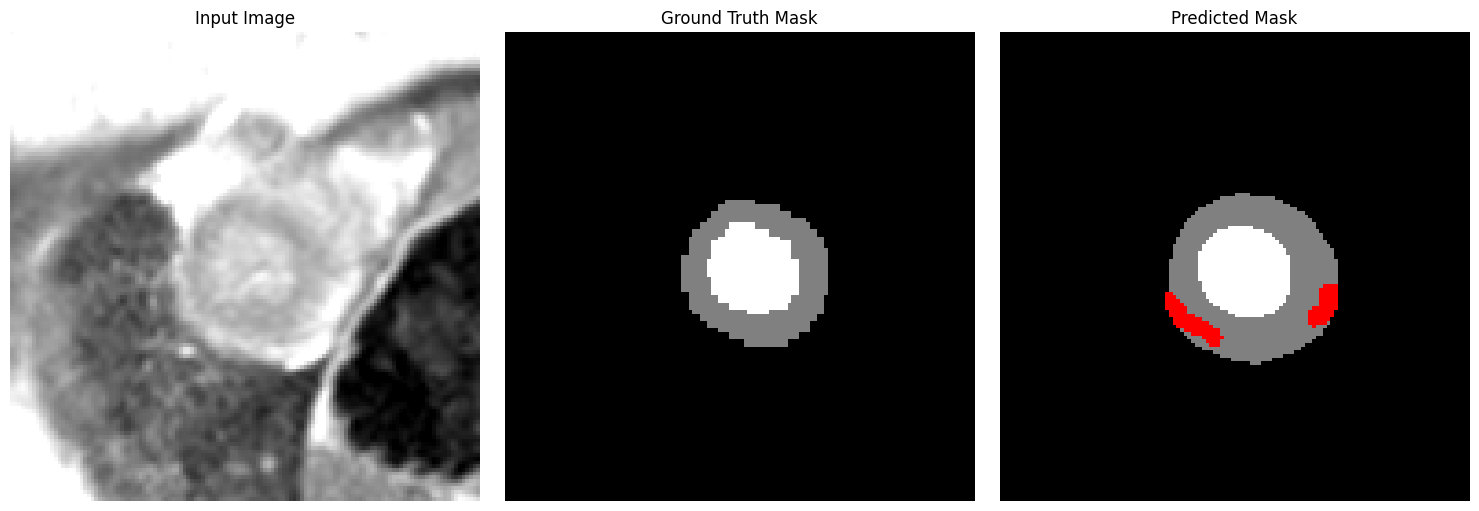

 92%|█████████▎| 74/80 [00:34<00:02,  2.00it/s]

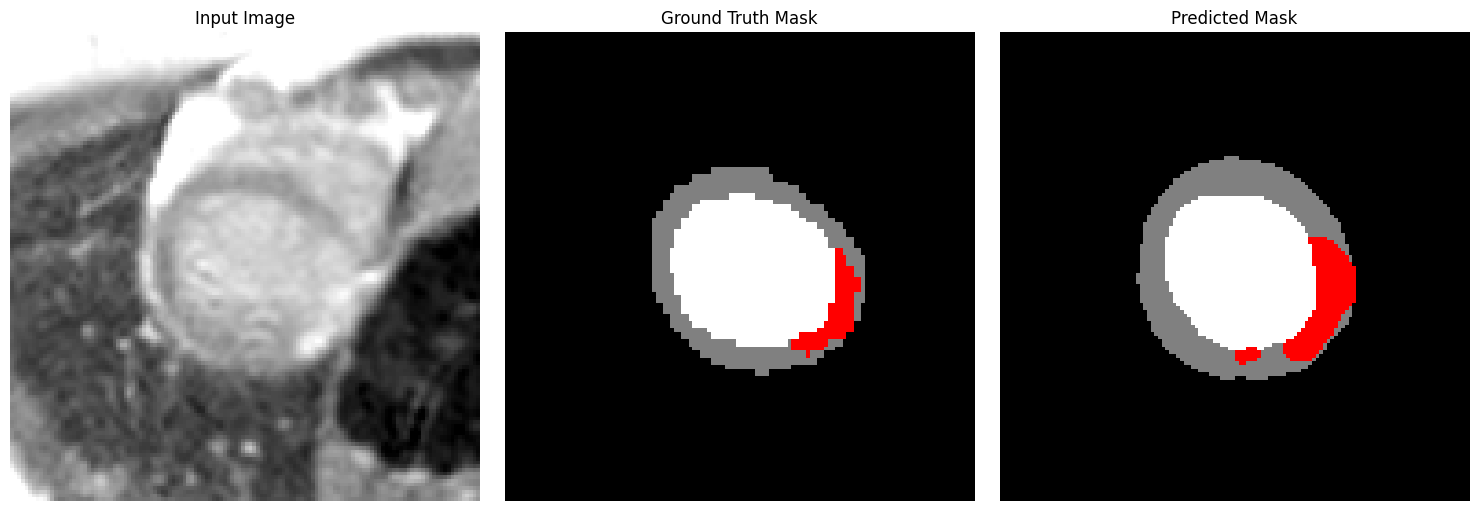

 94%|█████████▍| 75/80 [00:35<00:02,  1.89it/s]

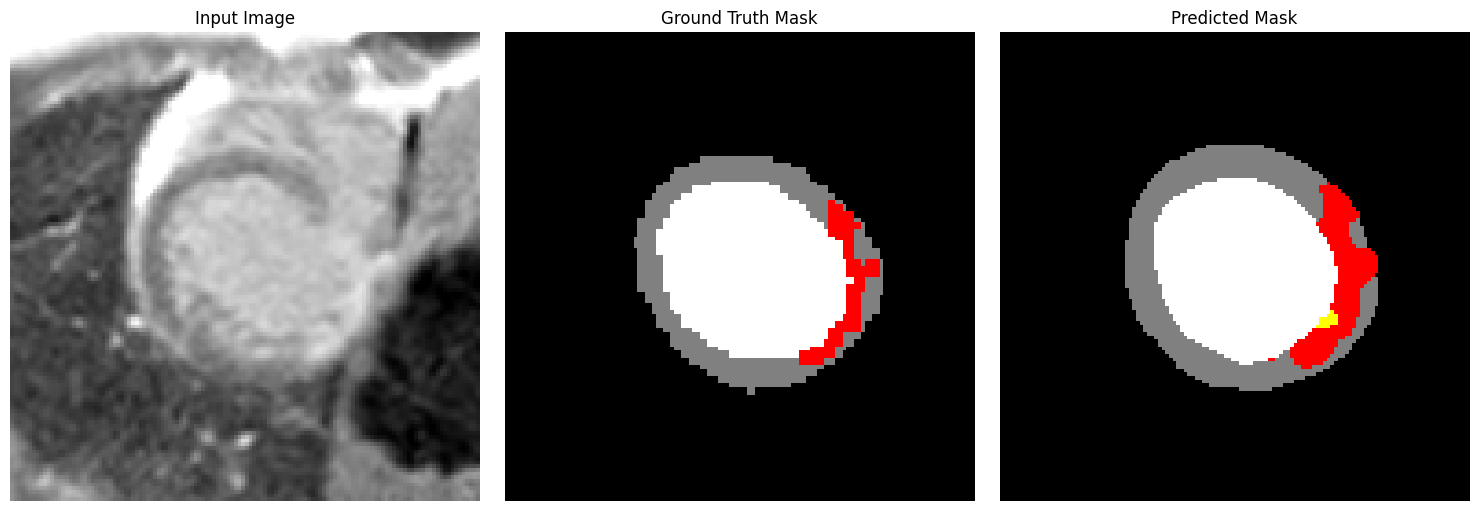

 95%|█████████▌| 76/80 [00:35<00:02,  1.78it/s]

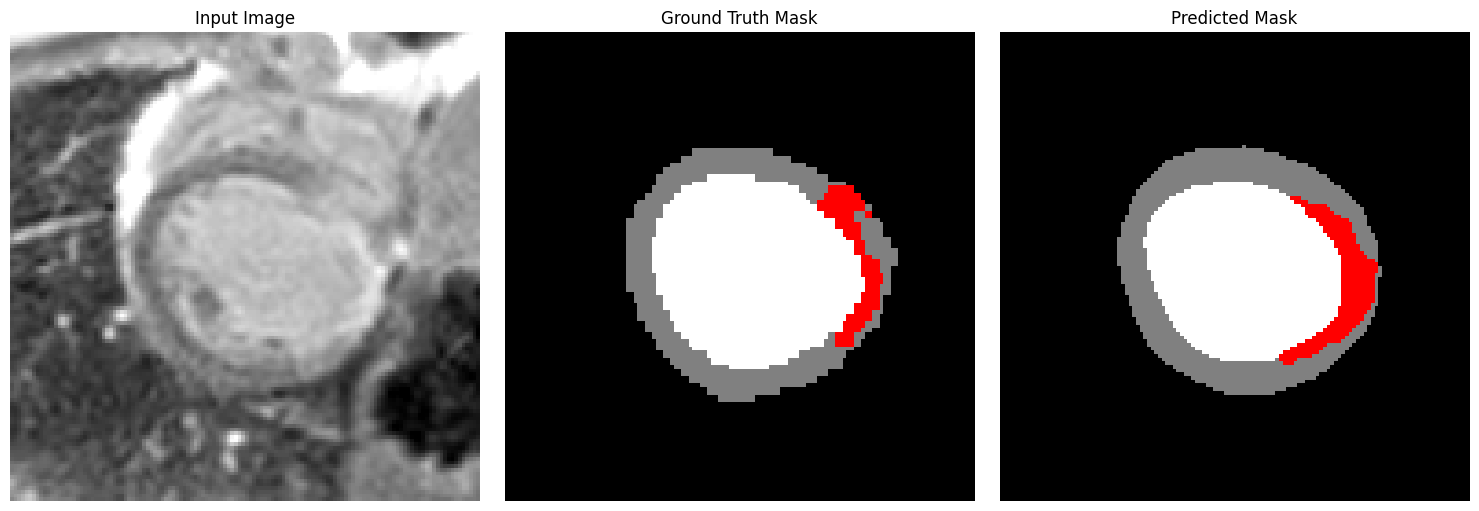

 96%|█████████▋| 77/80 [00:36<00:01,  1.73it/s]

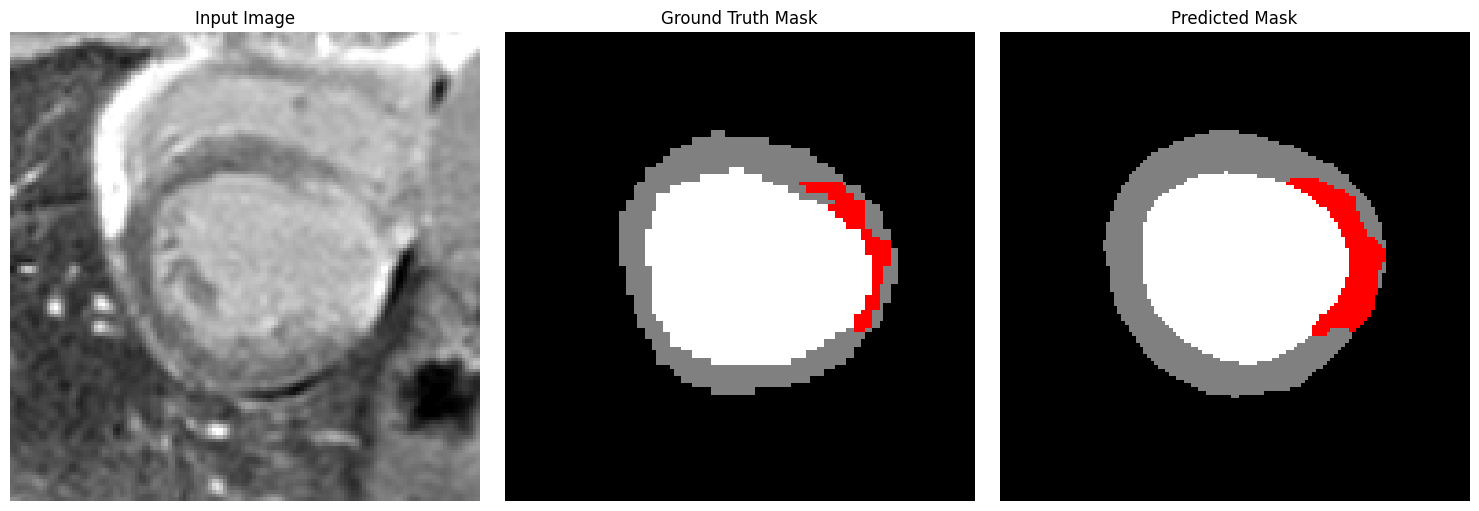

 98%|█████████▊| 78/80 [00:36<00:01,  1.66it/s]

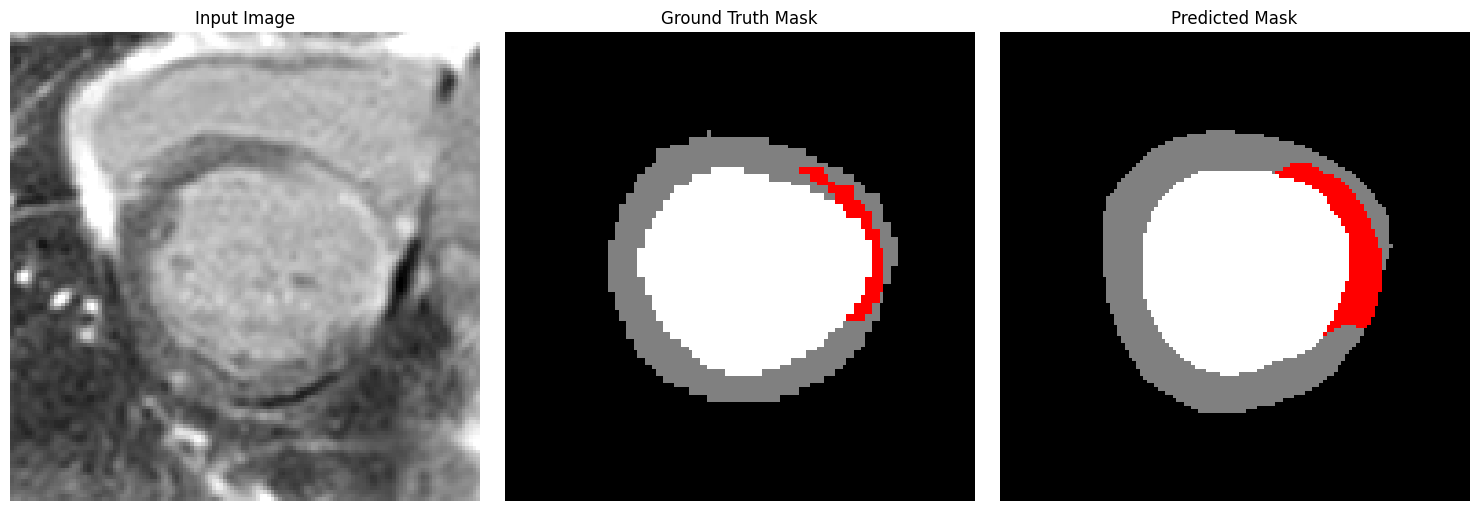

 99%|█████████▉| 79/80 [00:37<00:00,  1.67it/s]

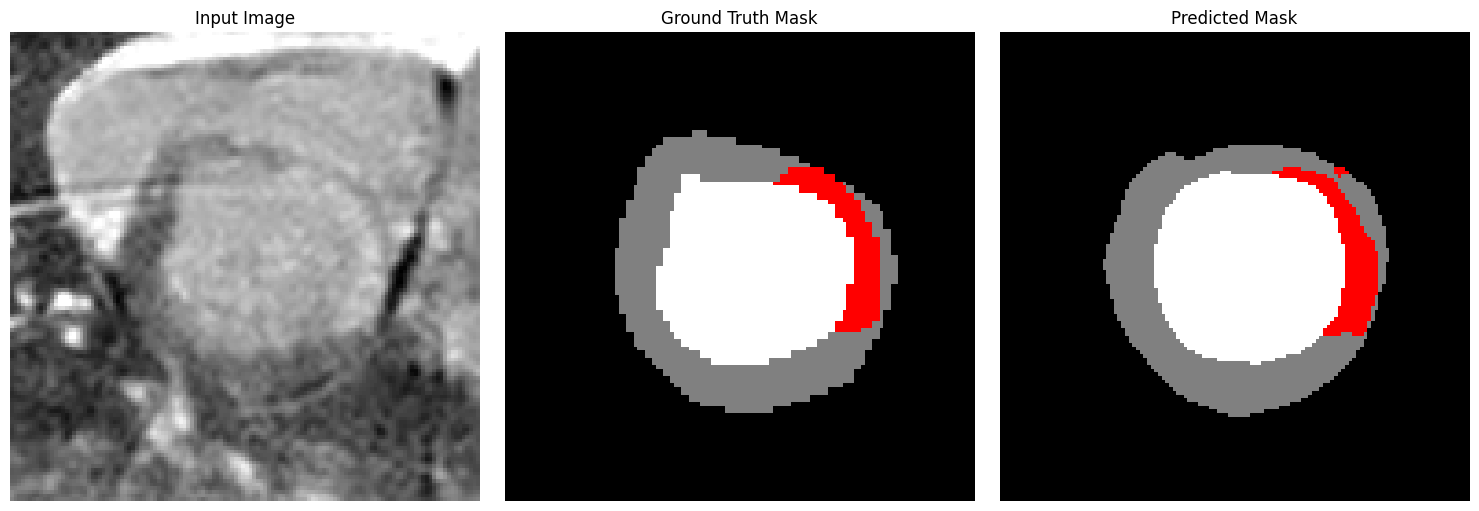

100%|██████████| 80/80 [00:37<00:00,  2.11it/s]


In [ ]:
from tqdm import tqdm  # optional for progress bar

# Loop through the test set
for i in tqdm(range(len(test_images_tensor))):  # tqdm adds a progress bar
    test_img = test_images_tensor[i]
    gt_mask = test_masks_tensor[i]

    # If tensors, convert to numpy
    if isinstance(test_img, tf.Tensor):
        test_img = test_img.numpy()
    if isinstance(gt_mask, tf.Tensor):
        gt_mask = gt_mask.numpy()

    # Add batch dimension
    test_img_expanded = np.expand_dims(test_img, axis=0)
    gt_mask_expanded = np.expand_dims(gt_mask, axis=0)

    # Call your function
    generate_images(model, test_img_expanded, gt_mask_expanded)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.metrics import MeanIoU

# Define Dice coefficient function
def dice_coefficient(y_true, y_pred, num_classes):
    dice_scores = []
    for i in range(num_classes):
        y_true_i = (y_true == i).astype(np.int32)
        y_pred_i = (y_pred == i).astype(np.int32)

        intersection = np.sum(y_true_i * y_pred_i)
        union = np.sum(y_true_i) + np.sum(y_pred_i)

        if union == 0:
            dice_scores.append(np.nan)  # Ignore empty class in averaging
        else:
            dice_scores.append((2. * intersection) / union)

    return dice_scores

# Initialize metric
iou_metric = MeanIoU(num_classes=NUM_CLASSES)
dice_all = []

# Loop through test set
for i in range(len(test_images_tensor)):
    img = test_images_tensor[i]  # Already NumPy array
    gt = test_masks_tensor[i].squeeze()  # Already NumPy array


    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred = np.argmax(pred.squeeze(), axis=-1)

    # Update IoU
    iou_metric.update_state(gt, pred)

    # Accumulate Dice scores
    dice_scores = dice_coefficient(gt, pred, num_classes=NUM_CLASSES)
    dice_all.append(dice_scores)

# Compute final metrics
mean_iou = iou_metric.result().numpy()
mean_dice_per_class = np.nanmean(dice_all, axis=0)  # Average per class, ignoring NaNs
mean_dice = np.nanmean(mean_dice_per_class)         # Overall mean Dice

print(f"✅ Average Mean IoU:  {mean_iou:.4f}")
print(f"✅ Average Dice Coefficient: {mean_dice:.4f}")


✅ Average Mean IoU:  0.6845
✅ Average Dice Coefficient: 0.7228


In [ ]:
import pickle

# Save training history to file
with open('/content/drive/MyDrive/Full_5000_Augmented_Original_With_5000_Generated_Data_10000/training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
